# Advanced Modelling and Cross Validation (IBM)

This notebook have been ran after the eda & Feature Engineering file.
This notebook implements an end-to-end deep-learning stock forecasting pipeline for IBM, split across two milestones:

- **Milestone 5 - Model Development:** loads the pre-engineered feature table, selects and scales features, builds sliding-window sequences, and trains/tunes four forecasting architectures (Baseline LSTM+GRU, BiLSTM+Attention, Time-Series Transformer, and a Temporal Convolutional Network), then compares them on accuracy, significance, interpretability (attention weights, SHAP), and complexity vs. performance.
- **Milestone 6 - Validation & Business Impact Assessment:** independently selects a deployment model for Open and for Close, validates it (sanity checks, noise-sensitivity, residual analysis), benchmarks it against naive baselines, translates the interpretability results into business language, assesses technical/deployment feasibility, and persists the final ticker-level outputs.

Each major step below is preceded by a short markdown cell describing what that step does.


Repeated-run stability analysis (multiple independent training runs) and cross-validation are performed later, in **Milestone 6**, on the production candidate models only.

**Notebook structure:**

**Milestone 5 (Section 1-18) (Advance Modelling):**

1. Load Dataset
2. Global Configuration
3. Train / Validation / Test Split
4. Feature Selection (XGBoost Importance)
5. Feature Scaling
6. Sliding-Window Sequence Construction
7. Interpretable Attention Mechanism
8. Evaluation Utilities
9. Baseline Model (LSTM + GRU) & Training Harness
10. Advanced Model 1 - BiLSTM + Attention
11. Advanced Model 2 - Time-Series Transformer  /  Advanced Model 2b: Baseline + Transformer
12. Advanced Model 3 - Temporal Convolutional Network (TCN)
13. Paper-Protocol Robustness Summary
14. Hyperparameter Optimization
15. Comparative Model Evaluation (regression, tables and plots)
16. Model Interpretability and Explainability
17. Complexity vs. Performance Trade-Off Analysis
18. Business Interpretation and Recommendations

**Milestone 6 (Sections 19-27) (Cross Validation & Business Impact):**

19. Deployment Model Selection (Open & Close)
20. Validation Summary
21. Input Noise Sensitivity Analysis
22. Residual Analysis
23. Business Impact vs. Naive Baseline
24. Model Interpretability - Business Reading
25. Technical Feasibility and Deployment Considerations
26. Final Conclusions and Recommendations
27. Persist Ticker-Level Outputs

Each of the four architectures (baseline + 4 advanced) is trained once and then compared side-by-side in Section 15, before every architecture is tuned separately in Section 14 on a combined Open+Close objective. The cell below imports every library used downstream and fixes the base random seed for reproducibility.

All artifacts this notebook produces (trained models, scalers, comparison tables, deployment summary, next-day forecast) are persisted to `output/<TICKER>/...` on disk - see the *Output Folder Setup* cell below, the model-saving cell at the end of Section 18, and the *Persist Ticker-Level Outputs* cell (Section 27).


# Milestone 5 - Deep-Learning Stock Forecasting Pipeline (IBM)

This notebook builds, trains and evaluates several deep-learning architectures that regress the next-day **open/close price**. To keep the comparison trustworthy and leakage-free, every model is:

In [ ]:
# Standard Python libraries
import os
import random
import time
import warnings
import json
import pickle
import gc
import sys

warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Machine learning
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
    KFold
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Statistical analysis
from scipy import stats

# Model explainability
import shap

# Notebook display
from IPython.display import display, Markdown

# Trading calendar
import pandas_market_calendars as mcal

# Reproducibility
SEED = 50

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

## Output Folder Setup

Every important artifact this notebook produces (trained models, scalers, comparison
tables, plots' underlying data, deployment summary, next-day forecast) is persisted to
`output/<TICKER>/...` on disk:

```
output/<TICKER>/<ArchitectureName>/basic/model.keras + result_row.json
output/<TICKER>/<ArchitectureName>/optimized/model.keras + result_row.json + best_hyperparameters.json
output/<TICKER>/scalers.pkl, selected_features.json, config.json
output/<TICKER>/reg_results_*.csv, complexity_vs_performance.csv, feature_importance.csv, shap_importance.csv
output/<TICKER>/deployment_summary.json, next_day_forecast.json, full_results.pkl
```


In [2]:
# --- Output folder layout (mirrors the multi-ticker pipeline's output/<TICKER>/... structure) ---
OUTPUT_ROOT = 'outputs'

ARCH_KEYS = ['baseline', 'bilstm_attention', 'transformer', 'baseline_transformer', 'tcn']

ARCH_DISPLAY_NAME = {
    'baseline':             'Baseline (LSTM+GRU)',
    'bilstm_attention':     'Advanced 1 (BiLSTM+Attention)',
    'transformer':          'Advanced 2 (Transformer)',
    'baseline_transformer': 'Advanced 2b (Baseline+Transformer)',
    'tcn':                  'Advanced 3 (TCN)',
}

ARCH_FOLDER_NAME = {
    'baseline':             'Baseline_LSTM_GRU',
    'bilstm_attention':     'BiLSTM_Attention',
    'transformer':          'Transformer',
    'baseline_transformer': 'Baseline_Transformer',
    'tcn':                  'TCN',
}


def ensure_ticker_dirs(ticker, output_root=OUTPUT_ROOT):
    """Create output/<TICKER>/<ArchName>/{basic,optimized}/ for every architecture."""
    ticker_dir = os.path.join(output_root, ticker)
    os.makedirs(ticker_dir, exist_ok=True)
    for arch_key in ARCH_KEYS:
        for variant in ('basic', 'optimized'):
            os.makedirs(os.path.join(ticker_dir, ARCH_FOLDER_NAME[arch_key], variant), exist_ok=True)
    return ticker_dir


def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)


print(f"Output root: {OUTPUT_ROOT}/<TICKER>/<Architecture>/{{basic,optimized}}/  "
      f"(TICKER is defined in Section 1 below)")


Output root: outputs/<TICKER>/<Architecture>/{basic,optimized}/  (TICKER is defined in Section 1 below)


## 1. Load Dataset

Read the pre-engineered IBM price/feature table (one row per trading day) that was produced in earlier milestones and stored as a Parquet file.


In [ ]:
# Load the engineered feature table produced in earlier milestones (one row per trading day)
df = pd.read_parquet('E:\\Stock-Price-Prediction-using-Advanced-modelling\\notebook\\Final_capstone\\code\\generated_datasets\\individual_tickers_dataset\\IBM.parquet')
TICKER = 'IBM'
df  # quick visual sanity check


,symbol,date,open,high,low,close,volume,Daily_Return,Overnight_Gap,HL_Range,...,SentLabel_Somewhat-Bearish,SentLabel_Somewhat-Bullish,Has_News,News_Count_Surprise,Days_Since_Last_News,Sentiment_MA10,Sentiment_x_VolumeRatio,Sentiment_x_ATR,NewsCount_x_Return,symbol_te
0,IBM,2016-03-15,88.369556,89.360854,88.244862,89.130173,3878045,0.001260,-0.007284,0.012521,...,0,0,1,1.000000,0,0.143501,0.112508,0.266487,0.002520,0.529562
1,IBM,2016-03-16,88.918190,90.327216,88.600229,90.271103,4416107,0.012801,-0.002378,0.019131,...,1,0,1,0.666667,0,-0.030472,-0.183693,-0.377764,0.012801,0.529562
2,IBM,2016-03-17,90.264886,91.848481,90.059151,91.673912,6089394,0.015540,-0.000069,0.019518,...,0,0,0,0.000000,1,-0.020315,0.000000,0.000000,0.000000,0.529562
3,IBM,2016-03-18,91.898370,91.966951,90.720025,91.705093,12645826,0.000340,0.002448,0.013597,...,0,0,0,0.000000,2,-0.015236,0.000000,0.000000,0.000000,0.529562
4,IBM,2016-03-21,91.836007,92.715088,91.474401,92.665215,3892794,0.010470,0.001428,0.013389,...,0,0,0,0.000000,3,-0.012189,0.000000,0.000000,0.000000,0.530071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2459,IBM,2025-12-23,297.442478,301.183467,296.761400,299.850922,2923000,0.003270,-0.004789,0.014748,...,0,1,1,0.652819,0,0.194789,0.187725,1.561478,0.035966,0.529801
2460,IBM,2025-12-24,299.831209,301.203215,298.390071,300.620850,1210600,0.002568,-0.000066,0.009358,...,0,1,1,0.703812,0,0.198687,0.076290,1.434448,0.030812,0.529801
2461,IBM,2025-12-26,300.749131,301.795419,299.742335,301.143951,2814700,0.001740,0.000427,0.006818,...,0,0,1,1.028571,0,0.183595,0.109291,0.847970,0.031321,0.529801
2462,IBM,2025-12-29,300.709655,305.990464,299.821301,301.785553,4664500,0.002131,-0.001442,0.020442,...,0,1,1,1.576087,0,0.187879,0.296351,1.445380,0.061786,0.529801


In [4]:
df.isnull().sum()  # sanity check: no NaNs in the final feature table

symbol                     0
date                       0
open                       0
high                       0
low                        0
                          ..
Sentiment_MA10             0
Sentiment_x_VolumeRatio    0
Sentiment_x_ATR            0
NewsCount_x_Return         0
symbol_te                  0
Length: 145, dtype: int64

## 2. Global Configuration

All tunable constants live in a single `CONFIG` dictionary so every downstream cell reads from one source of truth. This also documents, in one place, the exact experimental protocol used everywhere below: a 70/10/20 train/val/test split, a 30-day sliding window, and a single train/validation/test training run for every model.


In [5]:
CONFIG = {               # sliding-window length (timesteps fed to sequence models)
    'TOP_K_FEATURES': 40,               # number of features kept after XGBoost selection
    'TRAIN_RATIO'   : 0.80,             # sequential 80/10/10 split (matches Milestone 1 SMART plan)
    'VAL_RATIO'     : 0.10,
    'TEST_RATIO'    : 0.10,
    'EPOCHS'        : 100,
    'BATCH_SIZE'    : 32,
    'PATIENCE'      : 10,
}
print(CONFIG)


{'TOP_K_FEATURES': 40, 'TRAIN_RATIO': 0.8, 'VAL_RATIO': 0.1, 'TEST_RATIO': 0.1, 'EPOCHS': 100, 'BATCH_SIZE': 32, 'PATIENCE': 10}


## 3. Train / Validation / Test Split

Sequential (non-shuffled) split so the validation and test sets always follow the training set in time — no look-ahead leakage.


In [6]:
# Sequential (non-shuffled) split so validation/test always follow training in time
n_total = len(df)
train_end = int(n_total * CONFIG['TRAIN_RATIO'])
val_end   = train_end + int(n_total * CONFIG['VAL_RATIO'])

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df.iloc[val_end:].reset_index(drop=True)

print(f"Train: {train_df.shape}  ({train_df['date'].min().date()} -> {train_df['date'].max().date()})")
print(f"Val:   {val_df.shape}  ({val_df['date'].min().date()} -> {val_df['date'].max().date()})")
print(f"Test:  {test_df.shape}  ({test_df['date'].min().date()} -> {test_df['date'].max().date()})")

# Sanity check: confirm the train/test price regimes don't overlap -- this is why the raw
# price-level columns are excluded below (see Section 1.1 for the stationary replacements)
print(f"\nTrain close range: [{train_df['close'].min():.2f}, {train_df['close'].max():.2f}]")
print(f"Test close range:  [{test_df['close'].min():.2f}, {test_df['close'].max():.2f}]")

drop_cols = ['date','target_next_open', 'target_next_close', 'target_signal','symbol_te','symbol']
NONSTATIONARY_COLS = ['News_Count']
feature_cols = [c for c in df.columns if c not in drop_cols and c not in NONSTATIONARY_COLS]
print(f'\nCandidate feature count before XGBoost selection: {len(feature_cols)} '
      f'(excluded {len(NONSTATIONARY_COLS)} non-stationary price-level columns)')


Train: (1971, 145)  (2016-03-15 -> 2024-01-11)
Val:   (246, 145)  (2024-01-12 -> 2025-01-03)
Test:  (247, 145)  (2025-01-06 -> 2025-12-30)

Train close range: [69.81, 152.96]
Test close range:  [209.18, 310.91]

Candidate feature count before XGBoost selection: 138 (excluded 1 non-stationary price-level columns)


### 4. Feature Selection (XGBoost Importance)

Rank candidate features by importance using XGBoost regressors (predicting next open and next close), then keep the top `TOP_K_FEATURES`.


Best CLOSE XGBoost params (CV MSE=41.067514): {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
CLOSE model stopped at iteration 240 (best val RMSE=40.8138)
Best OPEN XGBoost params (CV MSE=28.006604): {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
OPEN model stopped at iteration 87 (best val RMSE=40.3658)
Selected 40 features (top-40 by combined Open+Close gain importance)
Out of the top-40 features:
  Selected by BOTH Open and Close: 23
  Overlap: 23/40 = 57%


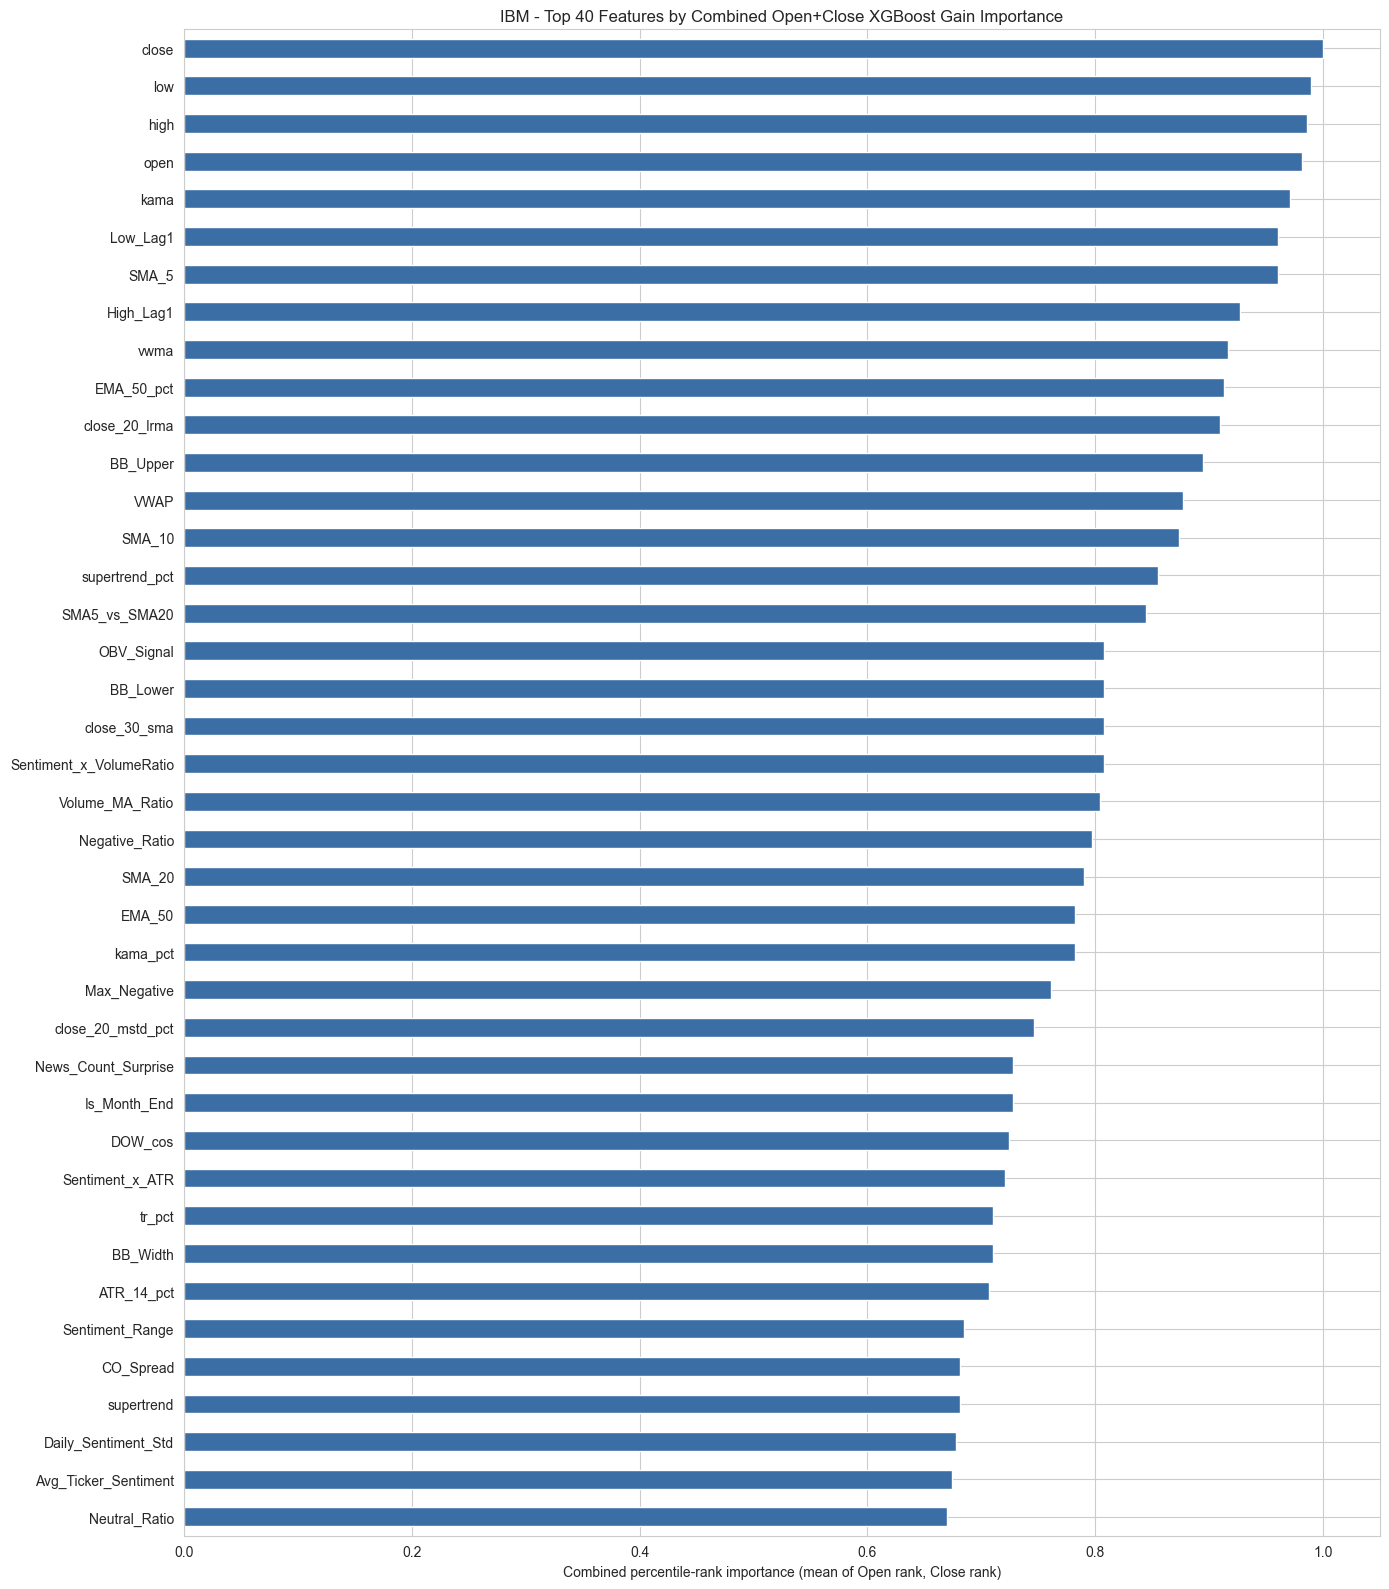


FEATURE SELECTION RESULTS — IBM

Selected 40 features:
  - close
  - low
  - high
  - open
  - kama
  - Low_Lag1
  - SMA_5
  - High_Lag1
  - vwma
  - EMA_50_pct
  - close_20_lrma
  - BB_Upper
  - VWAP
  - SMA_10
  - supertrend_pct
  - SMA5_vs_SMA20
  - BB_Lower
  - close_30_sma
  - OBV_Signal
  - Sentiment_x_VolumeRatio
  - Volume_MA_Ratio
  - Negative_Ratio
  - SMA_20
  - EMA_50
  - kama_pct
  - Max_Negative
  - close_20_mstd_pct
  - News_Count_Surprise
  - Is_Month_End
  - DOW_cos
  - Sentiment_x_ATR
  - tr_pct
  - BB_Width
  - ATR_14_pct
  - Sentiment_Range
  - CO_Spread
  - supertrend
  - Daily_Sentiment_Std
  - Avg_Ticker_Sentiment
  - Neutral_Ratio

Overlap diagnostics (top-40 by each target alone):

Top 10 rows of importance_df:
            reg_close_importance  reg_open_importance  close_rank  open_rank  \
close                   0.578278             0.767081    1.000000   1.000000   
low                     0.130715             0.095611    0.985507   0.992754   
high         

In [95]:
def select_features(train_df, val_df, feature_cols, config, seed, ticker):
    """Section 4: XGBoost-importance feature selection, ranked against BOTH the Open and
    Close targets and combined (mean percentile rank) -- so the selected feature set is not
    biased toward whichever target happens to be tuned first. This matches the 'Open and
    Close count equally' principle used for hyperparameter tuning further down the pipeline."""
    X_train_raw = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_val_raw = val_df[feature_cols].replace([np.inf, -np.inf], np.nan)

    xgb_param_grid = {
        'n_estimators':     [100, 200, 400],
        'max_depth':        [5, 6, 8],
        'learning_rate':    [0.03, 0.05, 0.1],
        'subsample':        [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha':        [0, 0.01, 0.1],
        'reg_lambda':       [0.5, 1, 2],
    }

    def tune_xgb_importance_model(X, y, label, n_iter=10, n_splits=5):
        base_model = xgb.XGBRegressor(random_state=seed, n_jobs=1, importance_type='gain')
        tscv = TimeSeriesSplit(n_splits=n_splits)
        search = RandomizedSearchCV(
            base_model, xgb_param_grid, n_iter=n_iter, cv=tscv,
            scoring='neg_mean_squared_error', random_state=seed, n_jobs=-1, verbose=0,
        )
        search.fit(X, y)
        print(f"Best {label} XGBoost params (CV MSE={-search.best_score_:.6f}): {search.best_params_}")
        return search.best_params_

    def fit_importance_model(target_col, label):
        best_params = tune_xgb_importance_model(X_train_raw, train_df[target_col], label)
        reg = xgb.XGBRegressor(
            **best_params, random_state=seed, n_jobs=-1, importance_type='gain',
            early_stopping_rounds=30, eval_metric='rmse',
        )
        reg.fit(
            X_train_raw, train_df[target_col],
            eval_set=[(X_train_raw, train_df[target_col]), (X_val_raw, val_df[target_col])],
            verbose=False,
        )
        print(f"{label} model stopped at iteration {reg.best_iteration} "
              f"(best val RMSE={reg.best_score:.4f})")
        imp = pd.Series(reg.feature_importances_, index=feature_cols, name=f'reg_{label.lower()}_importance')
        return reg, imp

    xgb_reg_close, imp_reg_close = fit_importance_model('target_next_close', 'CLOSE')
    xgb_reg_open, imp_reg_open = fit_importance_model('target_next_open', 'OPEN')

    importance_df = pd.concat([imp_reg_close, imp_reg_open], axis=1)
    importance_df['close_rank'] = importance_df['reg_close_importance'].rank(pct=True)
    importance_df['open_rank'] = importance_df['reg_open_importance'].rank(pct=True)
    importance_df['importance_rank'] = (importance_df['close_rank'] + importance_df['open_rank']) / 2
    importance_df = importance_df.sort_values('importance_rank', ascending=False)

    K = config['TOP_K_FEATURES']
    selected_features = importance_df.head(K).index.tolist()
    print(f"Selected {len(selected_features)} features (top-{K} by combined Open+Close gain importance)")
    
    K = config['TOP_K_FEATURES']

    # Top-K if you'd selected by EACH target alone (not the combined rank actually used)
    top_by_close = set(importance_df.sort_values('reg_close_importance', ascending=False).head(K).index)
    top_by_open = set(importance_df.sort_values('reg_open_importance', ascending=False).head(K).index)

    shared = top_by_close & top_by_open
    close_only = top_by_close - top_by_open
    open_only = top_by_open - top_by_close

    print(f"Out of the top-{K} features:")
    print(f"  Selected by BOTH Open and Close: {len(shared)}")
    print(f"  Overlap: {len(shared)}/{K} = {len(shared)/K:.0%}")

    fig, ax = plt.subplots(figsize=(14, 16))
    sel_imp = importance_df.loc[selected_features].sort_values('importance_rank')
    sel_imp['importance_rank'].plot(kind='barh', ax=ax, color='#3b6ea5')
    ax.set_title(f'{ticker} - Top {K} Features by Combined Open+Close XGBoost Gain Importance')
    ax.set_xlabel('Combined percentile-rank importance (mean of Open rank, Close rank)')
    plt.tight_layout()
    plt.savefig(f'{ticker}_XGBoost_Feature_Importance.jpg')
    plt.show()

    return {
        'selected_features': selected_features,
        'importance_df': importance_df,
        'xgb_reg_close': xgb_reg_close,
        'xgb_reg_open': xgb_reg_open,
        'shared': shared,
        'close_only': close_only,
        'open_only': open_only,
    }
result = select_features(train_df, val_df, feature_cols, CONFIG, SEED, TICKER)

print("\n" + "="*60)
print(f"FEATURE SELECTION RESULTS — {TICKER}")
print("="*60)
print(f"\nSelected {len(result['selected_features'])} features:")
for f in result['selected_features']:
    print(f"  - {f}")

print(f"\nOverlap diagnostics (top-{CONFIG['TOP_K_FEATURES']} by each target alone):")

print("\nTop 10 rows of importance_df:")
print(result['importance_df'].head(10))

In [8]:
# Create the output folder structure for this ticker (if it doesn't already exist)
selected_features = result['selected_features']

### 5. Feature Scaling

Fit `StandardScaler`s on the **training set only**, then transform validation/test — this avoids leaking validation/test statistics into training.


In [ ]:
# Replace infinite values with NaN in the original dataframes for the selected features.
# train_df / val_df / test_df are independent copies of the split (Section 3), separate
# from X_train_raw (Section 4), so infinities must be cleaned here again before scaling.
for df_name, df_obj in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
    for col in selected_features:
        if df_obj[col].isin([np.inf, -np.inf]).any():
            df_obj[col] = df_obj[col].replace([np.inf, -np.inf], np.nan)
            print(f"Infinite values in {df_name} column '{col}' replaced with NaN.")

# Impute NaN values with the mean before scaling
imputer = SimpleImputer(strategy='mean')

# Fit scalers and imputer on TRAIN ONLY, then transform val/test -> avoids leaking val/test statistics into training
x_scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(train_df[selected_features])
X_train_scaled = x_scaler.fit_transform(X_train_imputed)

X_val_imputed = imputer.transform(val_df[selected_features])
X_val_scaled   = x_scaler.transform(X_val_imputed)

X_test_imputed = imputer.transform(test_df[selected_features])
X_test_scaled  = x_scaler.transform(X_test_imputed)

y_scaler_open  = StandardScaler()
y_scaler_close = StandardScaler()

y_train_reg = np.hstack([
    y_scaler_open.fit_transform(train_df[['target_next_open']]),
    y_scaler_close.fit_transform(train_df[['target_next_close']]),
])
y_val_reg = np.hstack([
    y_scaler_open.transform(val_df[['target_next_open']]),
    y_scaler_close.transform(val_df[['target_next_close']]),
])
y_test_reg = np.hstack([
    y_scaler_open.transform(test_df[['target_next_open']]),
    y_scaler_close.transform(test_df[['target_next_close']]),
])

print('Scaled feature matrix shapes:', X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)


Scaled feature matrix shapes: (1971, 40) (246, 40) (247, 40)


## 6. Sliding-Window Sequence Construction

Convert the scaled tabular features into overlapping `WINDOW`-length sequences so every sequence model receives the trailing window of days as input.


In [ ]:
# Window size sweep to find the best number of timesteps for the sequence models. This is a small, fast LSTM model used only for this sweep, not the final architecture.

def make_sequences(X, y, window):
    """For each i, the window covers days [i-window+1, i] (today included as the most
    recent day of context), and the label y[i] is target_next_* at day i, i.e. the close/
    open of day i+1. Each example is a clean 'last `window` days -> tomorrow' forecast,
    with no gap day between the most recent feature day and the target."""
    xs, ys = [], []
    for i in range(window - 1, len(X)):
        xs.append(X[i - window + 1:i + 1])
        ys.append(y[i])
    return np.array(xs), np.array(ys)

def build_sweep_model(timesteps, n_features, lstm_units=32, lr=1e-3):
    """Small, fast model used only to compare window sizes -- not the final architecture."""
    inp = layers.Input(shape=(timesteps, n_features))
    x = layers.LSTM(lstm_units)(inp)
    out = layers.Dense(2, activation='linear')(x)  # [open, close]
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return m

window_candidates = [10]
sweep_results = {}

for w in window_candidates:
    X_tr, y_tr = make_sequences(X_train_scaled, y_train_reg, w)
    X_va, y_va = make_sequences(X_val_scaled,   y_val_reg,   w)

    tf.keras.utils.set_random_seed(SEED)
    model = build_sweep_model(timesteps=w, n_features=X_tr.shape[2])

    es = callbacks.EarlyStopping(monitor='val_loss', patience=CONFIG['PATIENCE'],
                                  restore_best_weights=True)
    t0 = time.time()
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=CONFIG['EPOCHS'], batch_size=CONFIG['BATCH_SIZE'],
              callbacks=[es], verbose=0)

    val_loss = model.evaluate(X_va, y_va, verbose=0)
    sweep_results[w] = val_loss
    print(f"window={w:>3} -> val_loss={val_loss:.6f}  ({time.time()-t0:.1f}s)")

best_window = min(sweep_results, key=sweep_results.get)
print(f"\nBest window size: {best_window}")

window= 10 -> val_loss=7.286963  (11.5s)

Best window size: 10


In [ ]:
# Finalize the window size for the sequence models.
CONFIG['WINDOW_SIZE'] = best_window
WINDOW = CONFIG['WINDOW_SIZE']

X_train_seq, y_train_reg_seq = make_sequences(X_train_scaled, y_train_reg, WINDOW)
X_val_seq,   y_val_reg_seq   = make_sequences(X_val_scaled,   y_val_reg,   WINDOW)
X_test_seq,  y_test_reg_seq  = make_sequences(X_test_scaled,  y_test_reg,  WINDOW)

TIMESTEPS   = X_train_seq.shape[1]
N_FEATURES  = X_train_seq.shape[2]

print(f'Windowed shapes -> X_train: {X_train_seq.shape} | y_train_reg: {y_train_reg_seq.shape}')
print(f'TIMESTEPS={TIMESTEPS}, N_FEATURES={N_FEATURES}')


Windowed shapes -> X_train: (1962, 10, 40) | y_train_reg: (1962, 2)
TIMESTEPS=10, N_FEATURES=40


## 7. Interpretable Attention Mechanism

A reusable additive (Bahdanau-style) temporal attention layer, applied over an encoder's per-timestep outputs. Used by the BiLSTM + Attention architecture and later re-used for interpretability (Section 16).


In [12]:
class AttentionLayer(layers.Layer):
    """Additive (Bahdanau-style) temporal attention over an encoder's timestep outputs."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W))          # (batch, timesteps, 1)
        a = tf.nn.softmax(e, axis=1)                    # attention weights over timesteps
        context = tf.reduce_sum(x * a, axis=1)          # weighted context vector
        return context, a

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1]), (input_shape[0], input_shape[1], 1)


### 8. Evaluation Utilities

Shared regression scoring helper. Defined ahead of model training so the training harness below can call it.


In [ ]:
def eval_regressor(model, X, y_true_scaled, name):
    """
    Evaluate a two-output regression model for next-day Open and Close prices.

    The function calculates metrics in both:
    1. Standardized/scaled space, used for model comparison and tuning.
    2. Original price-dollar space, used for real-world error reporting.

    Parameters
    ----------
    model : tensorflow.keras.Model
        Trained model used to generate predictions.

    X : numpy.ndarray
        Input feature sequences.

    y_true_scaled : numpy.ndarray
        Scaled true values with two columns:
        column 0 = Open price
        column 1 = Close price

    name : str
        Name assigned to the model in the returned results.

    Returns
    -------
    row : dict
        Dictionary containing scaled-space and price-space metrics.

    predictions : tuple
        Tuple containing:
        open_true, open_pred, close_true, close_pred
        on the original price scale.
    """

    y_pred_scaled = model.predict(X, verbose=0)

    # Convert true and predicted values back to the original dollar-price scale.
    # These values are used for price-scale metrics and actual-vs-predicted plots.
    open_true = y_scaler_open.inverse_transform(
        y_true_scaled[:, [0]]
    ).ravel()

    close_true = y_scaler_close.inverse_transform(
        y_true_scaled[:, [1]]
    ).ravel()

    open_pred = y_scaler_open.inverse_transform(
        y_pred_scaled[:, [0]]
    ).ravel()

    close_pred = y_scaler_close.inverse_transform(
        y_pred_scaled[:, [1]]
    ).ravel()

    # Keep standardized values for scaled-space metrics.
    open_true_s = y_true_scaled[:, 0]
    close_true_s = y_true_scaled[:, 1]

    open_pred_s = y_pred_scaled[:, 0]
    close_pred_s = y_pred_scaled[:, 1]

    def metrics(y_t, y_p, label):
        mse = mean_squared_error(y_t, y_p)

        return {
            f"{label}_MSE": mse,
            f"{label}_RMSE": np.sqrt(mse),
            f"{label}_MAE": mean_absolute_error(y_t, y_p),
            f"{label}_MAPE": np.mean(
                np.abs((y_t - y_p) / (np.abs(y_t) + 1e-9))
            ) * 100,
        }

    row = {"Model": name}

    # Standardized metrics used for model comparison, ranking, and tuning.
    row.update(metrics(open_true_s, open_pred_s, "Open_Scaled"))
    row.update(metrics(close_true_s, close_pred_s, "Close_Scaled"))

    # Original dollar-price metrics used for real-world interpretation.
    row.update(metrics(open_true, open_pred, "Open_Price"))
    row.update(metrics(close_true, close_pred, "Close_Price"))

    return row, (open_true, open_pred, close_true, close_pred)

## 9. Training Harness

Shared helpers used by every architecture below: `to_results_table` collects the result
rows from multiple models into one comparison table, and `print_single_run_summary` prints the
standard Open/Close error breakdown for one model's result row.

`evaluate_with_paper_protocol` is the single training/evaluation entry point used for **every**
model in this notebook (Baseline, BiLSTM+Attention, Transformer, TCN, and both Optimized
variants). For a given architecture it:

- (A) retrains the model `n_runs` times (default 10) with different seeds and evaluates each
  run on the fixed held-out TEST set, and
- (B) runs a chronological (non-shuffled) `k_folds`-fold cross-validation (default 5) over the
  TRAINING set only.

Both (A) and (B) are done **separately for the Open target and the Close target** -- i.e. Open
gets its own 10 test-runs + 5 CV-folds, and Close gets its own 10 test-runs + 5 CV-folds, each
with its own MSE/RMSE/MAE/MAPE mean +/- std, rather than one number that blends the two targets
together. The function still returns `(result_row, model)` -- the first of the `n_runs` training
runs, evaluated with `eval_regressor` -- so every later section (tuning, plotting, attention
maps, complexity/latency, persistence) keeps using the same `<name>_reg` / `<name>_reg_result`
variables as before. Summary stats for all runs/folds are stored in `all_model_results`.


In [ ]:
def make_es(patience=None):
    return callbacks.EarlyStopping(monitor='val_loss',
                                    patience=patience or CONFIG['PATIENCE'],
                                    restore_best_weights=True)

def fit_and_time(model, X_tr, y_tr, X_va, y_va, epochs=None, batch_size=None, patience=None, verbose=0):
    epochs = epochs or CONFIG['EPOCHS']
    batch_size = batch_size or CONFIG['BATCH_SIZE']
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=batch_size,
                         callbacks=[make_es(patience)], verbose=verbose)
    return history, time.time() - t0


# Per-epoch train/validation loss for every model, keyed by model_label. Populated by
# evaluate_with_paper_protocol below and plotted in Section 15.5.
TRAINING_HISTORIES = {}

# Raw per-run / per-fold metric arrays (NOT just mean/std), keyed by model_label ->
# {'open_test': DataFrame, 'close_test': DataFrame, 'open_cv': DataFrame, 'close_cv': DataFrame}.
# Populated below by evaluate_with_paper_protocol. Section 15.6 (Statistical Significance
# Testing) reads from this -- the mean +/- std stored in all_model_results is not enough on
# its own to test whether a gap between two models is bigger than run-to-run noise.
RAW_RUN_METRICS = {}

# Unified per-architecture protocol: every model (Baseline, the 3 Advanced
# architectures, and every Optimized variant) goes through the same
# 10-independent-runs + 5-fold-CV robustness check, with Open and Close scored as
# two fully separate sets of runs/folds (their own mean +/- std), since they are
# different prediction targets and shouldn't be blended into one number.
# Results from evaluate_with_paper_protocol, keyed by model_label -> {'open': {...}, 'close': {...}}
all_model_results = {}

_OPEN_METRIC_KEYS  = ['Open_Scaled_MSE',  'Open_Scaled_RMSE',  'Open_Scaled_MAE',  'Open_Scaled_MAPE',
                      'Open_Price_MSE',   'Open_Price_RMSE',   'Open_Price_MAE',   'Open_Price_MAPE']
_CLOSE_METRIC_KEYS = ['Close_Scaled_MSE', 'Close_Scaled_RMSE', 'Close_Scaled_MAE', 'Close_Scaled_MAPE',
                      'Close_Price_MSE',  'Close_Price_RMSE',  'Close_Price_MAE',  'Close_Price_MAPE']


def evaluate_with_paper_protocol(build_fn, model_name, n_runs=10, k_folds=5, seed=None, **build_kwargs):
    """Train and evaluate one architecture the same way for every model in the notebook.

    (A) n_runs (default 10) independent retrains, each scored on the fixed held-out TEST
        set with `eval_regressor` -- Open and Close columns are kept as two separate arrays
        (own mean +/- std over the n_runs runs), not pooled together.
    (B) k_folds (default 5) chronological (non-shuffled) CV over the TRAINING set only --
        again Open and Close scored and averaged separately over the folds.

    The first of the n_runs training runs (seed) is kept as the model this architecture is
    represented by everywhere else in the notebook: its `eval_regressor` test-set row (plus
    the Val_* columns, needed for architecture selection in Section 14) is returned as
    `result_row`, and the fitted Keras model itself is returned as `model` -- so
    `base_reg`, `adv1_reg`, `adv2_reg`, `adv3_reg` (and their `_result` counterparts) are
    used consistently in every later section. The four tuned/optimized models built in
    Section 14 also go through this same function, one call per architecture.

    Stores the full Open/Close summary stats in `all_model_results[model_name]` and also
    returns `(result_row, model)`.
    """
    print(f"\n{'='*70}\n{model_name}\n{'='*70}")

    epochs = CONFIG['EPOCHS']
    batch_size = CONFIG['BATCH_SIZE']
    patience = CONFIG['PATIENCE']
    base_seed = seed if seed is not None else SEED

    # (A) n_runs independent runs -> held-out TEST set, Open & Close scored separately
    open_runs, close_runs = [], []
    result_row, model, history, train_s = None, None, None, None

    print(f"--- {model_name}: {n_runs} independent TEST-set runs ---")
    for run in range(n_runs):
        tf.keras.utils.set_random_seed(base_seed + run)
        run_model = build_fn(**build_kwargs)
        run_history, run_train_s = fit_and_time(run_model, X_train_seq, y_train_reg_seq,
                                                 X_val_seq, y_val_reg_seq,
                                                 epochs=epochs, batch_size=batch_size, patience=patience)
        r_test, _ = eval_regressor(run_model, X_test_seq, y_test_reg_seq, model_name)
        open_runs.append({k: r_test[k] for k in _OPEN_METRIC_KEYS})
        close_runs.append({k: r_test[k] for k in _CLOSE_METRIC_KEYS})
        print(f"  Run {run + 1}/{n_runs} -> Open RMSE={r_test['Open_Scaled_RMSE']:.4f} | "
              f"Close RMSE={r_test['Close_Scaled_RMSE']:.4f}")

        # First run only: this is the model/result_row every later section uses.
        if run == 0:
            model, history, train_s = run_model, run_history, run_train_s
            r_val, _ = eval_regressor(model, X_val_seq, y_val_reg_seq, model_name)
            result_row = dict(r_test)
            result_row.update({f'Val_{k}': v for k, v in r_val.items() if k != 'Model'})
            result_row['Train_s'] = train_s
            TRAINING_HISTORIES[model_name] = history.history

    open_test_df  = pd.DataFrame(open_runs)
    close_test_df = pd.DataFrame(close_runs)

    print(f"\n{n_runs}-run TEST performance -- OPEN  -> " + " | ".join(
        f"{c.replace('Open_Scaled_', '')}: {open_test_df[c].mean():.4f} +/- {open_test_df[c].std():.4f}"
        for c in _OPEN_METRIC_KEYS))
    print(f"{n_runs}-run TEST performance -- CLOSE -> " + " | ".join(
        f"{c.replace('Close_Scaled_', '')}: {close_test_df[c].mean():.4f} +/- {close_test_df[c].std():.4f}"
        for c in _CLOSE_METRIC_KEYS))

    # (B) k-fold CV on the training set (chronological, no shuffling), Open/Close separate
    kf = KFold(n_splits=k_folds, shuffle=False)
    open_cv, close_cv = [], []
    print(f"\n--- {model_name}: {k_folds}-fold chronological CV on the TRAINING set ---")
    for fold, (tr_idx, ho_idx) in enumerate(kf.split(X_train_seq), start=1):
        tf.keras.utils.set_random_seed(base_seed)
        fold_model = build_fn(**build_kwargs)
        es = callbacks.EarlyStopping(monitor='loss', patience=patience, restore_best_weights=True)
        fold_model.fit(X_train_seq[tr_idx], y_train_reg_seq[tr_idx],
                        epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)
        r_fold, _ = eval_regressor(fold_model, X_train_seq[ho_idx], y_train_reg_seq[ho_idx], model_name)
        open_cv.append({k: r_fold[k] for k in _OPEN_METRIC_KEYS})
        close_cv.append({k: r_fold[k] for k in _CLOSE_METRIC_KEYS})
        print(f"  Fold {fold}/{k_folds} -> Open RMSE={r_fold['Open_Scaled_RMSE']:.4f} | "
              f"Close RMSE={r_fold['Close_Scaled_RMSE']:.4f}")

    open_cv_df  = pd.DataFrame(open_cv)
    close_cv_df = pd.DataFrame(close_cv)

    print(f"\n{k_folds}-fold CV performance -- OPEN  -> " + " | ".join(
        f"{c.replace('Open_Scaled_', '')}: {open_cv_df[c].mean():.4f} +/- {open_cv_df[c].std():.4f}"
        for c in _OPEN_METRIC_KEYS))
    print(f"{k_folds}-fold CV performance -- CLOSE -> " + " | ".join(
        f"{c.replace('Close_Scaled_', '')}: {close_cv_df[c].mean():.4f} +/- {close_cv_df[c].std():.4f}"
        for c in _CLOSE_METRIC_KEYS))

    # Keep the raw per-run / per-fold arrays too (not just the mean/std collapsed into
    # all_model_results below) -- needed for the paired significance tests in Section 15.6.
    RAW_RUN_METRICS[model_name] = {
        'open_test':  open_test_df,
        'close_test': close_test_df,
        'open_cv':    open_cv_df,
        'close_cv':   close_cv_df,
    }

    all_model_results[model_name] = {
        'open': {
            **{c: open_test_df[c].mean() for c in _OPEN_METRIC_KEYS},
            **{f'{c}_std': open_test_df[c].std() for c in _OPEN_METRIC_KEYS},
            **{f'CV_{c}': open_cv_df[c].mean() for c in _OPEN_METRIC_KEYS},
        },
        'close': {
            **{c: close_test_df[c].mean() for c in _CLOSE_METRIC_KEYS},
            **{f'{c}_std': close_test_df[c].std() for c in _CLOSE_METRIC_KEYS},
            **{f'CV_{c}': close_cv_df[c].mean() for c in _CLOSE_METRIC_KEYS},
        },
    }

    return result_row, model


In [ ]:
# Baseline architecture: stacked GRU -> LSTM -> Dense trunk, regression head predicts [open, close]
def build_lstm_gru_baseline(gru_units=50, lstm_units=50, dense_units=50, dropout=0.2, lr=1e-3, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='window_input')
    x = layers.GRU(gru_units, return_sequences=True, name='gru_1', kernel_regularizer=reg, recurrent_regularizer=reg)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(gru_units, return_sequences=True, name='gru_2', kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=False, name='lstm_1', kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(x)

    out = layers.Dense(2, activation='linear', name='open_close', kernel_regularizer=reg)(x)   # [open, close]
    m = models.Model(inp, out, name='Baseline_LSTM_GRU_Regressor')
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

build_lstm_gru_baseline().summary()


# Baseline (LSTM+GRU): unified protocol (10 Open test-runs + 10 Close test-runs,
# (5 Open CV-folds + 5 Close CV-folds), keeps feeding base_reg / base_reg_result
base_reg_result, base_reg = evaluate_with_paper_protocol(build_lstm_gru_baseline, 'Baseline (LSTM+GRU)')

Model: "Baseline_LSTM_GRU_Regressor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 window_input (InputLayer)   [(None, 10, 40)]          0         
                                                                 
 gru_1 (GRU)                 (None, 10, 50)            13800     
                                                                 
 dropout (Dropout)           (None, 10, 50)            0         
                                                                 
 gru_2 (GRU)                 (None, 10, 50)            15300     
                                                                 
 dropout_1 (Dropout)         (None, 10, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_2 (Dropout)         (None, 50)

## 10. Advanced Model 1 - BiLSTM + Attention


In [ ]:
# Advanced 1: Bidirectional LSTM encoder + additive attention (see AttentionLayer above) over its outputs
def build_bilstm_attention(lstm_units=32, dense_units=32, dropout=0.3, lr=1e-3, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='window_input')
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg),
        name='bilstm'
    )(inp)
    x = layers.Dropout(dropout)(x)
    context, att_weights = AttentionLayer(name='attention')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(context)

    out = layers.Dense(2, activation='linear', name='open_close', kernel_regularizer=reg)(x)
    m = models.Model(inp, out, name='Advanced_BiLSTM_Attention_Regressor')
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

build_bilstm_attention().summary()

# BiLSTM+Attention: unified protocol (10 Open + 10 Close test-runs, 5 Open + 5 Close CV-folds)
adv1_reg_result, adv1_reg = evaluate_with_paper_protocol(build_bilstm_attention, 'Advanced 1 (BiLSTM+Attention)')

Model: "Advanced_BiLSTM_Attention_Regressor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 window_input (InputLayer)   [(None, 10, 40)]          0         
                                                                 
 bilstm (Bidirectional)      (None, 10, 64)            18688     
                                                                 
 dropout_48 (Dropout)        (None, 10, 64)            0         
                                                                 
 attention (AttentionLayer)  ((None, 64),              64        
                              (None, 10, 1))                     
                                                                 
 dense_17 (Dense)            (None, 32)                2080      
                                                                 
 open_close (Dense)          (None, 2)                 66        
                               

## 11. Advanced Model 2 - Time-Series Transformer


In [ ]:
# Advanced 2: one Transformer encoder block (self-attention + feed-forward, each with a residual + LayerNorm)
def transformer_encoder(x, head_size, num_heads, ff_dim, dropout, reg=None):
    attn_out = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x1 = layers.Add()([x, attn_out])
    x1 = layers.LayerNormalization(epsilon=1e-6)(x1)
    ff = layers.Dense(ff_dim, activation='relu', kernel_regularizer=reg)(x1)
    ff = layers.Dense(x.shape[-1], kernel_regularizer=reg)(ff)
    x2 = layers.Add()([x1, ff])
    x2 = layers.LayerNormalization(epsilon=1e-6)(x2)
    return x2

def build_transformer(d_model=32, num_blocks=2, head_size=16, num_heads=2, ff_dim=64,
                       dropout=0.2, dense_units=32, lr=1e-3, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='window_input')
    x = layers.Dense(d_model, kernel_regularizer=reg)(inp)   # project raw features to model dimension
    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout, reg=reg)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(x)

    out = layers.Dense(2, activation='linear', name='open_close', kernel_regularizer=reg)(x)
    m = models.Model(inp, out, name='Advanced_Transformer_Regressor')
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

build_transformer().summary()

# Transformer: unified protocol (10 Open + 10 Close test-runs, 5 Open + 5 Close CV-folds)
adv2_reg_result, adv2_reg = evaluate_with_paper_protocol(build_transformer, 'Advanced 2 (Transformer)')


Model: "Advanced_Transformer_Regressor"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 window_input (InputLayer)      [(None, 10, 40)]     0           []                               
                                                                                                  
 dense_33 (Dense)               (None, 10, 32)       1312        ['window_input[0][0]']           
                                                                                                  
 multi_head_attention (MultiHea  (None, 10, 32)      4224        ['dense_33[0][0]',               
 dAttention)                                                      'dense_33[0][0]']               
                                                                                                  
 add (Add)                      (None, 10, 32)       0           ['de

In [ ]:
# Advanced 2b (Hybrid / "updated Transformer"): the Baseline's GRU -> GRU -> LSTM recurrent
# trunk (same layers as build_lstm_gru_baseline, but every layer keeps return_sequences=True)
# feeds its full sequence output into the SAME transformer_encoder block used by Advanced 2,
# instead of projecting the raw input features straight into the encoder. This is the
# "baseline + transformer" hybrid: the recurrent trunk supplies short-range/local sequence
# smoothing, and the Transformer's self-attention on top supplies long-range/global
# dependency modeling.

def transformer_encoder(x, head_size, num_heads, ff_dim, dropout, reg=None):
    attn_out = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x1 = layers.Add()([x, attn_out])
    x1 = layers.LayerNormalization(epsilon=1e-6)(x1)
    ff = layers.Dense(ff_dim, activation='relu', kernel_regularizer=reg)(x1)
    ff = layers.Dense(x.shape[-1], kernel_regularizer=reg)(ff)
    x2 = layers.Add()([x1, ff])
    x2 = layers.LayerNormalization(epsilon=1e-6)(x2)
    return x2

def build_baseline_transformer(gru_units=50, lstm_units=50, d_model=32, num_blocks=2,
                                head_size=16, num_heads=2, ff_dim=64, dropout=0.2,
                                dense_units=50, lr=1e-3, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='window_input')

    # --- Baseline recurrent trunk (identical layer stack to build_lstm_gru_baseline, but
    #     every layer keeps return_sequences=True so the Transformer block below has a full
    #     timestep-by-timestep sequence to attend over, not just a single final state) ---
    x = layers.GRU(gru_units, return_sequences=True, name='gru_1',
                    kernel_regularizer=reg, recurrent_regularizer=reg)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(gru_units, return_sequences=True, name='gru_2',
                    kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm_1',
                     kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)

    # --- Transformer encoder on top of the recurrent trunk's output (reuses the
    #     transformer_encoder helper defined for Advanced 2 above) ---
    x = layers.Dense(d_model, kernel_regularizer=reg)(x)   # project trunk output to model dimension
    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout, reg=reg)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(x)

    out = layers.Dense(2, activation='linear', name='open_close', kernel_regularizer=reg)(x)
    m = models.Model(inp, out, name='Advanced_Baseline_Transformer_Regressor')
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

build_baseline_transformer().summary()

# Baseline+Transformer (updated Transformer): unified protocol (10 Open + 10 Close test-runs, 5 Open + 5 Close CV-folds)
adv2b_reg_result, adv2b_reg = evaluate_with_paper_protocol(build_baseline_transformer, 'Advanced 2b (Baseline+Transformer)')


Model: "Advanced_Baseline_Transformer_Regressor"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 window_input (InputLayer)      [(None, 10, 40)]     0           []                               
                                                                                                  
 gru_1 (GRU)                    (None, 10, 50)       13800       ['window_input[0][0]']           
                                                                                                  
 dropout_64 (Dropout)           (None, 10, 50)       0           ['gru_1[0][0]']                  
                                                                                                  
 gru_2 (GRU)                    (None, 10, 50)       15300       ['dropout_64[0][0]']             
                                                            

## 12. Advanced Model 3 - Temporal Convolutional Network (TCN)

Dilated causal-convolution residual blocks (dilation rates 1, 2, 4, 8) give the network a
receptive field spanning the whole window without any recurrence - typically faster
to train than RNN-based models and competitive on sequence benchmarks.


In [ ]:
# Advanced 3: dilated causal-conv residual block -- stacking dilations 1,2,4,8 gives a wide receptive
# field over the whole window without any recurrence (faster to train than RNN-based models)
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout, reg=None):
    prev = x
    y = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu', kernel_regularizer=reg)(x)
    y = layers.Dropout(dropout)(y)
    y = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu', kernel_regularizer=reg)(y)
    y = layers.Dropout(dropout)(y)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding='same', kernel_regularizer=reg)(prev)
    return layers.Add()([prev, y])

def build_tcn(filters=32, kernel_size=3, dilations=(1, 2, 4), dense_units=32, dropout=0.2, lr=1e-3, l2_reg=0.0):
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='window_input')
    x = inp
    for d in dilations:
        x = tcn_residual_block(x, filters, kernel_size, d, dropout, reg=reg)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(x)

    out = layers.Dense(2, activation='linear', name='open_close', kernel_regularizer=reg)(x)
    m = models.Model(inp, out, name='Advanced_TCN_Regressor')
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

build_tcn().summary()

# TCN: unified protocol (10 Open + 10 Close test-runs, 5 Open + 5 Close CV-folds)
adv3_reg_result, adv3_reg = evaluate_with_paper_protocol(build_tcn, 'Advanced 3 (TCN)')


Model: "Advanced_TCN_Regressor"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 window_input (InputLayer)      [(None, 10, 40)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 10, 32)       3872        ['window_input[0][0]']           
                                                                                                  
 dropout_112 (Dropout)          (None, 10, 32)       0           ['conv1d[0][0]']                 
                                                                                                  
 conv1d_1 (Conv1D)              (None, 10, 32)       3104        ['dropout_112[0][0]']            
                                                                             

## 13. Paper-Protocol Robustness Summary (all 4 architectures)

Side-by-side comparison of the 10-run TEST mean/std and the 5-fold CV mean for every architecture, collected from `all_model_results` -- shown as two separate tables, one for the Open target and one for the Close target.


In [20]:
open_summary_cols = ['Open_Scaled_MSE', 'Open_Scaled_MSE_std', 'Open_Scaled_RMSE', 'Open_Scaled_RMSE_std',
                     'Open_Scaled_MAE', 'Open_Scaled_MAE_std', 'Open_Scaled_MAPE', 'Open_Scaled_MAPE_std',
                     'CV_Open_Scaled_MSE', 'CV_Open_Scaled_RMSE', 'CV_Open_Scaled_MAE', 'CV_Open_Scaled_MAPE']
close_summary_cols = [c.replace('Open', 'Close') for c in open_summary_cols]

paper_protocol_df_open  = pd.DataFrame({m: r['open']  for m, r in all_model_results.items()}).T[open_summary_cols]
paper_protocol_df_close = pd.DataFrame({m: r['close'] for m, r in all_model_results.items()}).T[close_summary_cols]

print('--- OPEN target: 10-run TEST mean/std + 5-fold CV mean, per architecture ---')
display(paper_protocol_df_open.style.format('{:.4f}'))

print('\n--- CLOSE target: 10-run TEST mean/std + 5-fold CV mean, per architecture ---')
display(paper_protocol_df_close.style.format('{:.4f}'))


--- OPEN target: 10-run TEST mean/std + 5-fold CV mean, per architecture ---


,Open_Scaled_MSE,Open_Scaled_MSE_std,Open_Scaled_RMSE,Open_Scaled_RMSE_std,Open_Scaled_MAE,Open_Scaled_MAE_std,Open_Scaled_MAPE,Open_Scaled_MAPE_std,CV_Open_Scaled_MSE,CV_Open_Scaled_RMSE,CV_Open_Scaled_MAE,CV_Open_Scaled_MAPE
Baseline (LSTM+GRU),63.2844,2.0896,7.9542,0.1321,7.7093,0.1357,63.8649,1.1688,0.1444,0.2664,0.1797,52.3642
Advanced 1 (BiLSTM+Attention),57.5241,2.7241,7.5825,0.1804,7.3410,0.1818,60.7838,1.5456,0.1832,0.3258,0.2367,58.5479
Advanced 2 (Transformer),70.5702,3.0794,8.3988,0.1812,8.1856,0.1825,68.1273,1.5721,0.1926,0.3640,0.2685,130.1753
Advanced 2b (Baseline+Transformer),70.8474,1.8738,8.4164,0.1114,8.1853,0.1115,67.9742,0.9464,0.1804,0.3556,0.2507,88.3211
Advanced 3 (TCN),0.3890,0.1290,0.6160,0.1027,0.4781,0.0938,4.1213,0.7416,0.0385,0.1891,0.1458,64.2965



--- CLOSE target: 10-run TEST mean/std + 5-fold CV mean, per architecture ---


,Close_Scaled_MSE,Close_Scaled_MSE_std,Close_Scaled_RMSE,Close_Scaled_RMSE_std,Close_Scaled_MAE,Close_Scaled_MAE_std,Close_Scaled_MAPE,Close_Scaled_MAPE_std,CV_Close_Scaled_MSE,CV_Close_Scaled_RMSE,CV_Close_Scaled_MAE,CV_Close_Scaled_MAPE
Baseline (LSTM+GRU),62.9707,2.0149,7.9345,0.1276,7.6956,0.1309,63.7943,1.1272,0.1553,0.2906,0.1991,60.6083
Advanced 1 (BiLSTM+Attention),56.2897,2.0404,7.5015,0.1354,7.2642,0.1389,60.1658,1.1970,0.2913,0.4037,0.2987,84.0785
Advanced 2 (Transformer),69.6731,4.3547,8.3433,0.2618,8.1335,0.2704,67.7125,2.3581,0.1896,0.3662,0.2739,92.4487
Advanced 2b (Baseline+Transformer),72.4345,2.5652,8.5097,0.1499,8.2854,0.1507,68.8718,1.2804,0.2132,0.3882,0.2828,78.6384
Advanced 3 (TCN),0.4620,0.0538,0.6786,0.0398,0.5208,0.0397,4.4795,0.3135,0.0607,0.2384,0.1800,67.9984


## 14. Hyperparameter Optimization

Every architecture is tuned individually with Keras Tuner -- **all four** (Baseline, BiLSTM+Attention, Transformer, TCN), not just a single 'winning' architecture. We tune all four rather than only the strongest performer from Section 13 because the strongest *untuned* architecture is not guaranteed to still be the strongest once every architecture gets the same tuning budget -- tuning a single hand-picked winner would bias the comparison in Section 15 toward whichever model happened to look best before any tuning at all.

Each architecture's search optimizes a single **combined objective**, `val_mean_rmse` (`MeanColumnRMSE` in 14.1 below) -- the average of the Open-column RMSE and the Close-column RMSE -- so Open and Close have equal say in what counts as the 'best' hyperparameter configuration for that architecture, rather than tuning twice per architecture (once per target) and doubling the compute cost for a marginal benefit. The winning configuration for each architecture is then put through the same 10-independent-run + 5-fold-CV protocol as every other model in this notebook (Section 9), so tuned and untuned models are judged by an identical, fair evaluation.

**Search budget and computational cost:** each architecture's search runs `max_trials=10` random-search trials, `executions_per_trial=2` (no repeated executions per trial, since the trial-selection decision is only used to pick hyperparameters -- the winning configuration's final reported performance instead comes from the 10-run/5-fold protocol above), and each trial trains for up to `tune_epochs=25` epochs (capped further by early stopping, patience 10, on the same `val_mean_rmse` objective being optimized). That is 4 architectures x 8 trials = 32 total tuning trials across this section. Section 14.3 reports, per architecture, the exact number of trials completed, the wall-clock search time, and the best validation objective the search converged to, so the trade-off between search cost and the tuned model's Section 15 accuracy gain can be judged directly rather than assumed.


In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner
import keras_tuner as kt

# Every architecture (baseline + all 3 advanced models) is tuned individually, each on a
# COMBINED objective (the mean of its Open RMSE and Close RMSE, see MeanColumnRMSE in the
# next cell), so Open and Close both have equal say in what counts as 'best'.
ARCHITECTURES_TO_TUNE = ['baseline', 'bilstm_attention', 'transformer','baseline_transformer','tcn']

print('Architectures to be tuned (all four, combined Open+Close objective):')
for arch in ARCHITECTURES_TO_TUNE:
    print(f'  - {arch}')


e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Scripts\python.exe: No module named pip


Architectures to be tuned (all four, combined Open+Close objective):
  - baseline
  - bilstm_attention
  - transformer
  - baseline_transformer
  - tcn


In [22]:
class ColumnRMSE(tf.keras.metrics.Metric):
    # Stateful per-column RMSE: accumulates squared error for one column (0=Open, 1=Close)
    # of the [open, close] target across a FULL epoch before taking the square root, so it
    # reports true epoch-level RMSE -- not an average of per-batch RMSEs (which would be
    # biased high by Jensen's inequality). This lets Keras Tuner select hyperparameters on
    # the exact metric we report in Section 15 (Open_Scaled_RMSE / Close_Scaled_RMSE).
    def __init__(self, column, name='column_rmse', **kwargs):
        super().__init__(name=name, **kwargs)
        self.column = column
        self.sum_sq_error = self.add_weight(name='sum_sq_error', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_t = tf.cast(y_true[:, self.column], tf.float32)
        y_p = tf.cast(y_pred[:, self.column], tf.float32)
        sq_err = tf.square(y_t - y_p)
        self.sum_sq_error.assign_add(tf.reduce_sum(sq_err))
        self.count.assign_add(tf.cast(tf.size(sq_err), tf.float32))

    def result(self):
        return tf.sqrt(self.sum_sq_error / self.count)

    def reset_state(self):
        self.sum_sq_error.assign(0.0)
        self.count.assign(0.0)




class MeanColumnRMSE(tf.keras.metrics.Metric):
    """Average of the Open-column RMSE and the Close-column RMSE, each computed
    independently then averaged together -- used as a single combined tuning objective
    ('mean_rmse') so hyperparameter search treats Open and Close equally, instead of
    optimizing only one of them at a time."""
    def __init__(self, name='mean_rmse', **kwargs):
        super().__init__(name=name, **kwargs)
        self.sum_sq_open  = self.add_weight(name='sum_sq_open',  initializer='zeros')
        self.sum_sq_close = self.add_weight(name='sum_sq_close', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_t_open,  y_p_open  = tf.cast(y_true[:, 0], tf.float32), tf.cast(y_pred[:, 0], tf.float32)
        y_t_close, y_p_close = tf.cast(y_true[:, 1], tf.float32), tf.cast(y_pred[:, 1], tf.float32)
        self.sum_sq_open.assign_add(tf.reduce_sum(tf.square(y_t_open - y_p_open)))
        self.sum_sq_close.assign_add(tf.reduce_sum(tf.square(y_t_close - y_p_close)))
        self.count.assign_add(tf.cast(tf.size(y_t_open), tf.float32))

    def result(self):
        open_rmse  = tf.sqrt(self.sum_sq_open  / self.count)
        close_rmse = tf.sqrt(self.sum_sq_close / self.count)
        return (open_rmse + close_rmse) / 2.0

    def reset_state(self):
        self.sum_sq_open.assign(0.0)
        self.sum_sq_close.assign(0.0)
        self.count.assign(0.0)

def _with_target_metrics(model):
    # Recompile a freshly-built model, adding open_rmse / close_rmse on top of its existing
    # loss/optimizer, so the tuner can search on either one directly. A fresh ColumnRMSE
    # instance is created every call since metric objects hold state and can't be shared
    # across models.
    model.compile(
        optimizer=model.optimizer, loss=model.loss,
        metrics=['mae', ColumnRMSE(column=0, name='open_rmse'), ColumnRMSE(column=1, name='close_rmse'),
                 MeanColumnRMSE()],
    )
    return model

def build_hypermodel_baseline(hp):
    gru_units = hp.Choice('gru_units', [16, 32, 64, 128])
    lstm_units = hp.Choice('lstm_units', [16, 32, 64, 128])
    dense_units = hp.Choice('dense_units', [16, 32, 64, 128])
    dropout = hp.Choice('dropout', [0.2, 0.3, 0.4])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    l2_reg = hp.Choice('l2_reg', [0.0, 1e-4, 1e-3, 1e-2])
    m = build_lstm_gru_baseline(gru_units=gru_units, lstm_units=lstm_units,
                                 dense_units=dense_units, dropout=dropout, lr=lr, l2_reg=l2_reg)
    return _with_target_metrics(m)

def build_hypermodel_bilstm(hp):
    units = hp.Choice('lstm_units', [16, 32, 64, 128])
    dense_units = hp.Choice('dense_units', [16, 32, 64, 128])
    dropout = hp.Choice('dropout', [0.2, 0.3, 0.4])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    l2_reg = hp.Choice('l2_reg', [0.0, 1e-4, 1e-3])
    m = build_bilstm_attention(lstm_units=units, dense_units=dense_units,
                                dropout=dropout, lr=lr, l2_reg=l2_reg)
    return _with_target_metrics(m)

def build_hypermodel_transformer(hp):
    d_model = hp.Choice('d_model', [16, 32, 64, 128])
    num_heads = hp.Choice('num_heads', [2, 4])
    ff_dim = hp.Choice('ff_dim', [32, 64, 128])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    l2_reg = hp.Choice('l2_reg', [0.0, 1e-4, 1e-3])
    m = build_transformer(d_model=d_model, num_heads=num_heads, ff_dim=ff_dim,
                           dropout=dropout, lr=lr, l2_reg=l2_reg)
    return _with_target_metrics(m)

def build_hypermodel_baseline_transformer(hp):
    gru_units = hp.Choice('gru_units', [16, 32, 64, 128])
    lstm_units = hp.Choice('lstm_units', [16, 32, 64, 128])
    d_model = hp.Choice('d_model', [16, 32, 64, 128])
    num_heads = hp.Choice('num_heads', [2, 4])
    ff_dim = hp.Choice('ff_dim', [32, 64, 128])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    l2_reg = hp.Choice('l2_reg', [0.0, 1e-4, 1e-3])
    m = build_baseline_transformer(gru_units=gru_units, lstm_units=lstm_units, d_model=d_model,
                                    num_heads=num_heads, ff_dim=ff_dim, dropout=dropout,
                                    lr=lr, l2_reg=l2_reg)
    return _with_target_metrics(m)

def build_hypermodel_tcn(hp):
    filters = hp.Choice('filters', [16, 32, 64, 128])
    kernel_size = hp.Choice('kernel_size', [3, 5, 7, 9])
    dense_units = hp.Choice('dense_units', [16, 32, 64, 128])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    l2_reg = hp.Choice('l2_reg', [0.0, 1e-4])
    m = build_tcn(filters=filters, kernel_size=kernel_size, dense_units=dense_units,
                  dropout=dropout, lr=lr, l2_reg=l2_reg)
    return _with_target_metrics(m)

# maps architecture name -> (plain build_fn used for the final single training run,
#                            hypermodel build_fn used only by the keras-tuner search)
BUILD_FN_MAP = {
    'baseline':             (build_lstm_gru_baseline,     build_hypermodel_baseline),
    'bilstm_attention':     (build_bilstm_attention,      build_hypermodel_bilstm),
    'transformer':          (build_transformer,           build_hypermodel_transformer),
    'baseline_transformer': (build_baseline_transformer, build_hypermodel_baseline_transformer),
    'tcn':                  (build_tcn,                   build_hypermodel_tcn),
}

# Logs full search-budget / computational-cost info per (architecture, metric_focus) tuning
# run: trials requested vs. actually completed, epochs-per-trial cap, executions per trial,
# wall-clock search time, and the best validation objective the search converged to.
# Reported as a summary table in Section 14.3.
TUNING_BUDGET_LOG = {}

def tune_model(architecture, metric_focus, max_trials=10, tune_epochs=25, executions_per_trial=2):
    # Run a Keras Tuner random search for the given architecture name ('bilstm_attention',
    # 'transformer', or 'tcn'), selecting hyperparameters by the given TARGET's own scaled
    # RMSE (metric_focus='open' -> minimizes val_open_rmse, metric_focus='close' -> minimizes
    # val_close_rmse) instead of the combined val_loss. This is what makes the close-focused
    # and open-focused searches genuinely different: they can land on different
    # hyperparameters for the SAME architecture, because they're being scored on different
    # columns of the output. Early stopping is tied to the same metric being optimized, for
    # consistency. Each call gets its own tuner directory (keyed by architecture +
    # metric_focus) so the two searches never overwrite each other's trial history.
    _, hyper_build_fn = BUILD_FN_MAP[architecture]
    objective_name = f'val_{metric_focus}_rmse'

    tuner = kt.RandomSearch(
        hyper_build_fn,
        objective=kt.Objective(objective_name, direction='min'),
        max_trials=max_trials,
        executions_per_trial=executions_per_trial,
        overwrite=True,
        directory='kt_search',
        project_name=f'milestone5_{TICKER}_regression_{architecture}_{metric_focus}',
        seed=SEED,
    )
    es = callbacks.EarlyStopping(monitor=objective_name, mode='min',
                                  patience=CONFIG['PATIENCE'], restore_best_weights=True)

    # Wall-clock the search itself (not just individual model training) so we can report the
    # real computational cost of the hyperparameter search, not just the trial count.
    search_t0 = time.time()
    tuner.search(X_train_seq, y_train_reg_seq, validation_data=(X_val_seq, y_val_reg_seq),
                 epochs=tune_epochs, batch_size=CONFIG['BATCH_SIZE'],
                 callbacks=[es], verbose=0)
    search_wall_clock_s = time.time() - search_t0

    # oracle.trials holds every trial actually run (can be < max_trials if the search space
    # is exhausted, or exactly max_trials otherwise -- either way this reports the true count
    # rather than assuming max_trials trials always completed).
    trials_completed = len(tuner.oracle.trials)
    best_trial = tuner.oracle.get_best_trials(1)[0]
    best_val_objective = best_trial.score

    TUNING_BUDGET_LOG[(architecture, metric_focus)] = {
        'Architecture': architecture,
        'Tuning objective': objective_name,
        'Trials completed': trials_completed,
        'Trials requested (max_trials)': max_trials,
        'Executions per trial': executions_per_trial,
        'Epoch cap per trial': tune_epochs,
        'Early-stopping patience': CONFIG['PATIENCE'],
        'Search wall-clock (s)': search_wall_clock_s,
        f'Best val {objective_name}': best_val_objective,
    }

    print(f'  Search budget -- trials: {trials_completed}/{max_trials} | '
          f'executions/trial: {executions_per_trial} | epoch cap/trial: {tune_epochs} | '
          f'search time: {search_wall_clock_s:.1f}s ({search_wall_clock_s/60:.1f} min) | '
          f'best {objective_name}: {best_val_objective:.4f}')

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f'Best hyperparameters for {architecture} (optimizing {objective_name}): {best_hp.values}')
    return best_hp


### 14.2 Optimized Models - Tune & Evaluate Every Architecture (Combined Open+Close Objective)


In [23]:
# Tune EVERY architecture individually (not just one selected 'winner'), each using the
# combined Open+Close objective (val_mean_rmse) from MeanColumnRMSE above. This produces
# one tuned/optimized version of each of the four architectures, all judged by the same
# fair, combined criterion -- and all four flow into Section 15's comparison tables below.

optimized_results = {}   # architecture name -> (result_row, model)
optimized_hps      = {}   # architecture name -> best_hp found by the tuner

for architecture in ARCHITECTURES_TO_TUNE:
    print(f"\n{'#'*70}\nTuning architecture: {architecture}\n{'#'*70}")

    best_hp = tune_model(architecture, metric_focus='mean')
    optimized_hps[architecture] = best_hp

    build_fn, _ = BUILD_FN_MAP[architecture]
    model_label = f'Optimized ({architecture})'

    result_row, model = evaluate_with_paper_protocol(
        build_fn, model_label, **best_hp.values)

    optimized_results[architecture] = (result_row, model)



######################################################################
Tuning architecture: baseline
######################################################################
INFO:tensorflow:Oracle triggered exit
  Search budget -- trials: 10/10 | executions/trial: 2 | epoch cap/trial: 25 | search time: 1336.9s (22.3 min) | best val_mean_rmse: 2.1941
Best hyperparameters for baseline (optimizing val_mean_rmse): {'gru_units': 128, 'lstm_units': 16, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.01, 'l2_reg': 0.0001}

Optimized (baseline)
--- Optimized (baseline): 10 independent TEST-set runs ---
  Run 1/10 -> Open RMSE=7.8996 | Close RMSE=7.8750
  Run 2/10 -> Open RMSE=8.4882 | Close RMSE=8.5312
  Run 3/10 -> Open RMSE=8.5347 | Close RMSE=8.5552
  Run 4/10 -> Open RMSE=8.1204 | Close RMSE=7.9296
  Run 5/10 -> Open RMSE=8.1953 | Close RMSE=8.2312
  Run 6/10 -> Open RMSE=7.9727 | Close RMSE=7.9606
  Run 7/10 -> Open RMSE=8.0559 | Close RMSE=8.0309
  Run 8/10 -> Open RMSE=8.1717 | Close RMSE=8.1

### 14.3 Hyperparameter Search Budget & Computational Cost

For every architecture's tuning run: how many trials were actually completed versus requested, the epoch cap per trial (and how that interacts with early stopping), executions per trial, the wall-clock time the search itself took, and the best validation objective (`val_mean_rmse`) the search converged to. This is the concrete search-budget/cost accounting the tuning section above summarizes in words -- reported here as numbers so the cost of tuning each architecture can be weighed directly against the accuracy gain it buys in Section 15 and the complexity/latency trade-off in Section 17.


In [24]:
tuning_budget_df = pd.DataFrame(list(TUNING_BUDGET_LOG.values()))

# Column order: identity -> budget knobs -> cost/outcome, so the table reads left-to-right
# as 'what was asked for' -> 'what it cost' -> 'what it achieved'.
_budget_cols = ['Architecture', 'Tuning objective', 'Trials completed',
                'Trials requested (max_trials)', 'Executions per trial',
                'Epoch cap per trial', 'Early-stopping patience',
                'Search wall-clock (s)']
_outcome_cols = [c for c in tuning_budget_df.columns if c not in _budget_cols]
tuning_budget_df = tuning_budget_df[_budget_cols + _outcome_cols]

total_trials = tuning_budget_df['Trials completed'].sum()
total_search_time_s = tuning_budget_df['Search wall-clock (s)'].sum()
print(f'Total tuning trials completed across all {len(tuning_budget_df)} architecture '
      f'searches: {total_trials}')
print(f'Total hyperparameter-search compute time: {total_search_time_s:.1f}s '
      f'(~{total_search_time_s/60:.1f} min)')

display(tuning_budget_df.style.format({
    'Search wall-clock (s)': '{:.1f}',
    **{c: '{:.4f}' for c in _outcome_cols},
}))


Total tuning trials completed across all 5 architecture searches: 50
Total hyperparameter-search compute time: 5675.4s (~94.6 min)


,Architecture,Tuning objective,Trials completed,Trials requested (max_trials),Executions per trial,Epoch cap per trial,Early-stopping patience,Search wall-clock (s),Best val val_mean_rmse
0,baseline,val_mean_rmse,10,10,2,25,10,1336.9,2.1941
1,bilstm_attention,val_mean_rmse,10,10,2,25,10,1098.3,1.8628
2,transformer,val_mean_rmse,10,10,2,25,10,888.0,2.7241
3,baseline_transformer,val_mean_rmse,10,10,2,25,10,1254.6,2.6105
4,tcn,val_mean_rmse,10,10,2,25,10,1097.5,0.2996


In [ ]:
# Convert a list of per-model result dicts into a comparison table.
def to_results_table(result_rows, sort_col='Close_Scaled_MSE', ascending=True):
    """Convert a list of per-model result dicts into a comparison table."""
    results_df = pd.DataFrame(result_rows).copy()
    if 'Model' not in results_df.columns:
        results_df.insert(0, 'Model', [row.get('Model', f'Model_{i + 1}') for i, row in enumerate(result_rows)])
    if sort_col in results_df.columns:
        results_df = results_df.sort_values(sort_col, ascending=ascending)
    return results_df.reset_index(drop=True)


## 15. Comparative Model Evaluation

Side-by-side comparison of the baseline, all three advanced architectures, and all four tuned/optimized variants -- **eight models total**. The point-estimate tables below (15.1) show each model's first training run (Section 9's `evaluate_with_paper_protocol`, run 0 of 10), consistent with every plot and figure elsewhere in this notebook. The full 10-independent-run + 5-fold-CV robustness numbers behind every model are in Section 13, and 15.6 below tests directly whether the differences between models here are statistically significant or within run-to-run noise.


### 15.1 Regression - Test Set Comparison Tables (Open & Close, separately)

Each table shows the baseline + all three advanced architectures, plus all four tuned (Optimized) variants, since every optimized model in this version is tuned on a combined Open+Close objective and is therefore a fair comparison point for both targets. All values are from each model's first of 10 training runs (Section 9); see Section 13 for the full 10-run mean +/- std and 5-fold CV numbers, and Section 15.6 for paired significance testing against the baseline.


In [26]:
# Collect the test-set regression result row from every model -- the 4 base architectures
# plus all 4 tuned/optimized variants (one per architecture, each tuned on the combined
# Open+Close objective in Section 14, so every optimized model is a fair comparison point
# for BOTH targets).
optimized_result_rows = [optimized_results[arch][0] for arch in ARCHITECTURES_TO_TUNE]

reg_result_rows = [base_reg_result, adv1_reg_result, adv2_reg_result, adv2b_reg_result, adv3_reg_result,
                   *optimized_result_rows]
reg_results = to_results_table(reg_result_rows, sort_col='Close_Scaled_MSE', ascending=True)

# Every model here (base + all 4 optimized) was tuned/evaluated fairly for both targets,
# so both tables below include the full model set.
open_cols  = ['Model', 'Open_Scaled_MSE', 'Open_Scaled_RMSE', 'Open_Scaled_MAE', 'Open_Scaled_MAPE']
close_cols = ['Model', 'Close_Scaled_MSE', 'Close_Scaled_RMSE', 'Close_Scaled_MAE', 'Close_Scaled_MAPE']

reg_results_open  = reg_results[open_cols].sort_values('Open_Scaled_RMSE', ascending=True)
reg_results_close = reg_results[close_cols].sort_values('Close_Scaled_RMSE', ascending=True)

print('--- Next-Day OPEN price: test-set metrics (sorted by Open_Scaled_RMSE) ---')
display(reg_results_open.style.background_gradient(cmap='Blues', subset=['Open_Scaled_RMSE', 'Open_Scaled_MAE', 'Open_Scaled_MAPE']))

print()
print('--- Next-Day CLOSE price: test-set metrics (sorted by Close_Scaled_RMSE) ---')
display(reg_results_close.style.background_gradient(cmap='Blues', subset=['Close_Scaled_RMSE', 'Close_Scaled_MAE', 'Close_Scaled_MAPE']))


--- Next-Day OPEN price: test-set metrics (sorted by Open_Scaled_RMSE) ---


,Model,Open_Scaled_MSE,Open_Scaled_RMSE,Open_Scaled_MAE,Open_Scaled_MAPE
1,Advanced 3 (TCN),0.441798,0.664679,0.521568,4.581179
0,Optimized (tcn),0.475978,0.689911,0.552966,4.888206
2,Optimized (bilstm_attention),42.521321,6.520837,6.259779,51.533080
3,Advanced 1 (BiLSTM+Attention),57.145757,7.559481,7.320642,60.625420
4,Baseline (LSTM+GRU),61.965983,7.871848,7.617157,63.030139
5,Optimized (baseline),62.404320,7.899641,7.655223,63.407069
6,Optimized (transformer),64.575028,8.035859,7.801625,64.709214
8,Advanced 2b (Baseline+Transformer),67.734669,8.230107,7.996478,66.359580
9,Advanced 2 (Transformer),70.587864,8.401658,8.192711,68.235769
7,Optimized (baseline_transformer),72.389426,8.508198,8.269872,68.652992



--- Next-Day CLOSE price: test-set metrics (sorted by Close_Scaled_RMSE) ---


,Model,Close_Scaled_MSE,Close_Scaled_RMSE,Close_Scaled_MAE,Close_Scaled_MAPE
0,Optimized (tcn),0.454392,0.674086,0.511475,4.369112
1,Advanced 3 (TCN),0.519567,0.720810,0.535227,4.649557
2,Optimized (bilstm_attention),41.892737,6.472460,6.218739,51.237088
3,Advanced 1 (BiLSTM+Attention),55.746536,7.466360,7.236807,59.977368
4,Baseline (LSTM+GRU),61.856227,7.864873,7.617610,63.087858
5,Optimized (baseline),62.015167,7.874971,7.636233,63.290035
6,Optimized (transformer),64.693102,8.043202,7.815356,64.873215
7,Optimized (baseline_transformer),70.655592,8.405688,8.165775,67.763439
8,Advanced 2b (Baseline+Transformer),73.635337,8.581103,8.359454,69.515337
9,Advanced 2 (Transformer),75.916171,8.712989,8.509615,70.950852


### 15.2 Regression - Model Predictions (Test Set)

Generates open/close predictions from each architecture's trained model (baseline, all
three advanced architectures, and all four tuned/optimized variants), then plots the
scaled error metrics used for the regression comparison above.


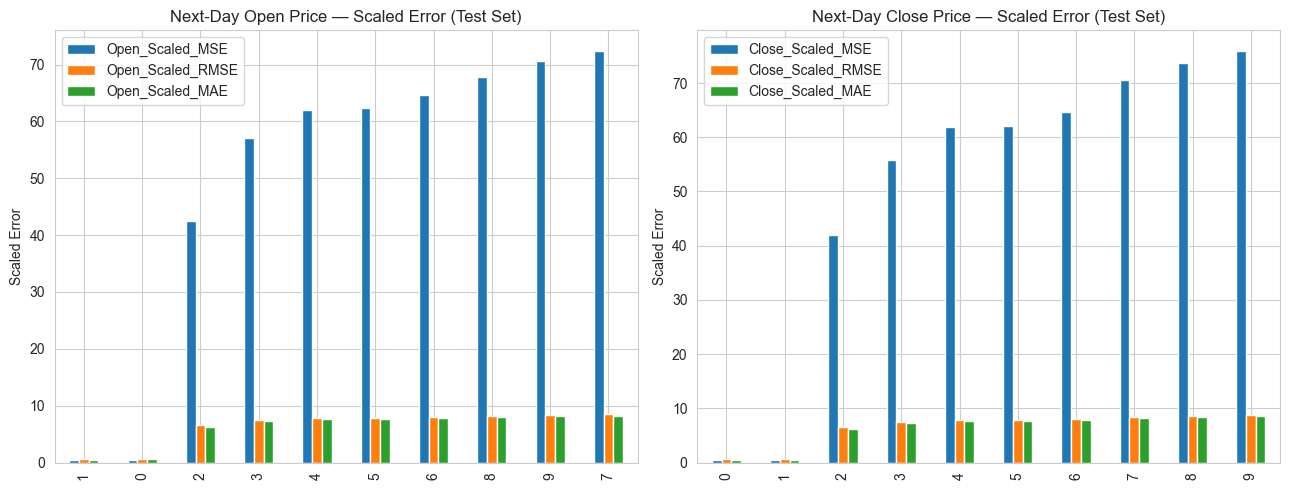

In [27]:
pr_base     = eval_regressor(base_reg,     X_test_seq, y_test_reg_seq, 'LSTM+GRU')
pr_adv1     = eval_regressor(adv1_reg,     X_test_seq, y_test_reg_seq, 'BiLSTM+Attention')
pr_adv2     = eval_regressor(adv2_reg,     X_test_seq, y_test_reg_seq, 'Transformer')
pr_adv2b    = eval_regressor(adv2b_reg,    X_test_seq, y_test_reg_seq, 'Baseline+Transformer')
pr_adv3     = eval_regressor(adv3_reg,     X_test_seq, y_test_reg_seq, 'TCN')
# pr_* for the 4 optimized models are built in the next cell (15.3), from `optimized_results`


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Use the target-specific tables from 15.1 so each panel only reflects its own target:
# the Open panel shows Open-only metrics (and excludes the close-focused tuned model), and
# the Close panel shows Close-only metrics (and excludes the open-focused tuned model).
reg_results_open[['Open_Scaled_MSE', 'Open_Scaled_RMSE', 'Open_Scaled_MAE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Next-Day Open Price — Scaled Error (Test Set)')
axes[0].set_ylabel('Scaled Error')

reg_results_close[['Close_Scaled_MSE', 'Close_Scaled_RMSE', 'Close_Scaled_MAE']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Next-Day Close Price — Scaled Error (Test Set)')
axes[1].set_ylabel('Scaled Error')

for ax in axes:
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### 15.3 Actual vs. Predicted - Next-Day Close


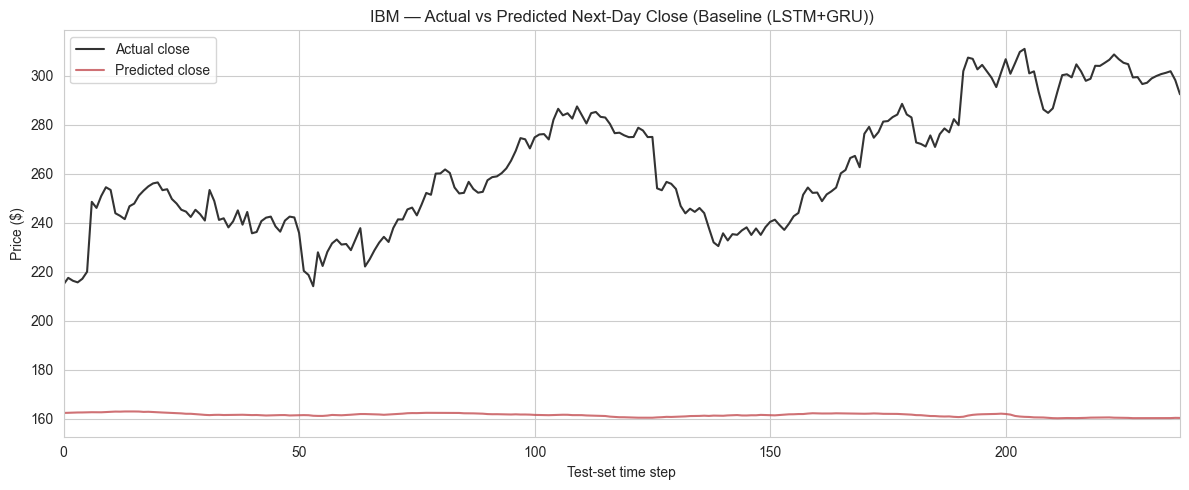

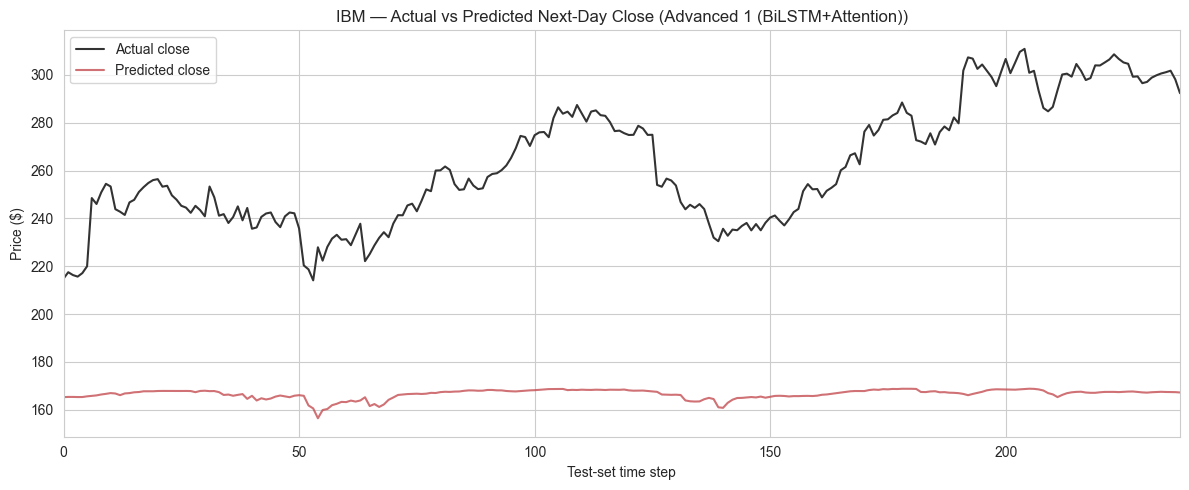

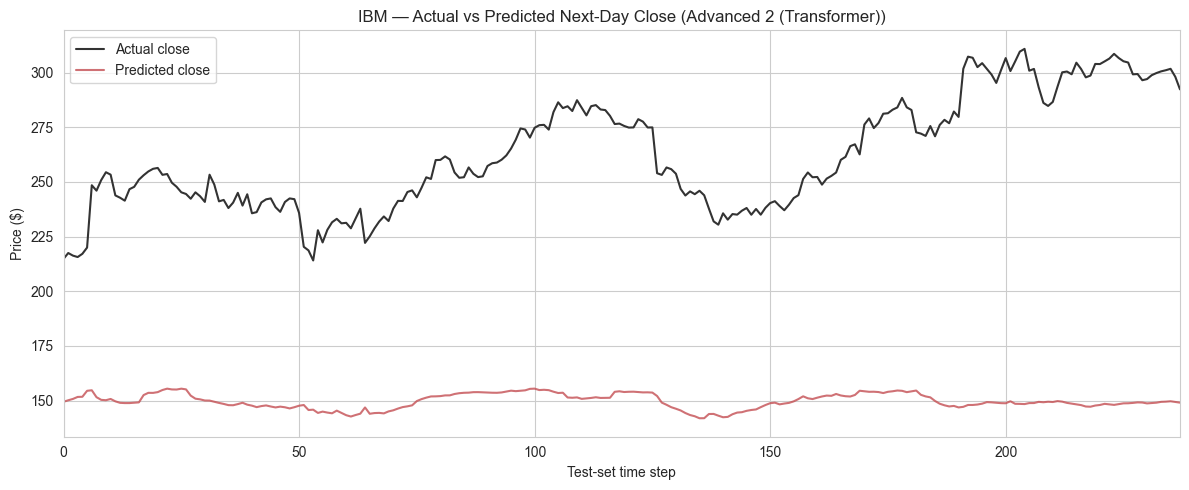

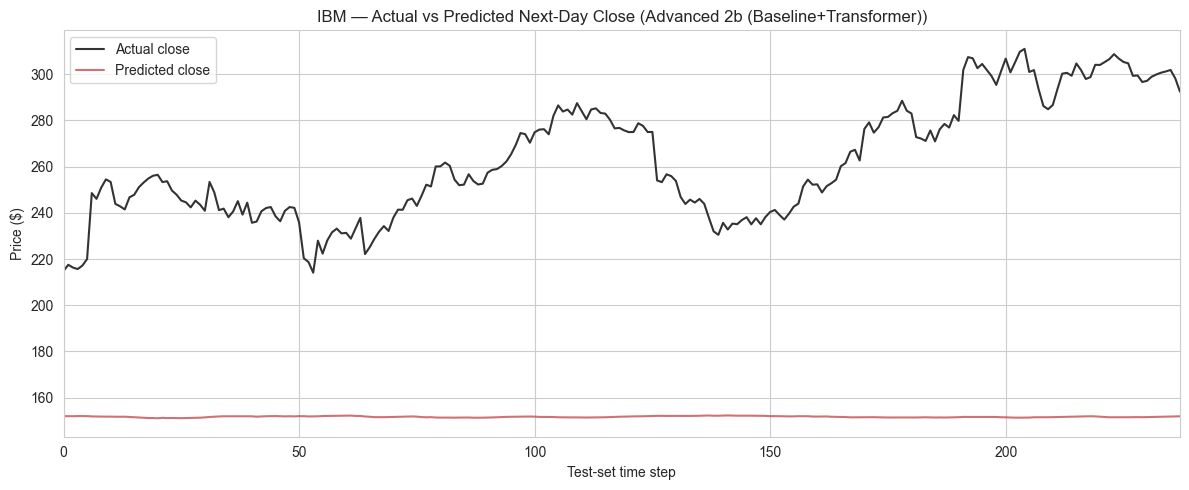

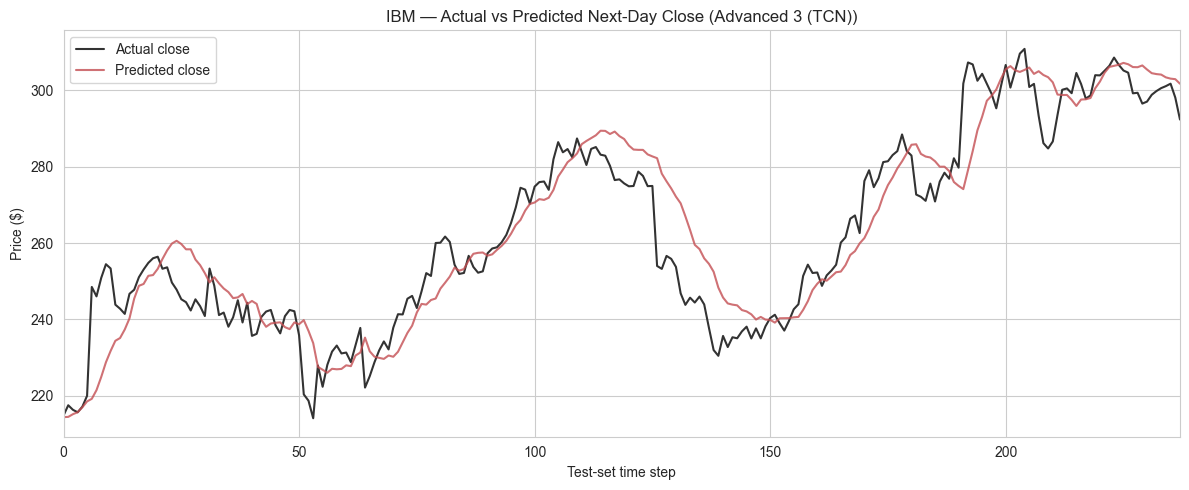

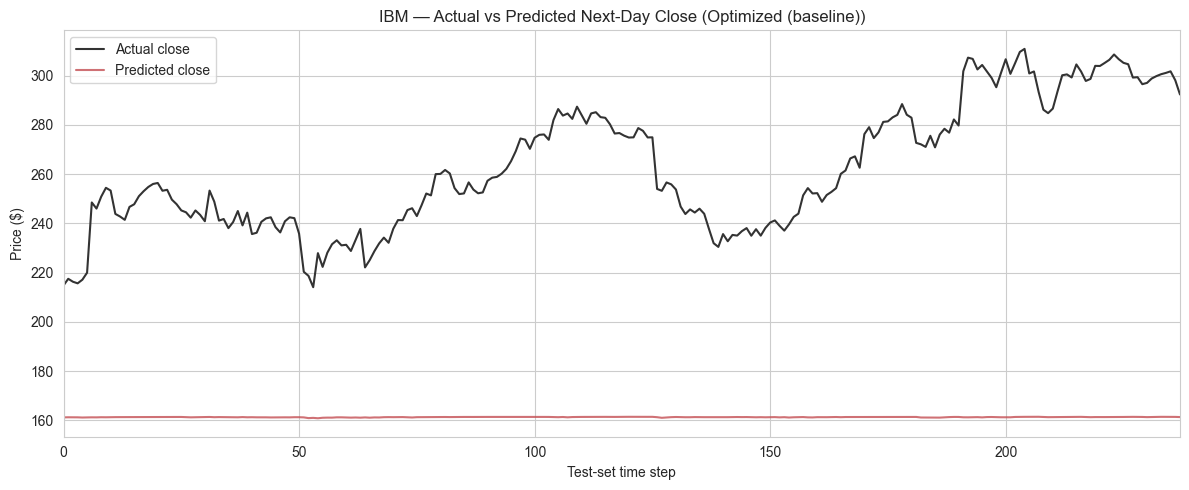

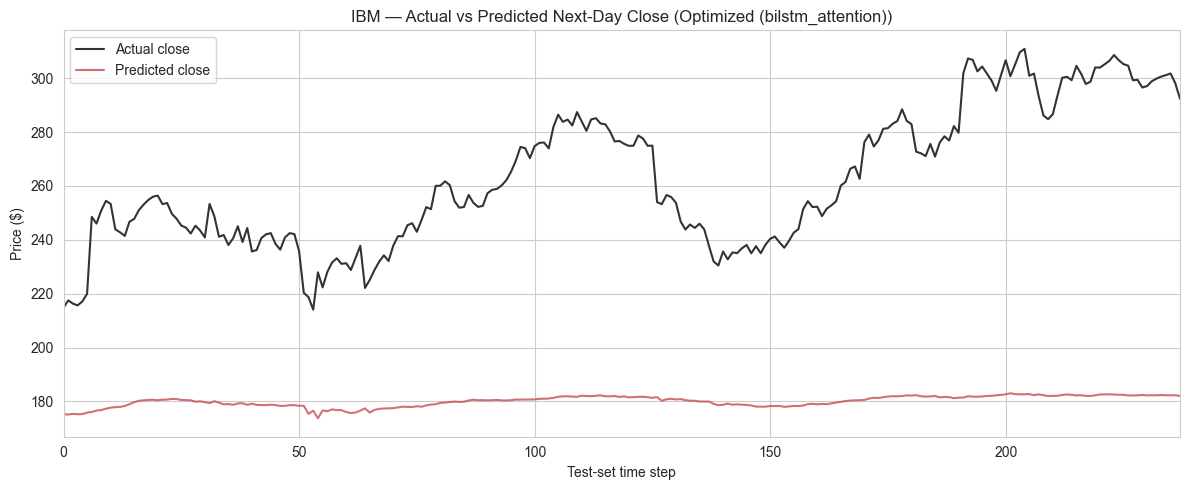

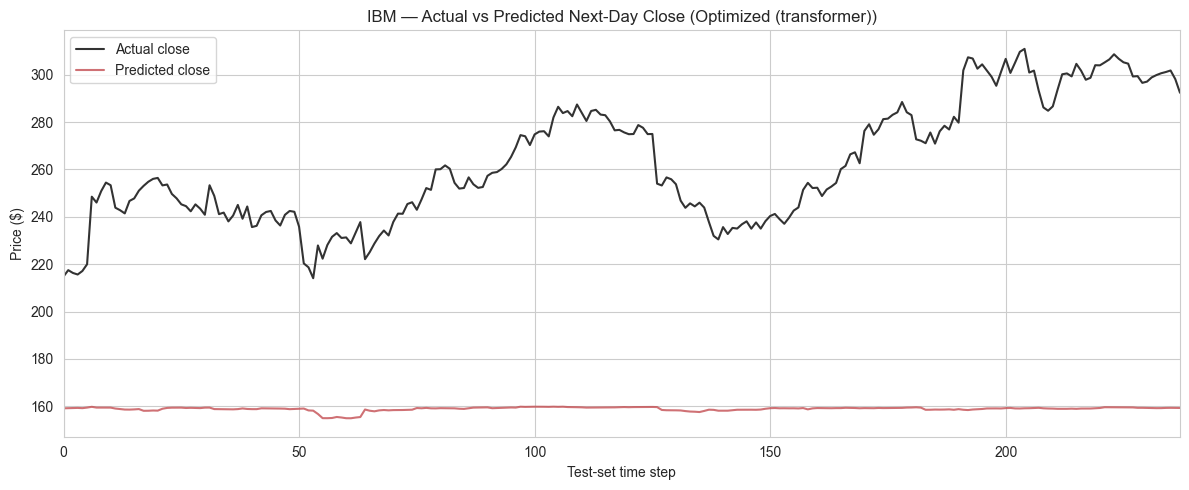

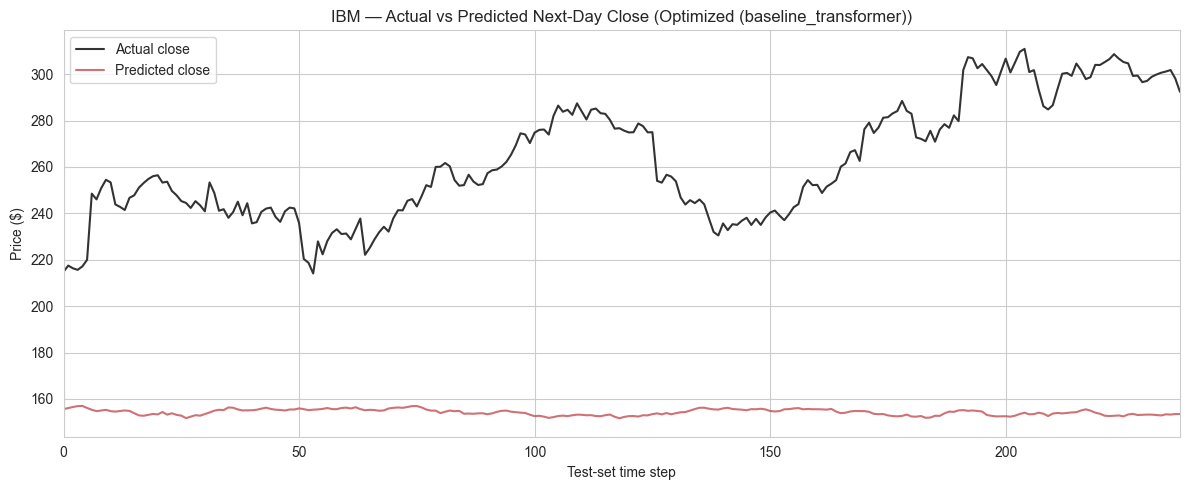

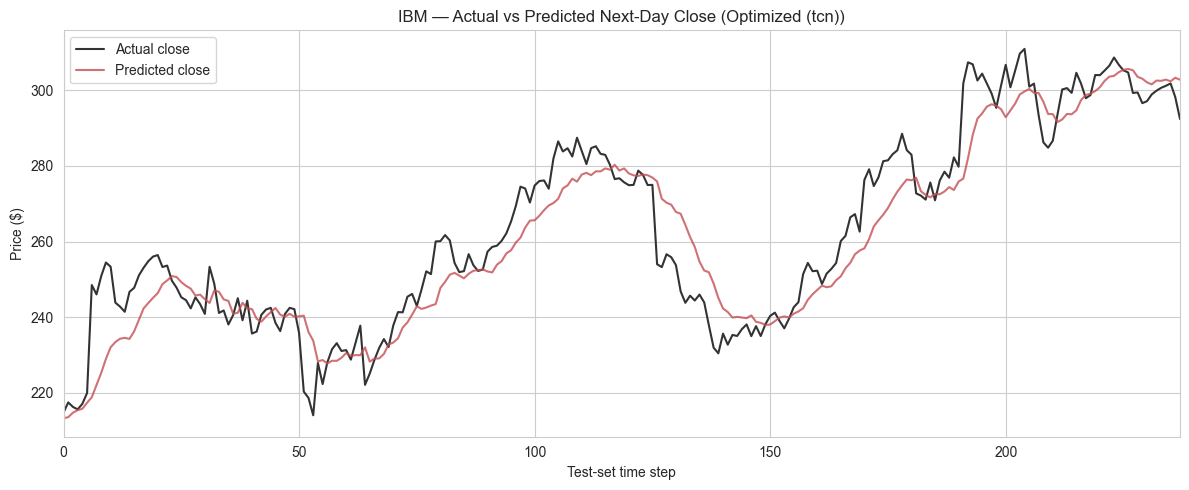

In [ ]:
# Convert a list of per-model result dicts into a comparison table.
pr_optimized = {}
for architecture in ARCHITECTURES_TO_TUNE:
    opt_result_row, opt_model = optimized_results[architecture]
    model_label = opt_result_row['Model']   # e.g. 'Optimized (tcn)'
    pr_optimized[model_label] = eval_regressor(opt_model, X_test_seq, y_test_reg_seq, model_label)

# Build a map of model name -> (result_row, (open_true, open_pred, close_true, close_pred)) so we can
# plot the actual vs predicted close price for every model in one loop below.
pr_map = {
    'Baseline (LSTM+GRU)': pr_base,
    'Advanced 1 (BiLSTM+Attention)': pr_adv1,
    'Advanced 2 (Transformer)': pr_adv2,
    'Advanced 2b (Baseline+Transformer)': pr_adv2b,
    'Advanced 3 (TCN)': pr_adv3,
    **pr_optimized,
}

# Build the tuned/optimized model entries the same way pr_optimized was built above.
opt_reg_models = {}
for architecture in ARCHITECTURES_TO_TUNE:
    opt_result_row, opt_model = optimized_results[architecture]
    model_label = opt_result_row['Model']
    opt_reg_models[model_label] = (opt_model, opt_result_row)

reg_models = {
    'Baseline (LSTM+GRU)':          (base_reg, base_reg_result),
    'Advanced 1 (BiLSTM+Attention)': (adv1_reg, adv1_reg_result),
    'Advanced 2 (Transformer)':      (adv2_reg, adv2_reg_result),
    'Advanced 2b (Baseline+Transformer)': (adv2b_reg, adv2b_reg_result),
    'Advanced 3 (TCN)':              (adv3_reg, adv3_reg_result),
    **opt_reg_models,
}

for model_name, (model, mean_row) in reg_models.items():
    _, (_, _, close_true, close_pred) = pr_map[model_name]
    plt.figure(figsize=(12, 5))
    plt.plot(close_true, label='Actual close', color='#333333')
    plt.plot(close_pred, label='Predicted close', color='#c44e52', alpha=0.8)
    plt.title(f'{TICKER} — Actual vs Predicted Next-Day Close ({model_name})')
    plt.xlabel('Test-set time step')
    plt.ylabel('Price ($)')

    # Remove the default x-margin so the line starts right at the y-axis (x=0),
    # instead of floating with a gap before the first data point.
    plt.xlim(0, len(close_true) - 1)
    plt.margins(x=0)

    plt.legend()
    plt.tight_layout()
    plt.show()

### 15.4 Actual vs. Predicted — Next-Day Open


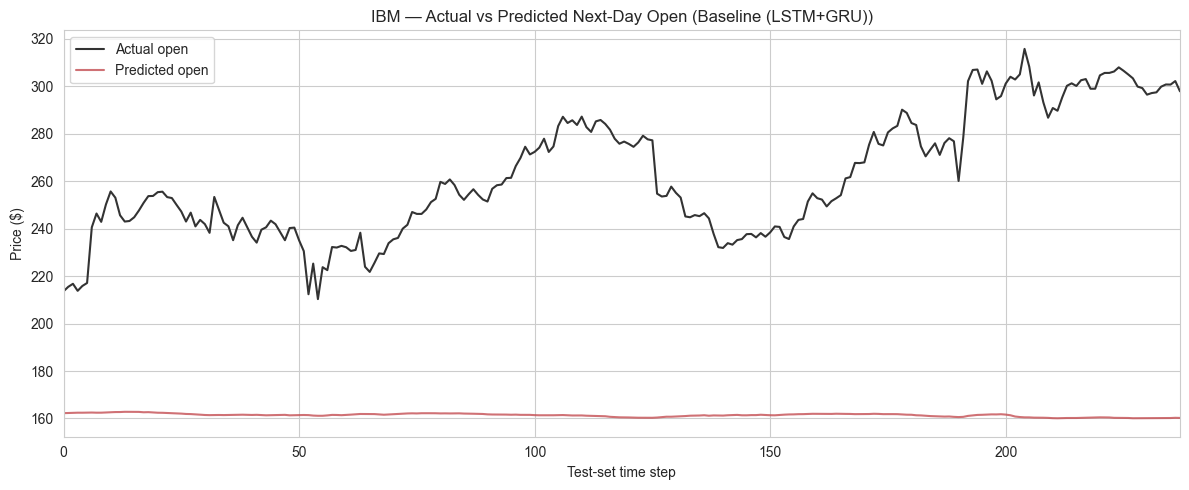

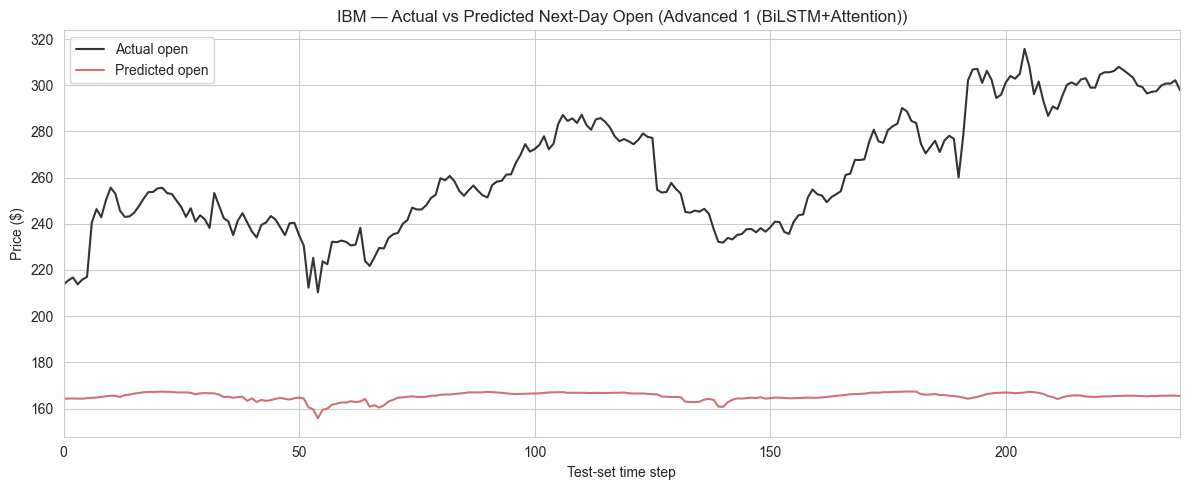

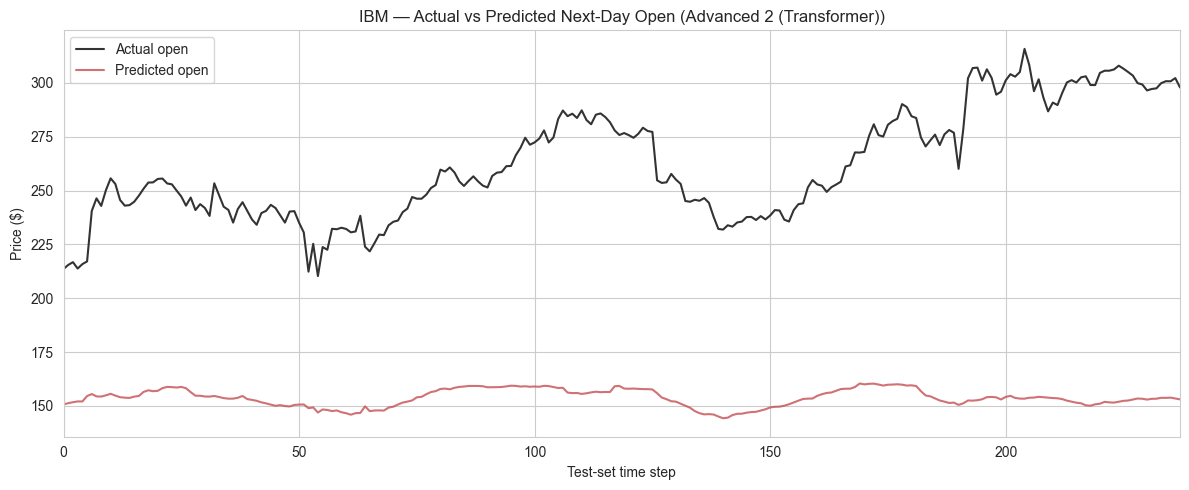

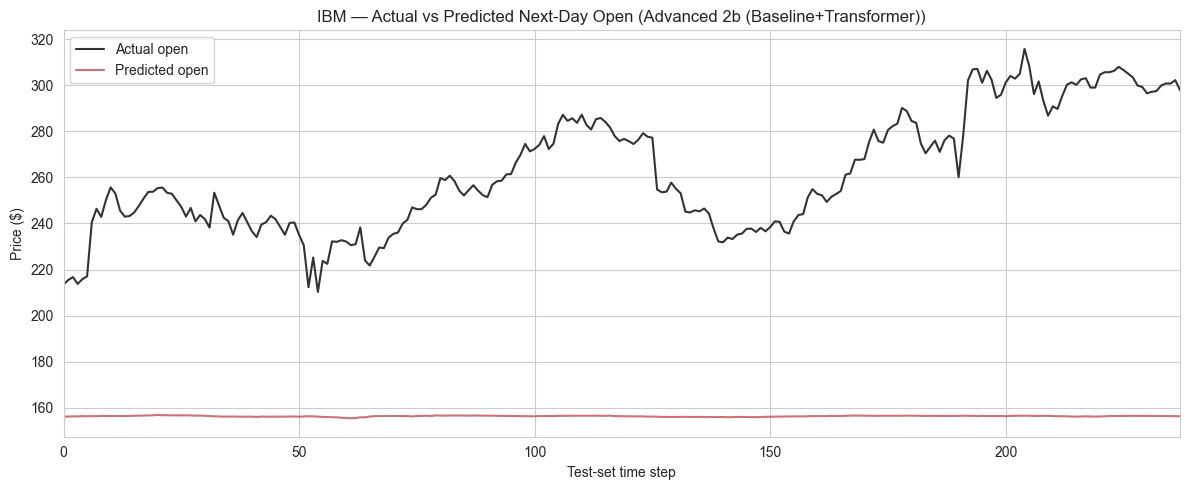

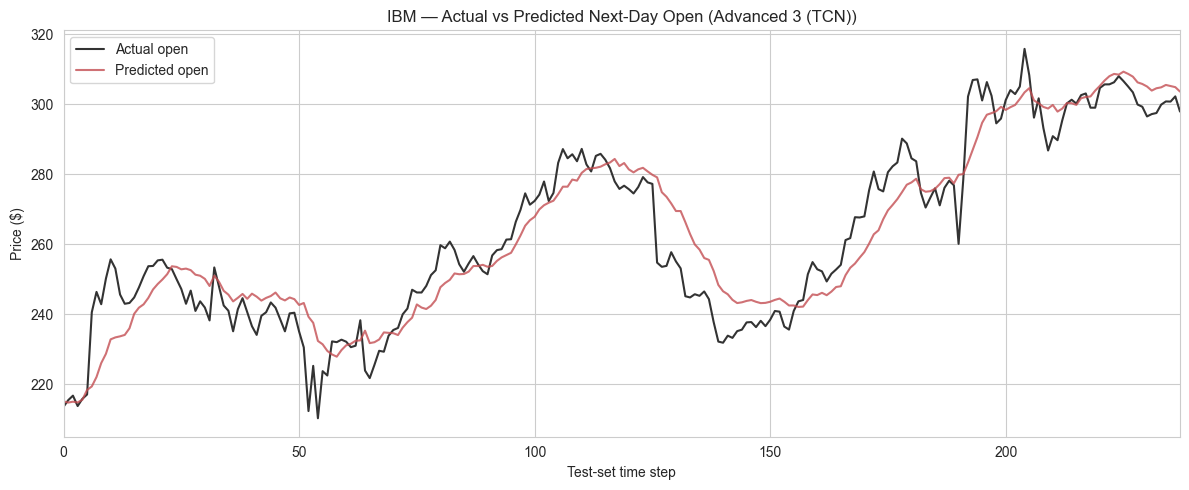

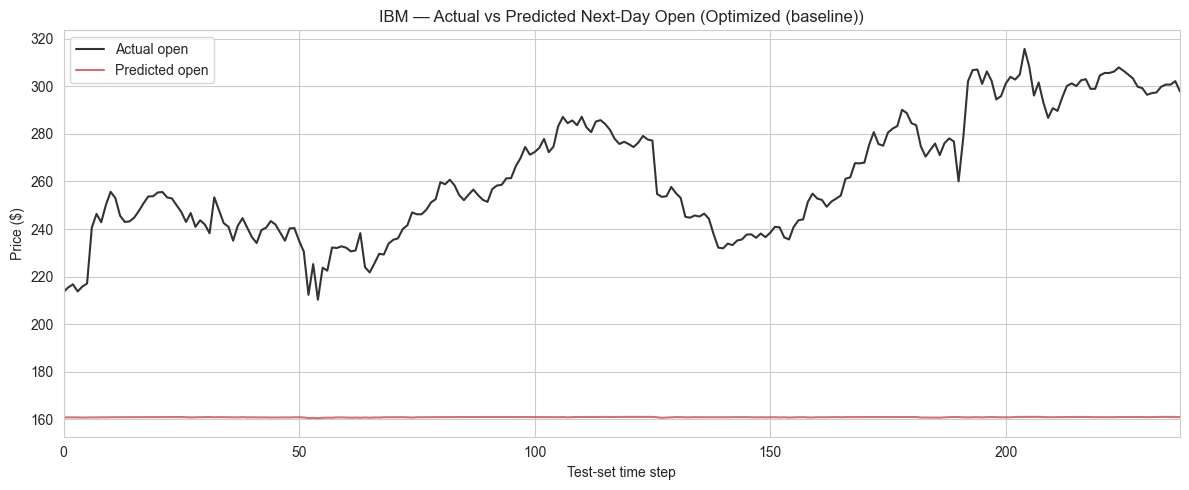

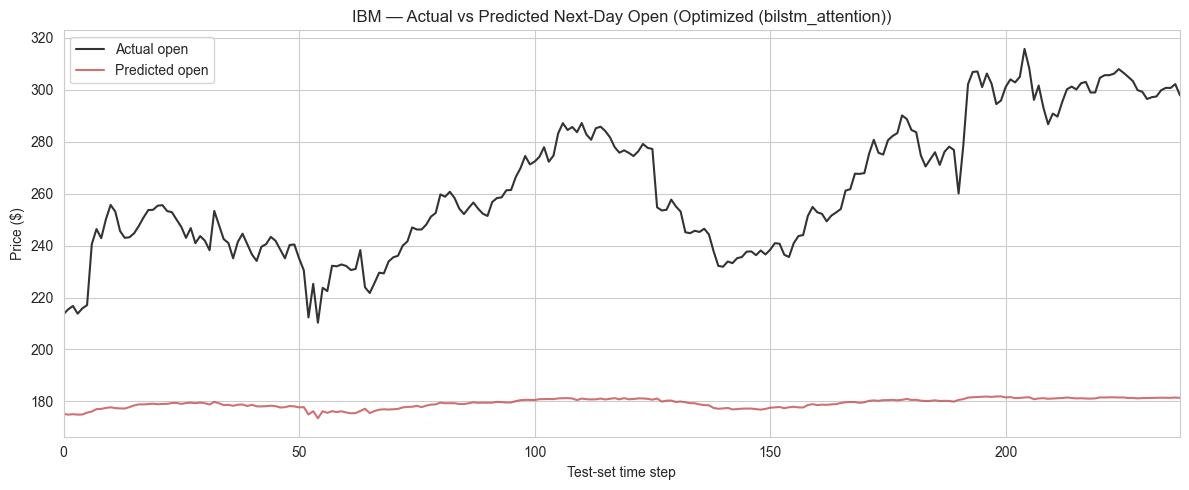

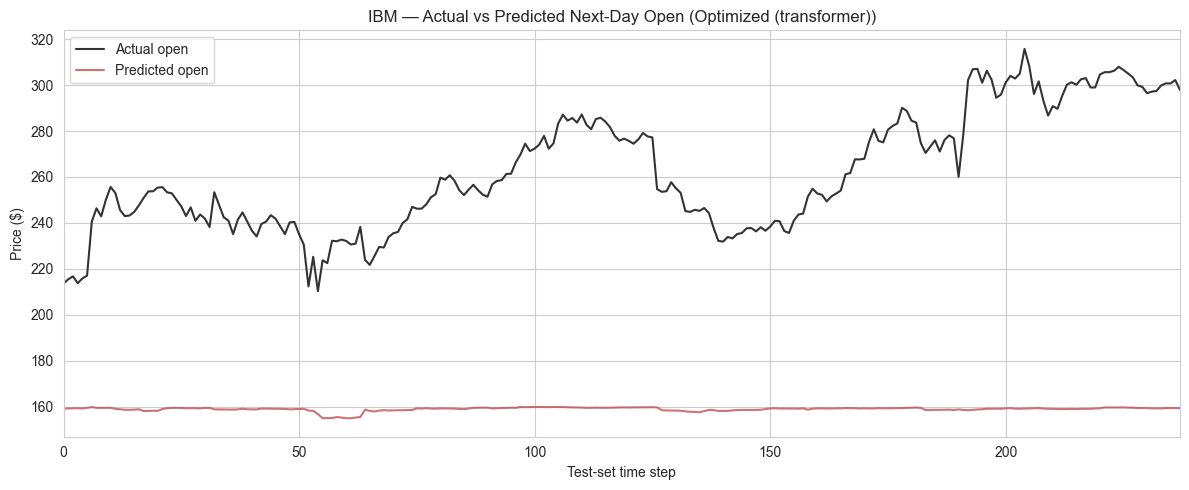

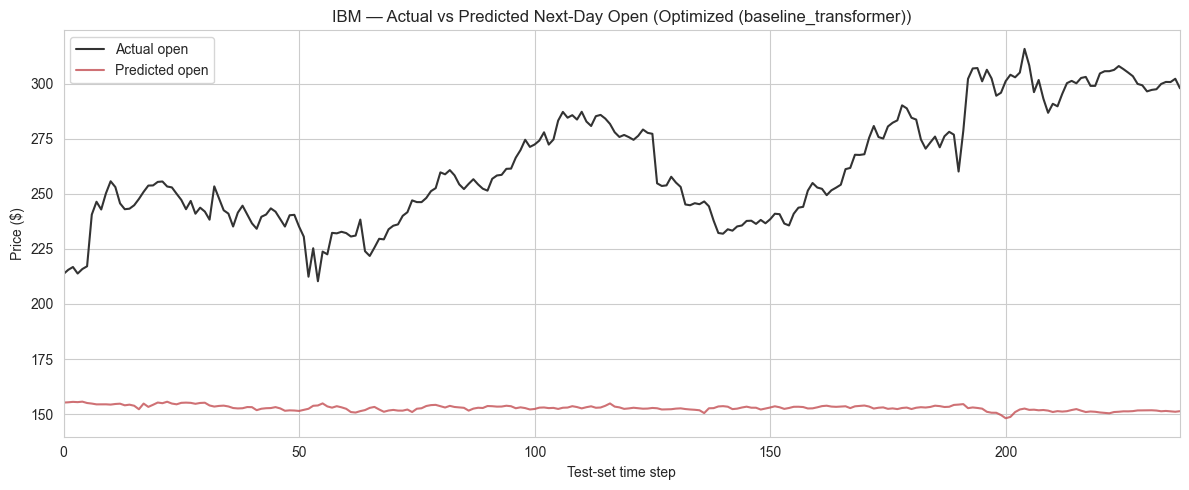

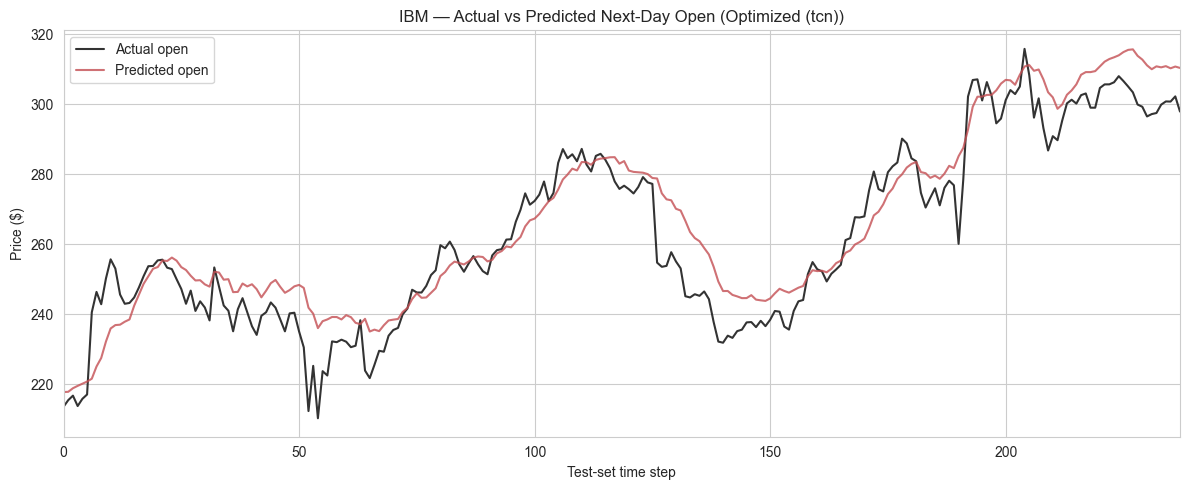

In [29]:
for model_name, (model, mean_row) in reg_models.items():
    _, (open_true, open_pred, _, _) = pr_map[model_name]
    plt.figure(figsize=(12, 5))
    plt.plot(open_true, label='Actual open', color='#333333')
    plt.plot(open_pred, label='Predicted open', color='#c44e52', alpha=0.8)
    plt.title(f'{TICKER} — Actual vs Predicted Next-Day Open ({model_name})')
    plt.xlabel('Test-set time step')
    plt.ylabel('Price ($)')

    # Remove the default x-margin so the line starts right at the y-axis (x=0),
    # instead of floating with a gap before the first data point.
    plt.xlim(0, len(open_true) - 1)
    plt.margins(x=0)

    plt.legend()
    plt.tight_layout()
    plt.show()


### 15.5 Training vs. Validation Loss Curves

Per-epoch training and validation loss (scaled MSE) for each of the six models, taken from each
model's first of its ten independent training runs (Section 10's `evaluate_with_paper_protocol`). The test set is intentionally
not shown here: it is evaluated only after training finishes (Sections 15.1-15.4), so it never
influences training or early stopping. A widening gap between the two curves signals overfitting;
a validation curve that plateaus before training ends shows where early stopping intervened.


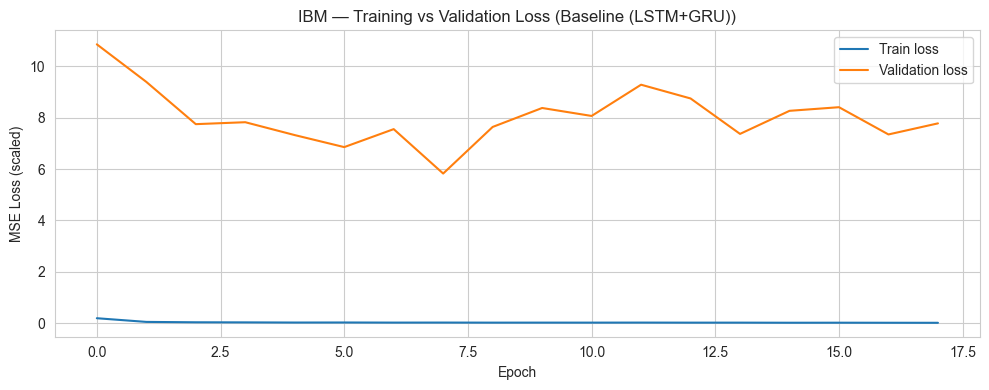

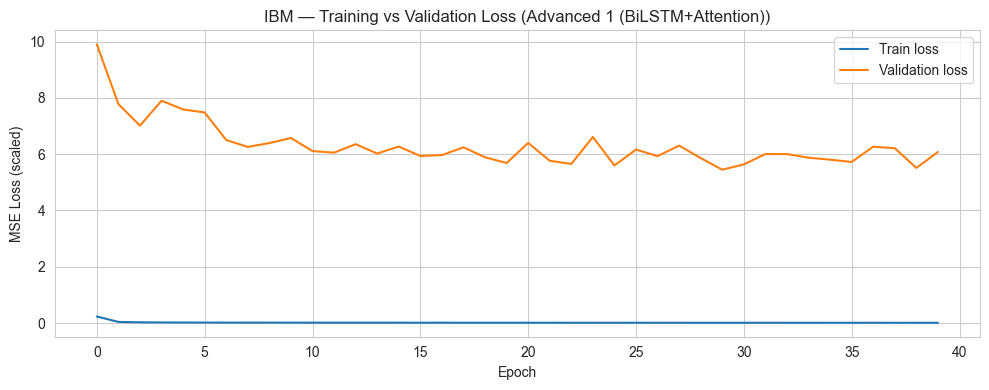

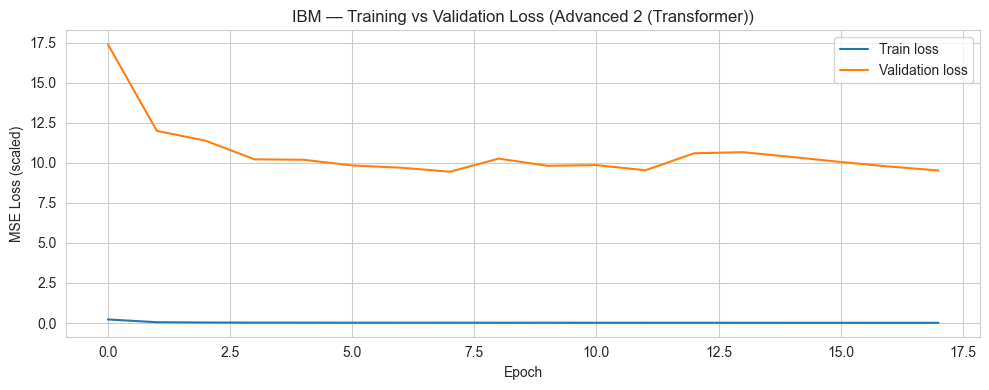

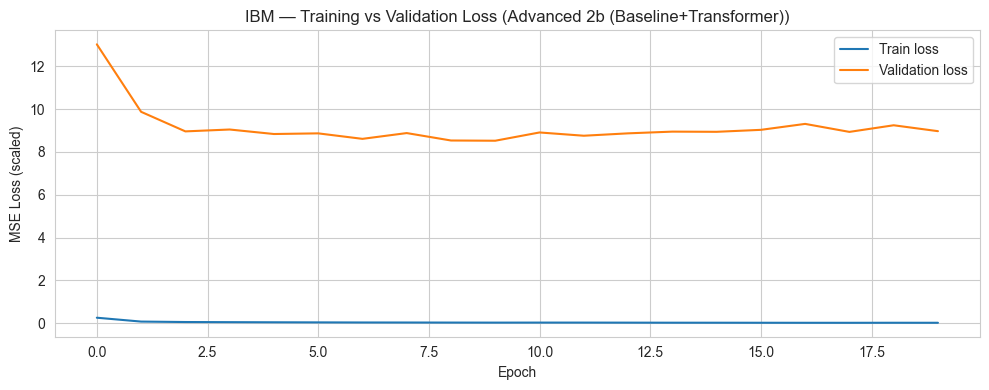

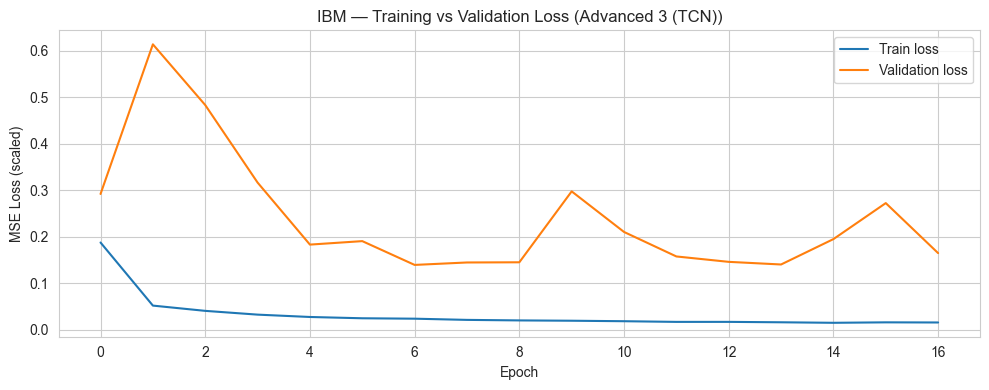

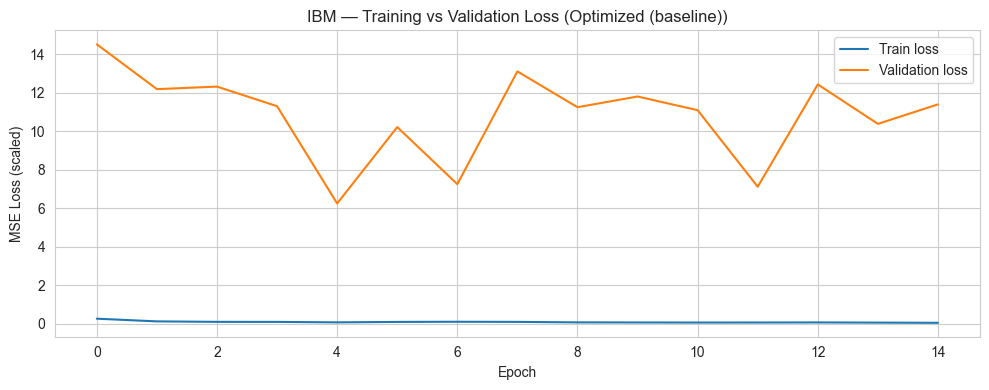

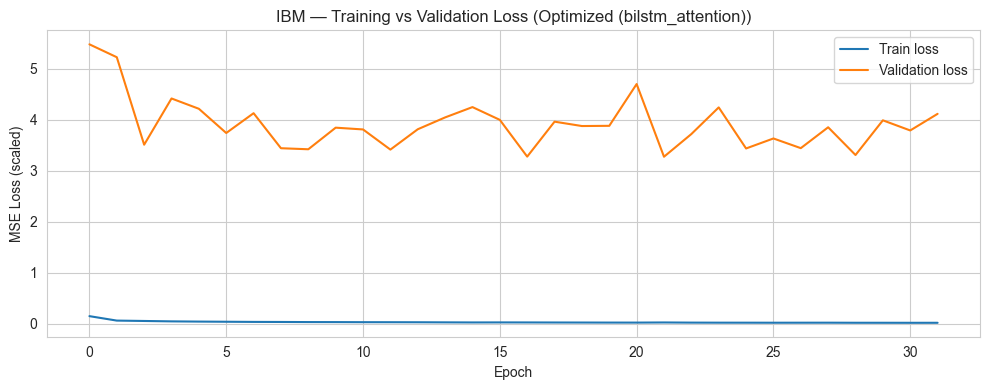

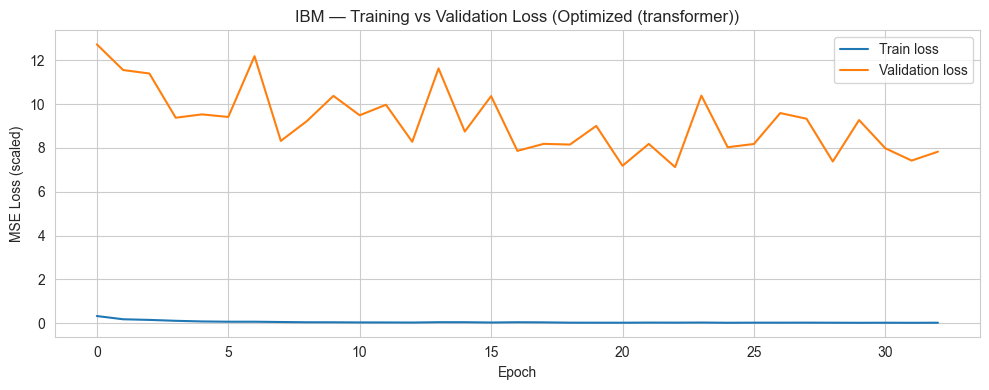

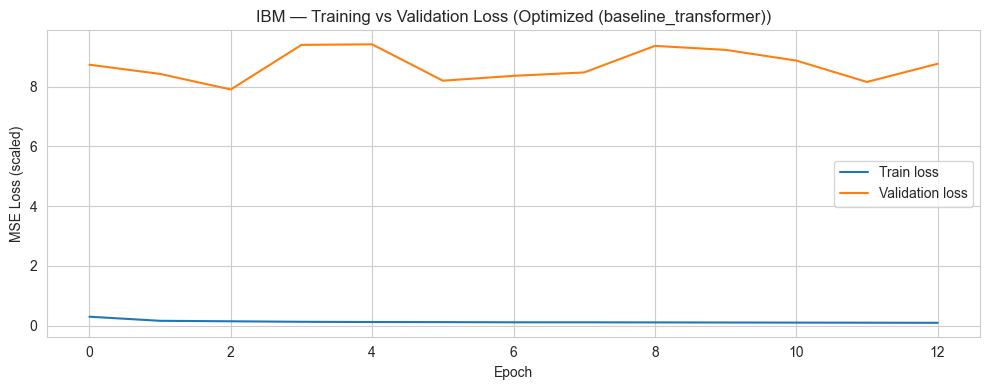

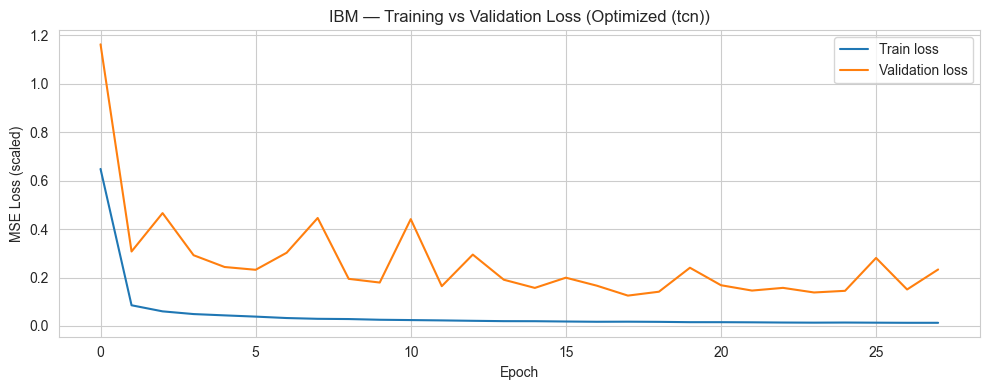

In [30]:
for model_name in reg_models:
    hist = TRAINING_HISTORIES[model_name]
    plt.figure(figsize=(10, 4))
    plt.plot(hist['loss'], label='Train loss')
    plt.plot(hist['val_loss'], label='Validation loss')
    plt.title(f'{TICKER} \u2014 Training vs Validation Loss ({model_name})')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (scaled)')
    plt.legend()
    plt.tight_layout()
    plt.show()


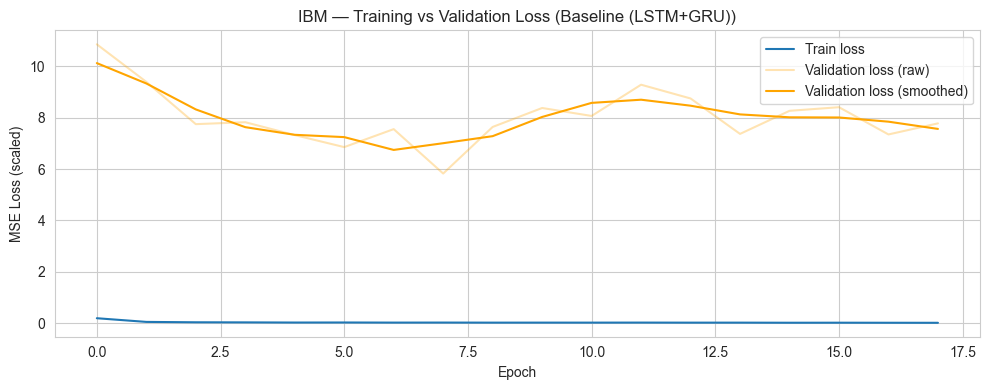

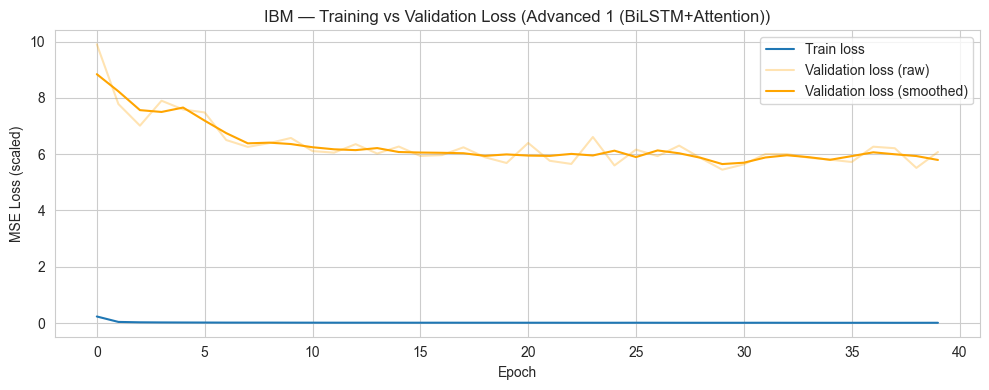

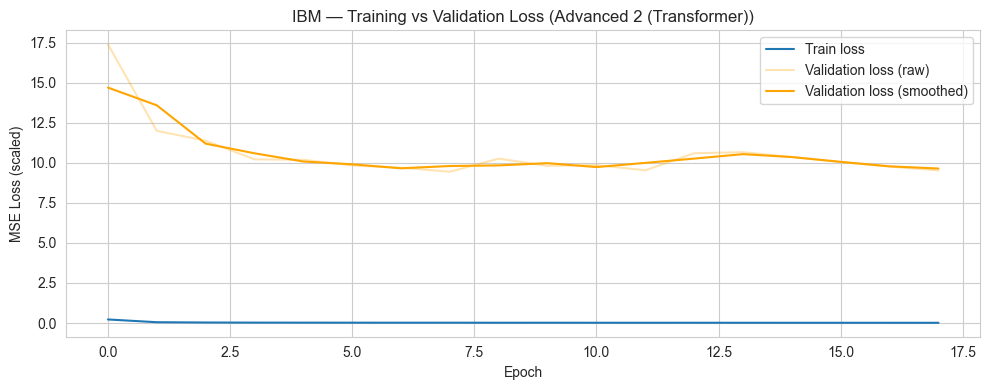

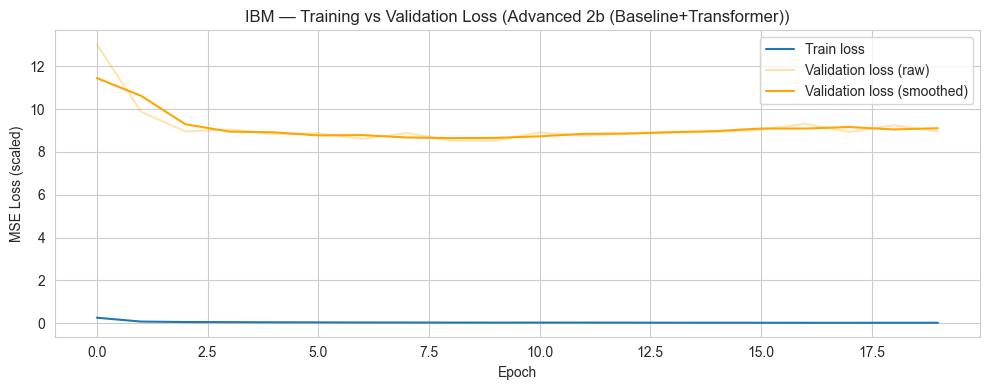

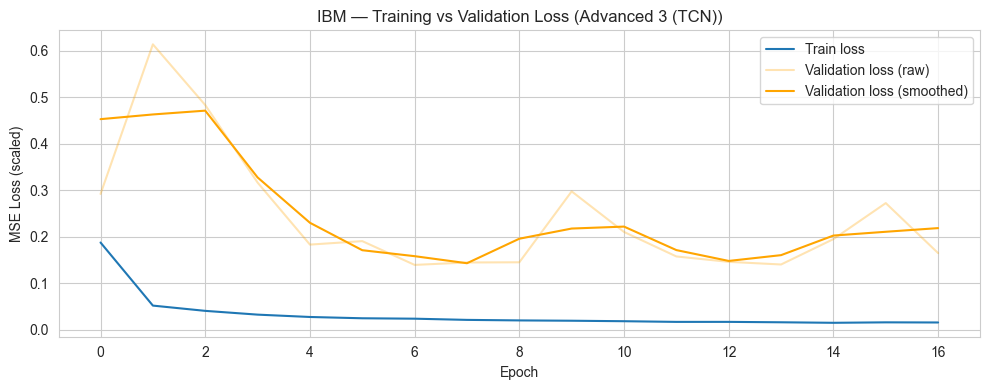

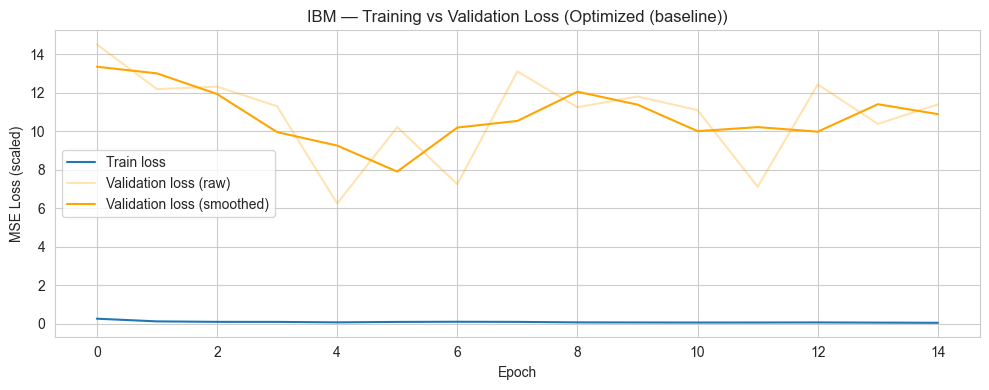

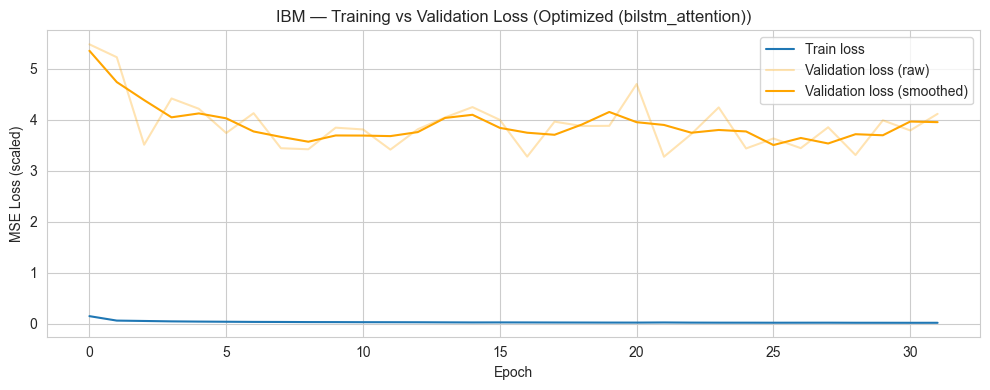

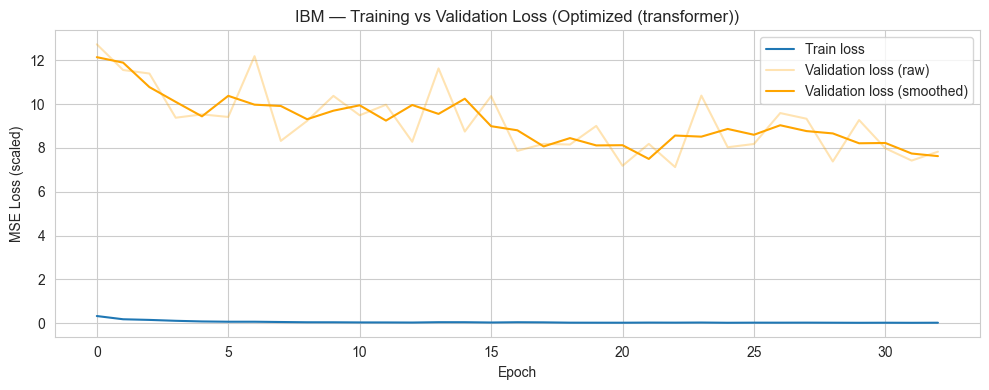

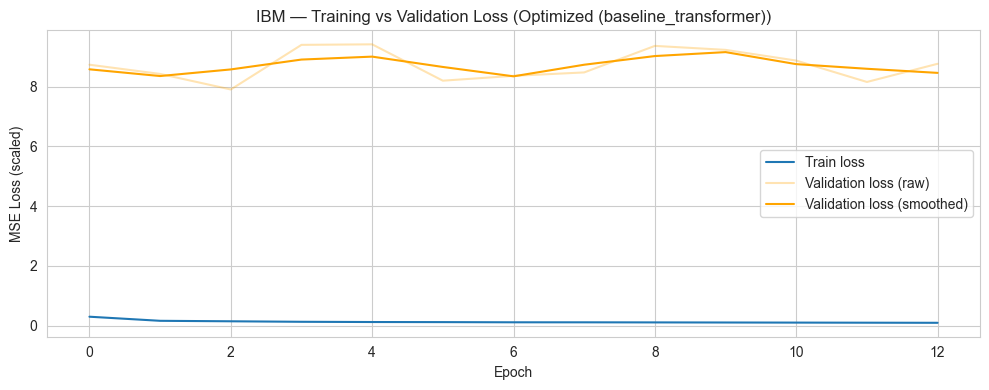

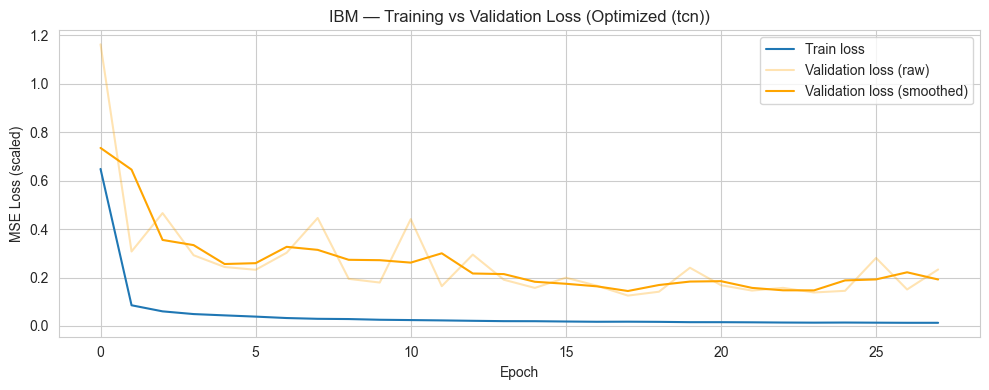

In [ ]:
# Plot the training and validation loss curves for every model, but smooth the validation loss
# curve with a rolling mean so the trends are easier to see (the raw validation loss is
# often very noisy, especially for the smaller models).
def smooth(values, window=3):
    return pd.Series(values).rolling(window, min_periods=1, center=True).mean()

for model_name in reg_models:
    hist = TRAINING_HISTORIES[model_name]
    plt.figure(figsize=(10, 4))
    plt.plot(hist['loss'], label='Train loss')
    plt.plot(hist['val_loss'], color='orange', alpha=0.3, label='Validation loss (raw)')
    plt.plot(smooth(hist['val_loss']), color='orange', label='Validation loss (smoothed)')
    plt.title(f'{TICKER} — Training vs Validation Loss ({model_name})')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss (scaled)')
    plt.legend(); plt.tight_layout(); plt.show()

### 15.6 Statistical Significance Testing (Paired t-test, Wilcoxon, 95% CI)

The comparison tables in 15.1 report point estimates from a single run per model. Section 9's `evaluate_with_paper_protocol`, however, already retrains every model (baseline, all three advanced architectures, and all four tuned/optimized variants) **10 independent times per target** with matched random seeds (`SEED + run`, run = 0..9) -- the *same* seed is used for run *r* across every architecture. That makes the 10 test-set RMSE values collected for any two models a **paired** sample: run 3's baseline model and run 3's TCN model saw the same weight initialization and the same batch ordering, so a paired test isolates the effect of the architecture itself from ordinary run-to-run training noise -- something the mean +/- std in Section 13 cannot do on its own.

For each model we report:
- a **95% confidence interval** on its mean test RMSE (Student's t based on the 10 runs), and
- versus the **baseline (LSTM+GRU)**: the paired **t-test** (`scipy.stats.ttest_rel`) p-value, and the non-parametric **Wilcoxon signed-rank test** p-value as a robustness check that doesn't assume the run-to-run differences are normally distributed.

A model is flagged significant at the conventional alpha = 0.05 threshold if the paired t-test p-value is below it. This is done separately for the Open target and the Close target, since they are different prediction problems and a model can be significantly better on one without being significantly better on the other.


In [32]:
from scipy import stats

BASELINE_NAME = 'Baseline (LSTM+GRU)'

def significance_vs_baseline(metric_key, target_key, baseline_name=BASELINE_NAME, alpha=0.05):
    """Paired significance test of every model's 10-run test metric against the baseline's,
    plus a 95% CI on each model's own mean. `metric_key` is e.g. 'Open_Scaled_RMSE' and
    `target_key` is 'open_test' or 'close_test' (must match), pulled from RAW_RUN_METRICS.
    """
    baseline_vals = RAW_RUN_METRICS[baseline_name][target_key][metric_key].to_numpy()
    rows = []
    for model_name, runs in RAW_RUN_METRICS.items():
        vals = runs[target_key][metric_key].to_numpy()
        n = len(vals)
        mean_val = vals.mean()

        # 95% CI on this model's own mean (t-distribution, n-1 degrees of freedom)
        sem = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        if sem > 0:
            ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean_val, scale=sem)
        else:
            ci_low, ci_high = mean_val, mean_val

        if model_name == baseline_name:
            t_stat, t_p, w_p = np.nan, np.nan, np.nan
        else:
            t_stat, t_p = stats.ttest_rel(vals, baseline_vals)
            diffs = vals - baseline_vals
            if np.allclose(diffs, 0):
                w_p = np.nan  # Wilcoxon is undefined when every paired difference is exactly 0
            else:
                try:
                    _, w_p = stats.wilcoxon(vals, baseline_vals)
                except ValueError:
                    w_p = np.nan  # e.g. all-tied ranks with small n

        rows.append({
            'Model': model_name,
            'Mean': mean_val,
            '95% CI low': ci_low,
            '95% CI high': ci_high,
            'Diff vs. baseline': mean_val - baseline_vals.mean(),
            'Paired t p-value': t_p,
            'Wilcoxon p-value': w_p,
            f'Significant (p<{alpha})': (t_p < alpha) if not np.isnan(t_p) else False,
        })
    out = pd.DataFrame(rows).set_index('Model').sort_values('Mean')
    return out

sig_open  = significance_vs_baseline('Open_Scaled_RMSE',  'open_test')
sig_close = significance_vs_baseline('Close_Scaled_RMSE', 'close_test')

print('--- OPEN target: 95% CI on mean test RMSE (10 runs) + paired significance vs. baseline ---')
display(sig_open.style.format({
    'Mean': '{:.4f}', '95% CI low': '{:.4f}', '95% CI high': '{:.4f}',
    'Diff vs. baseline': '{:+.4f}', 'Paired t p-value': '{:.4f}', 'Wilcoxon p-value': '{:.4f}',
}))

print('\n--- CLOSE target: 95% CI on mean test RMSE (10 runs) + paired significance vs. baseline ---')
display(sig_close.style.format({
    'Mean': '{:.4f}', '95% CI low': '{:.4f}', '95% CI high': '{:.4f}',
    'Diff vs. baseline': '{:+.4f}', 'Paired t p-value': '{:.4f}', 'Wilcoxon p-value': '{:.4f}',
}))


--- OPEN target: 95% CI on mean test RMSE (10 runs) + paired significance vs. baseline ---


,Mean,95% CI low,95% CI high,Diff vs. baseline,Paired t p-value,Wilcoxon p-value,Significant (p<0.05)
Model,,,,,,,
Optimized (tcn),0.5682,0.5155,0.6209,-7.3860,0.0000,0.0020,True
Advanced 3 (TCN),0.6160,0.5425,0.6895,-7.3381,0.0000,0.0020,True
Optimized (bilstm_attention),6.7026,6.5372,6.8679,-1.2516,0.0000,0.0020,True
Advanced 1 (BiLSTM+Attention),7.5825,7.4535,7.7115,-0.3716,0.0001,0.0020,True
Baseline (LSTM+GRU),7.9542,7.8597,8.0487,+0.0000,nan,nan,False
Optimized (baseline),8.1178,7.8983,8.3372,+0.1636,0.1463,0.1309,False
Optimized (transformer),8.1623,8.0631,8.2614,+0.2081,0.0012,0.0039,True
Optimized (baseline_transformer),8.2874,8.1108,8.4640,+0.3332,0.0032,0.0039,True
Advanced 2 (Transformer),8.3988,8.2692,8.5285,+0.4447,0.0001,0.0020,True



--- CLOSE target: 95% CI on mean test RMSE (10 runs) + paired significance vs. baseline ---


,Mean,95% CI low,95% CI high,Diff vs. baseline,Paired t p-value,Wilcoxon p-value,Significant (p<0.05)
Model,,,,,,,
Optimized (tcn),0.6372,0.6042,0.6701,-7.2973,0.0000,0.0020,True
Advanced 3 (TCN),0.6786,0.6501,0.7071,-7.2558,0.0000,0.0020,True
Optimized (bilstm_attention),6.5871,6.4929,6.6812,-1.3474,0.0000,0.0020,True
Advanced 1 (BiLSTM+Attention),7.5015,7.4047,7.5984,-0.4329,0.0000,0.0020,True
Baseline (LSTM+GRU),7.9345,7.8432,8.0257,+0.0000,nan,nan,False
Optimized (transformer),8.0954,7.9996,8.1911,+0.1609,0.0082,0.0098,True
Optimized (baseline),8.0995,7.8667,8.3323,+0.1650,0.1570,0.1055,False
Optimized (baseline_transformer),8.2173,8.0393,8.3952,+0.2828,0.0033,0.0098,True
Advanced 2 (Transformer),8.3433,8.1560,8.5307,+0.4089,0.0016,0.0098,True


**Reading these tables:** a model whose `95% CI` on the Open (or Close) side does not overlap the baseline's CI, *and* whose paired t-test p-value is below 0.05, is one we can say beats the baseline by more than chance/run-to-run noise on this ticker's test window -- not just a better single-run number. Models that look better in the single-run tables of 15.1 but are **not** flagged significant here should be treated cautiously: on a held-out test window of this size, a p-value above 0.05 means we cannot rule out that the apparent gap is run-to-run noise rather than a genuine architectural advantage. This same function can be re-run with `metric_key='Open_Scaled_MAE'` / `'Close_Scaled_MAE'` etc. to check significance on other metrics beyond RMSE.


## 16. Model Interpretability and Explainability


### 16.1 Average Attention Weight (BiLSTM + Attention Regressor)


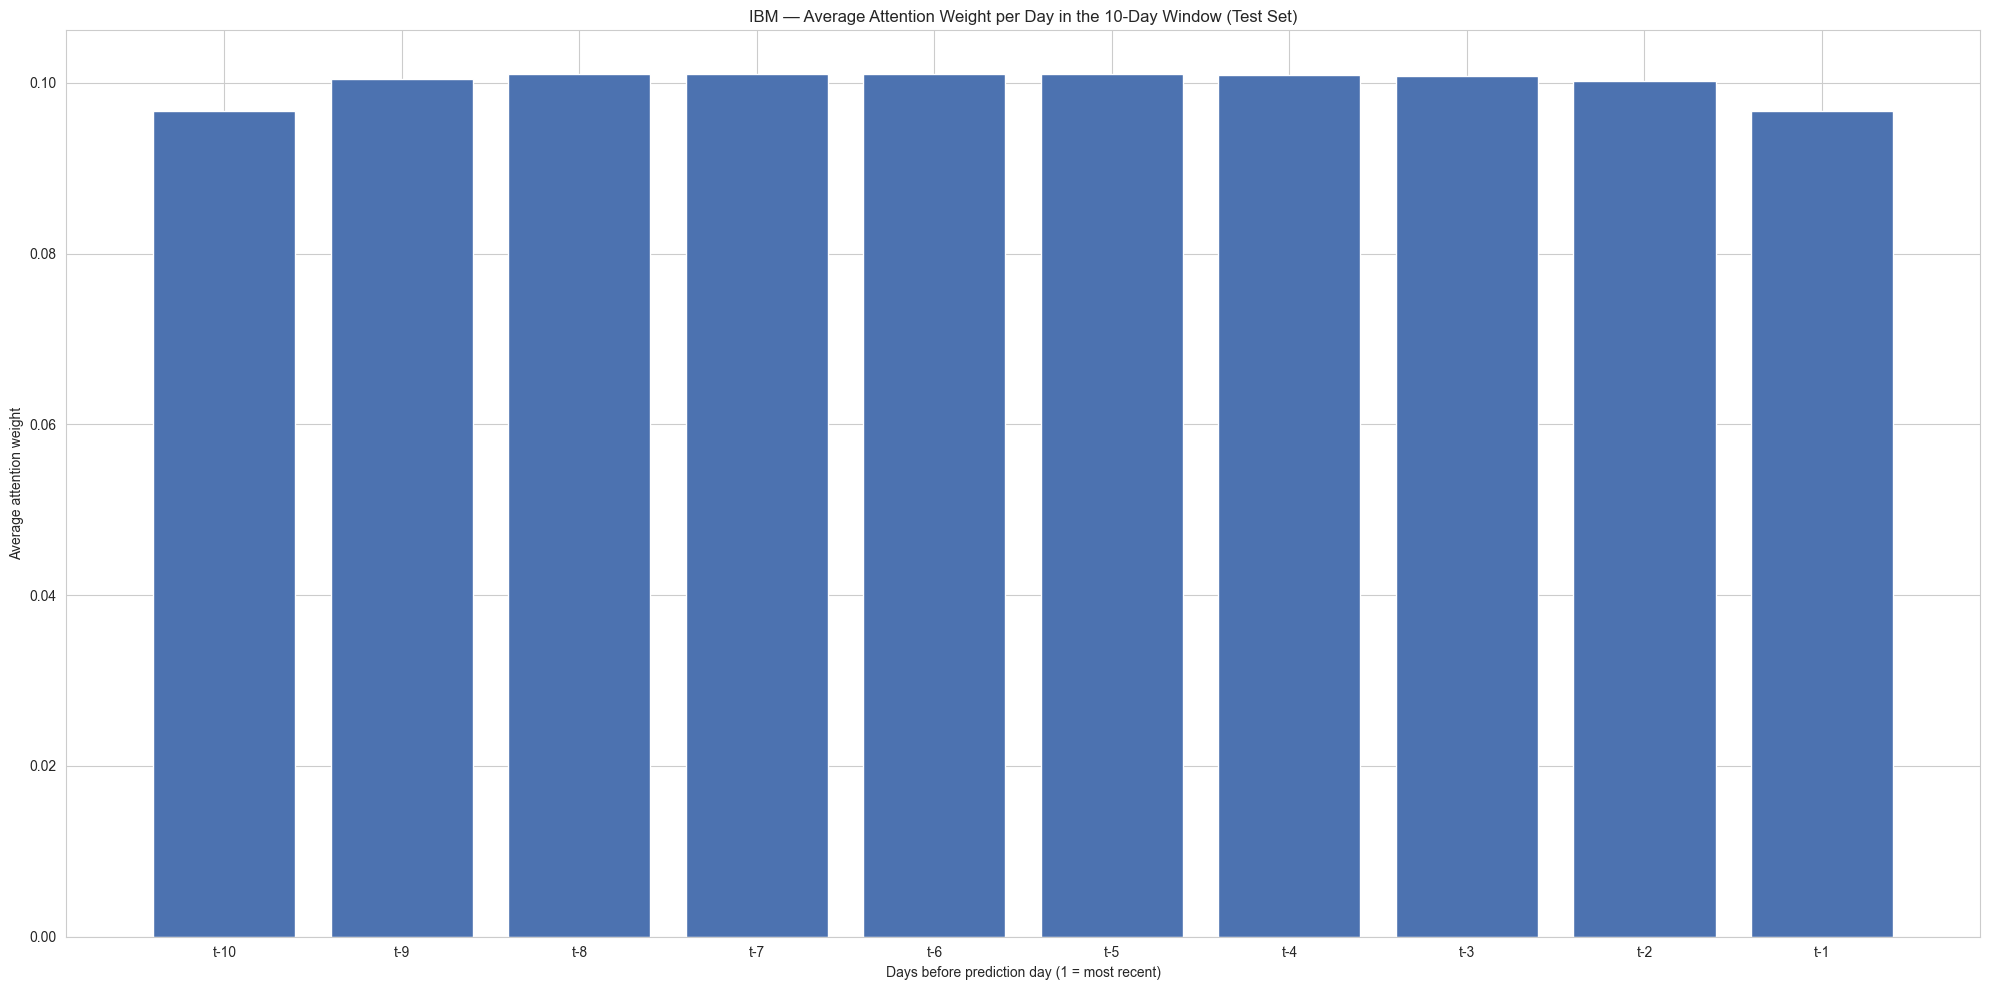

A sharply peaked profile near t-1 suggests the model behaves mostly like a short-term
momentum detector, while a flatter profile suggests it draws on the whole window.


In [ ]:
# Plot the average attention weights across the 10-run test set for the BiLSTM+Attention model.
att_extractor = models.Model(inputs=adv1_reg.input, outputs=adv1_reg.get_layer('attention').output)
_, attn_weights = att_extractor.predict(X_test_seq[:200], verbose=0)   # (samples, timesteps, 1)

avg_attention = attn_weights.mean(axis=0).ravel()
plt.figure(figsize=(20, 10))
plt.bar(range(1, WINDOW + 1), avg_attention, color='#4c72b0')
plt.title(f'{TICKER} — Average Attention Weight per Day in the {WINDOW}-Day Window (Test Set)')
plt.xlabel('Days before prediction day (1 = most recent)')
plt.ylabel('Average attention weight')
plt.xticks(range(1, WINDOW + 1), [f't-{WINDOW - i}' for i in range(WINDOW)])
plt.tight_layout()
plt.show()

print('A sharply peaked profile near t-1 suggests the model behaves mostly like a short-term')
print('momentum detector, while a flatter profile suggests it draws on the whole window.')


### 16.2 SHAP Feature Importance

Global and per-feature SHAP attributions for the next-day close-price XGBoost regressor, computed on the same top-K feature set used by every sequence model.


e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Scripts\python.exe: No module named pip


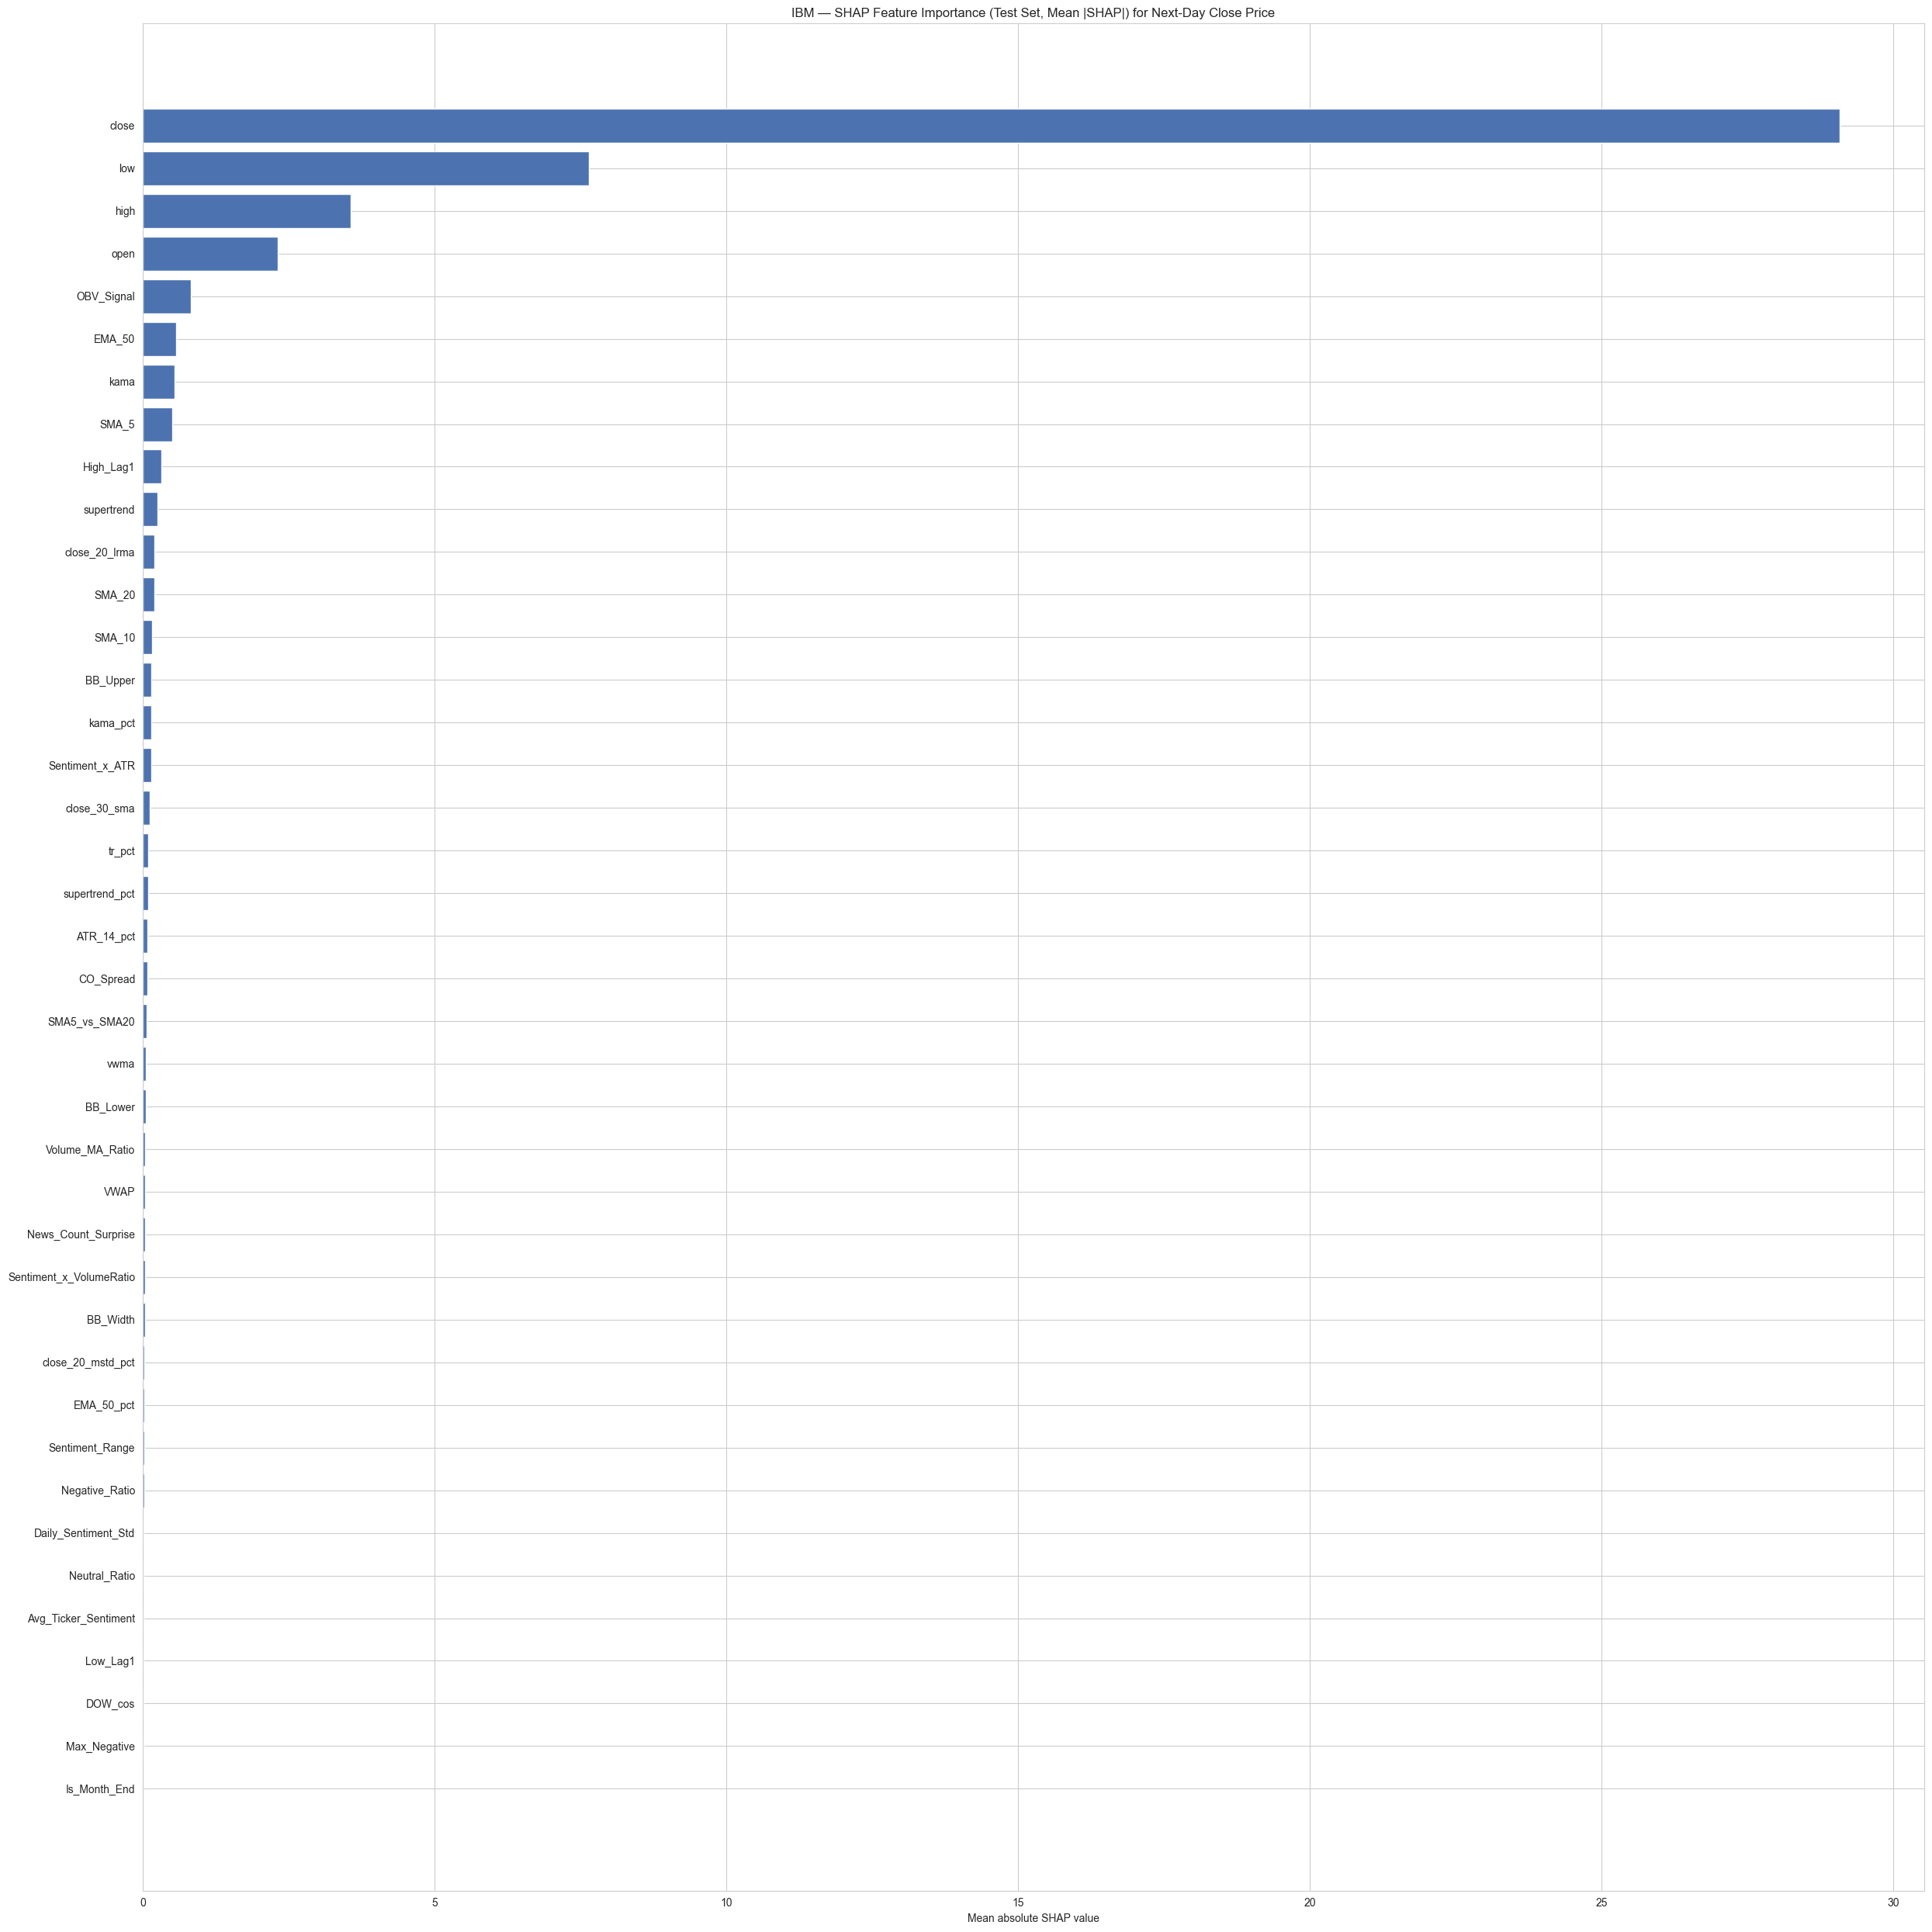

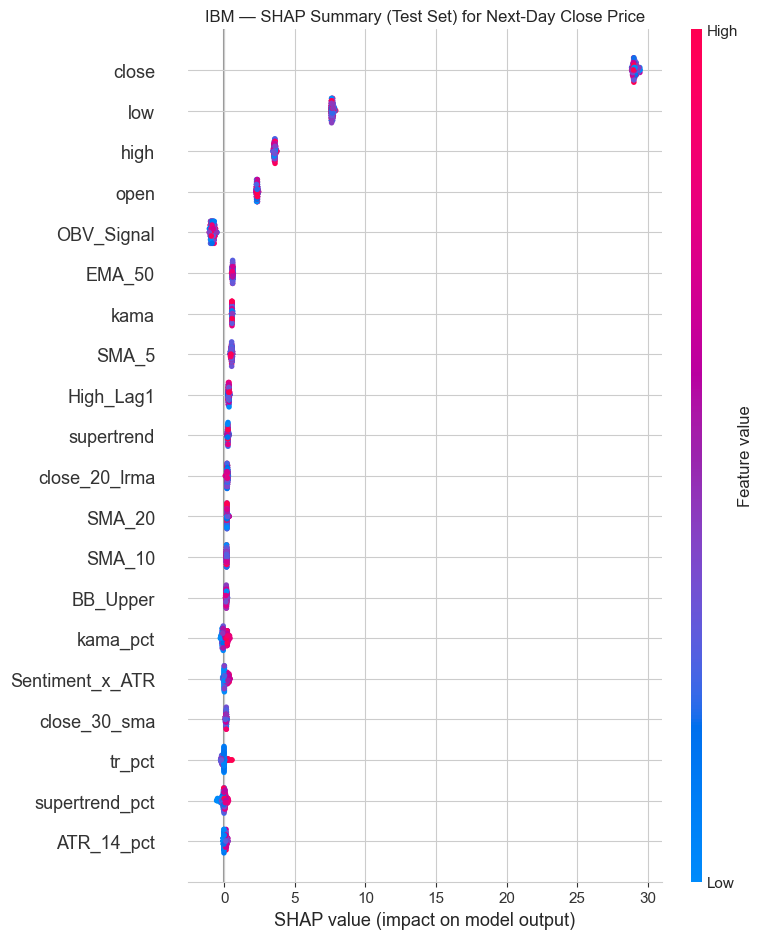

,Feature,Mean_Abs_SHAP
0,close,29.077589
1,low,7.649781
2,high,3.567683
3,open,2.319650
18,OBV_Signal,0.833070
23,EMA_50,0.578356
4,kama,0.548334
6,SMA_5,0.513445
7,High_Lag1,0.315597
36,supertrend,0.256788


In [34]:
import sys
!{sys.executable} -m pip install -q shap
import shap

# xgb_reg_close (Section 4) was fit on the FULL candidate feature set, so SHAP is computed here
# on a compact regressor refit on just the XGBoost-selected features -- this directly
# interprets the feature set that every downstream sequence model actually uses.
# shap.TreeExplainer is exact and fast for tree ensembles (no sampling/approximation needed,
# unlike KernelExplainer), and gives per-prediction attributions on top of the global ranking,
# unlike permutation importance which only reports an aggregate score drop.
xgb_reg_selected = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1
)
xgb_reg_selected.fit(train_df[selected_features], train_df['target_next_close'])

explainer = shap.TreeExplainer(xgb_reg_selected)
shap_values = explainer.shap_values(test_df[selected_features])

shap_df = pd.DataFrame({
    'Feature': selected_features,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0),
}).sort_values('Mean_Abs_SHAP', ascending=False)

# Global ranking -- mean absolute SHAP value per feature (bar plot, same layout as the
# permutation-importance chart it replaces)
plt.figure(figsize=(25, 25))
plt.barh(shap_df['Feature'][::-1], shap_df['Mean_Abs_SHAP'][::-1], color='#4c72b0')
plt.title(f'{TICKER} — SHAP Feature Importance (Test Set, Mean |SHAP|) for Next-Day Close Price')
plt.xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

# Beeswarm summary -- adds direction (does a high/low feature value push the prediction up or
# down?) and per-sample spread, which a bar chart of aggregate importance can't show
shap.summary_plot(shap_values, test_df[selected_features], show=False)
plt.title(f'{TICKER} — SHAP Summary (Test Set) for Next-Day Close Price')
plt.tight_layout()
plt.show()

shap_df.head(25)

## 17. Complexity vs. Performance Trade-Off Analysis

Trainable-parameter count and per-sample inference latency - the two axes of the complexity trade-off - compared against each model's test performance.


In [35]:
# Trainable-parameter count and per-sample inference latency -- the two axes of the complexity trade-off
def count_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))

def infer_time_ms(model, X, n_repeats=3):
    times = []
    for _ in range(n_repeats):
        t0 = time.time()
        model.predict(X, verbose=0)
        times.append((time.time() - t0) * 1000 / len(X))
    return float(np.mean(times))

complexity_rows = []
for name, (model, result_row) in reg_models.items():
    complexity_rows.append({
        'Model': name, 'Params': count_params(model),
        'Train_s': result_row['Train_s'], 'Infer_ms_per_sample': infer_time_ms(model, X_test_seq),
    })
complexity_df = pd.DataFrame(complexity_rows)

# Merge in the task-relevant performance metrics for BOTH targets for a joint view
complexity_reg = complexity_df.merge(
    reg_results[['Model', 'Open_Scaled_RMSE', 'Close_Scaled_RMSE']], on='Model', how='left')

print('Complexity vs. performance (Open & Close)')
display(complexity_reg)


Complexity vs. performance (Open & Close)


,Model,Params,Train_s,Infer_ms_per_sample,Open_Scaled_RMSE,Close_Scaled_RMSE
0,Baseline (LSTM+GRU),51952,17.231504,0.530010,7.871848,7.864873
1,Advanced 1 (BiLSTM+Attention),20898,17.114963,0.324972,7.559481,7.466360
2,Advanced 2 (Transformer),19522,33.710927,0.326331,8.401658,8.712989
3,Advanced 2b (Baseline+Transformer),69772,29.284912,1.216288,8.230107,8.581103
4,Advanced 3 (TCN),21826,15.859056,0.305705,0.664679,0.720810
5,Optimized (baseline),174850,64.800204,0.731090,7.899641,7.874971
6,Optimized (bilstm_attention),181602,111.584720,0.795556,6.520837,6.472460
7,Optimized (transformer),15362,27.104000,0.324150,8.035859,8.043202
8,Optimized (baseline_transformer),159576,64.408555,0.857144,8.508198,8.405688
9,Optimized (tcn),46866,42.491456,0.345713,0.689911,0.674086


### 17.1 Complexity vs. Performance Scatter Plot

Plots each model's trainable-parameter count against its test performance for **both** predicted
targets, to visualise the accuracy/complexity trade-off from the table above.

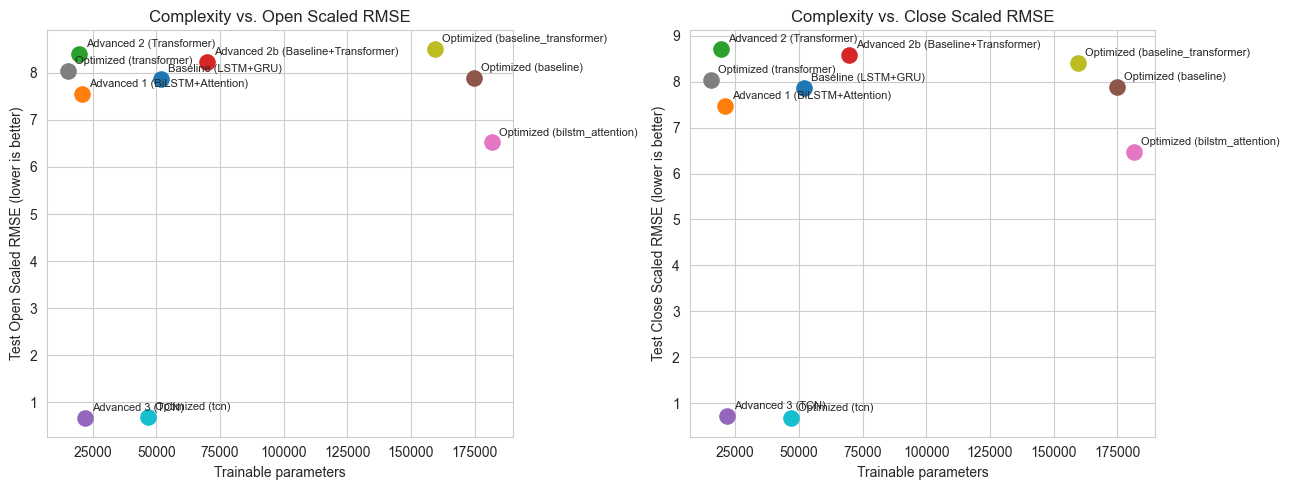

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Every model (base + all 4 optimized) was tuned/evaluated fairly for both targets,
# so both panels plot the full model set.
for _, row in complexity_reg.iterrows():
    axes[0].scatter(row['Params'], row['Open_Scaled_RMSE'], s=120)
    axes[0].annotate(row['Model'], (row['Params'], row['Open_Scaled_RMSE']), fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[0].set_xlabel('Trainable parameters')
axes[0].set_ylabel('Test Open Scaled RMSE (lower is better)')
axes[0].set_title('Complexity vs. Open Scaled RMSE')

for _, row in complexity_reg.iterrows():
    axes[1].scatter(row['Params'], row['Close_Scaled_RMSE'], s=120)
    axes[1].annotate(row['Model'], (row['Params'], row['Close_Scaled_RMSE']), fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Trainable parameters')
axes[1].set_ylabel('Test Close Scaled RMSE (lower is better)')
axes[1].set_title('Complexity vs. Close Scaled RMSE')

plt.tight_layout()
plt.show()


In [ ]:
# True forward forecast: predicted next trading day's Open and Close
# Uses the BEST TUNED/OPTIMIZED architecture SEPARATELY for Open and Close
# (selected on the robust 10-run metric for each target individually, not a
# combined score), each retrained on ALL available history (train+val+test)
# before producing the live forecast.

import sys
# NYSE-aware trading-calendar (plain BDay(1) only skips weekends, not market holidays)
try:
    import pandas_market_calendars as mcal
except ImportError:
    get_ipython().system(f'{sys.executable} -m pip install -q pandas_market_calendars')
    import pandas_market_calendars as mcal


# 1) Pick the best OPTIMIZED architecture for Open and for Close
#    INDEPENDENTLY, using the robust 10-run mean (all_model_results)
#    for each target's own RMSE -- rather than an equally-weighted
#    combined score. This lets Open and Close end up using different
#    architectures if that's what the tuning results support.
optimized_labels = [f'Optimized ({arch})' for arch in ARCHITECTURES_TO_TUNE]

open_scores = {
    f'Optimized ({arch})': optimized_results[arch][0]['Val_Open_Scaled_RMSE']
    for arch in ARCHITECTURES_TO_TUNE
}
close_scores = {
    f'Optimized ({arch})': optimized_results[arch][0]['Val_Close_Scaled_RMSE']
    for arch in ARCHITECTURES_TO_TUNE
}

best_open_label = min(open_scores, key=open_scores.get)
best_close_label = min(close_scores, key=close_scores.get)
best_open_arch = best_open_label.split('(')[1].rstrip(')')
best_close_arch = best_close_label.split('(')[1].rstrip(')')

print(f"[{TICKER}] Val_Open_Scaled_RMSE (10-run mean) per optimized model:")
for label, score in sorted(open_scores.items(), key=lambda kv: kv[1]):
    marker = "  <-- best for Open" if label == best_open_label else ""
    print(f"  {label:<28} {score:.4f}{marker}")

print(f"\n[{TICKER}] Val_Close_Scaled_RMSE (10-run mean) per optimized model:")
for label, score in sorted(close_scores.items(), key=lambda kv: kv[1]):
    marker = "  <-- best for Close" if label == best_close_label else ""
    print(f"  {label:<28} {score:.4f}{marker}")

print(f"\n[{TICKER}] Selected architecture for Open  deployment: {best_open_arch}  ({best_open_label})")
print(f"[{TICKER}] Selected architecture for Close deployment: {best_close_arch}  ({best_close_label})")


# 2) Figure out how many epochs to train each model for. We don't want
#    to reuse early stopping blindly on the combined dataset (no more
#    held-out val set once train+val+test are merged), so instead we
#    reuse the epoch count that each model's own validation curve
#    already told us was best (lowest val_loss) during the original
#    tuning run, stored in TRAINING_HISTORIES from
#    evaluate_with_paper_protocol.
def best_epoch_for(label):
    hist = TRAINING_HISTORIES[label]
    return int(np.argmin(hist['val_loss'])) + 1  # +1: argmin is 0-indexed

best_open_epoch_count = best_epoch_for(best_open_label)
best_close_epoch_count = best_epoch_for(best_close_label)

print(f"\n[{TICKER}] Retraining Open  model for {best_open_epoch_count} epochs "
      f"(lowest val_loss epoch in the original tuning run).")
print(f"[{TICKER}] Retraining Close model for {best_close_epoch_count} epochs "
      f"(lowest val_loss epoch in the original tuning run).")


# 3) Rebuild each winning architecture with its TUNED hyperparameters,
#    and refit each on the FULL history (train+val+test) -- not just
#    the 80% train split -- so the deployed models have actually seen
#    the most recent price regime before predicting tomorrow.
#    Note: each model still predicts BOTH Open and Close (that's how
#    they were built/trained), but we will only keep the Open output
#    from the Open-selected model, and the Close output from the
#    Close-selected model.
X_full_scaled = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
y_full_reg    = np.vstack([y_train_reg,    y_val_reg,    y_test_reg])
X_full_seq, y_full_reg_seq = make_sequences(X_full_scaled, y_full_reg, WINDOW)

def train_final_model(arch, epoch_count):
    build_fn, _ = BUILD_FN_MAP[arch]
    hp_values = optimized_hps[arch].values
    tf.keras.utils.set_random_seed(SEED)
    model = build_fn(**hp_values)
    model.fit(X_full_seq, y_full_reg_seq,
              epochs=epoch_count, batch_size=CONFIG['BATCH_SIZE'], verbose=0)
    return model

# Avoid training the same architecture twice if Open and Close happened
# to pick the same one.
if best_open_arch == best_close_arch and best_open_epoch_count == best_close_epoch_count:
    shared_model = train_final_model(best_open_arch, best_open_epoch_count)
    open_model, close_model = shared_model, shared_model
else:
    open_model = train_final_model(best_open_arch, best_open_epoch_count)
    close_model = train_final_model(best_close_arch, best_close_epoch_count)


# 4) Predict the next trading day from the most recent WINDOW days,
#    taking Open from the Open-selected model and Close from the
#    Close-selected model.
last_window = X_full_scaled[-WINDOW:].reshape(1, WINDOW, N_FEATURES)

open_pred_scaled  = open_model.predict(last_window, verbose=0)
close_pred_scaled = close_model.predict(last_window, verbose=0)

pred_open  = y_scaler_open.inverse_transform(open_pred_scaled[:, [0]])[0, 0]
pred_close = y_scaler_close.inverse_transform(close_pred_scaled[:, [1]])[0, 0]

# NYSE-aware next trading day (skips weekends AND market holidays)
last_date = df['date'].max()
nyse = mcal.get_calendar('NYSE')
schedule = nyse.valid_days(start_date=last_date, end_date=last_date + pd.Timedelta(days=10))
next_trading_day = schedule[schedule > pd.Timestamp(last_date, tz=schedule.tz)][0]

print(f"\n[{TICKER}] Open  model used : {best_open_label} (retrained on full train+val+test history)")
print(f"[{TICKER}] Close model used : {best_close_label} (retrained on full train+val+test history)")
print(f"[{TICKER}] Last known date  : {last_date.date()}")
print(f"[{TICKER}] Predicted next trading day ({next_trading_day.date()}):")
print(f"  Open : ${pred_open:.2f}")
print(f"  Close: ${pred_close:.2f}")

[IBM] Val_Open_Scaled_RMSE (10-run mean) per optimized model:
  Optimized (tcn)              0.3340  <-- best for Open
  Optimized (bilstm_attention) 1.8071
  Optimized (baseline)         2.5036
  Optimized (transformer)      2.6647
  Optimized (baseline_transformer) 2.7707

[IBM] Val_Close_Scaled_RMSE (10-run mean) per optimized model:
  Optimized (tcn)              0.3735  <-- best for Close
  Optimized (bilstm_attention) 1.8078
  Optimized (baseline)         2.4837
  Optimized (transformer)      2.6705
  Optimized (baseline_transformer) 2.8252

[IBM] Selected architecture for Open  deployment: tcn  (Optimized (tcn))
[IBM] Selected architecture for Close deployment: tcn  (Optimized (tcn))

[IBM] Retraining Open  model for 18 epochs (lowest val_loss epoch in the original tuning run).
[IBM] Retraining Close model for 18 epochs (lowest val_loss epoch in the original tuning run).

[IBM] Open  model used : Optimized (tcn) (retrained on full train+val+test history)
[IBM] Close model used :

## 18. Business Interpretation and Recommendations


In [ ]:
# Save all trained models (5 base architectures + 5 tuned/optimized variants) plus the
# scalers/config/selected-features needed to reuse any saved model later, into
# output/<TICKER>/<ArchName>/{basic,optimized}/
ticker_dir = ensure_ticker_dirs(TICKER, OUTPUT_ROOT)

BASE_MODELS = {
    'baseline':             (base_reg,  base_reg_result),
    'bilstm_attention':     (adv1_reg,  adv1_reg_result),
    'transformer':          (adv2_reg,  adv2_reg_result),
    'baseline_transformer': (adv2b_reg, adv2b_reg_result),
    'tcn':                  (adv3_reg,  adv3_reg_result),
}

for arch_key in ARCH_KEYS:
    arch_dir = os.path.join(ticker_dir, ARCH_FOLDER_NAME[arch_key])

    # basic (first of the ten independent runs, Section 10)
    basic_model, basic_result = BASE_MODELS[arch_key]
    basic_path = os.path.join(arch_dir, 'basic', 'model.keras')
    basic_model.save(basic_path)
    save_json({k: v for k, v in basic_result.items() if k != 'Model'},
               os.path.join(arch_dir, 'basic', 'result_row.json'))
    print(f"[{TICKER}] Saved basic {arch_key} model -> {basic_path}")

    # optimized (Keras-Tuner best hyperparameters, Section 14)
    opt_result, opt_model = optimized_results[arch_key]
    opt_path = os.path.join(arch_dir, 'optimized', 'model.keras')
    opt_model.save(opt_path)
    save_json({k: v for k, v in opt_result.items() if k != 'Model'},
               os.path.join(arch_dir, 'optimized', 'result_row.json'))
    save_json(dict(optimized_hps[arch_key].values),
               os.path.join(arch_dir, 'optimized', 'best_hyperparameters.json'))
    print(f"[{TICKER}] Saved optimized {arch_key} model -> {opt_path}")

# ticker-level artifacts needed to reuse ANY saved model for prediction later
with open(os.path.join(ticker_dir, 'scalers.pkl'), 'wb') as f:
    pickle.dump({
        'imputer': imputer, 'x_scaler': x_scaler,
        'y_scaler_open': y_scaler_open, 'y_scaler_close': y_scaler_close,
    }, f)
save_json(selected_features, os.path.join(ticker_dir, 'selected_features.json'))
save_json(CONFIG, os.path.join(ticker_dir, 'config.json'))
print(f"[{TICKER}] Saved scalers.pkl, selected_features.json, config.json -> {ticker_dir}")

# Also keep a flat pickle of the comparison tables/results (back-compat with the
# original single-file '{TICKER}_results.pkl' this cell used to produce)
artifacts = {
    'config': CONFIG,
    'ticker': TICKER,
    'selected_features': selected_features,
    'reg_results': reg_results,                # full test-set comparison table, all 10 models
    'reg_results_open': reg_results_open,       # Open-only metrics table (all 10 models)
    'reg_results_close': reg_results_close,     # Close-only metrics table (all 10 models)
    'complexity_reg': complexity_reg,
    'architectures_tuned': ARCHITECTURES_TO_TUNE,
    'best_hp_per_architecture': {arch: optimized_hps[arch].values for arch in ARCHITECTURES_TO_TUNE},
    'model_results': {
        'baseline_reg': base_reg_result,
        'adv1_reg': adv1_reg_result,
        'adv2_reg': adv2_reg_result,
        'adv2b_reg': adv2b_reg_result,
        'adv3_reg': adv3_reg_result,
        **{f'optimized_{arch}_reg': optimized_results[arch][0] for arch in ARCHITECTURES_TO_TUNE},
    },
}
with open(f'milestone5_{TICKER}_results.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Saved all 10 regression models (5 base architectures + 5 tuned/optimized variants), '
      f'scalers, config and selected features under {ticker_dir}/. Ticker-level comparison '
      'tables, the deployment summary and the next-day forecast are saved by the '
      '"Persist Ticker-Level Outputs" cell at the very end of this notebook, once the '
      'deployment model (Milestone 6 section) has been selected.')


[IBM] Saved basic baseline model -> outputs\IBM\Baseline_LSTM_GRU\basic\model.keras
[IBM] Saved optimized baseline model -> outputs\IBM\Baseline_LSTM_GRU\optimized\model.keras
[IBM] Saved basic bilstm_attention model -> outputs\IBM\BiLSTM_Attention\basic\model.keras
[IBM] Saved optimized bilstm_attention model -> outputs\IBM\BiLSTM_Attention\optimized\model.keras
[IBM] Saved basic transformer model -> outputs\IBM\Transformer\basic\model.keras
[IBM] Saved optimized transformer model -> outputs\IBM\Transformer\optimized\model.keras
[IBM] Saved basic baseline_transformer model -> outputs\IBM\Baseline_Transformer\basic\model.keras
[IBM] Saved optimized baseline_transformer model -> outputs\IBM\Baseline_Transformer\optimized\model.keras
[IBM] Saved basic tcn model -> outputs\IBM\TCN\basic\model.keras
[IBM] Saved optimized tcn model -> outputs\IBM\TCN\optimized\model.keras
[IBM] Saved scalers.pkl, selected_features.json, config.json -> outputs\IBM
Saved all 10 regression models (5 base archi

## Milestone 6 - Validation & Business Impact Assessment


### 19. Deployment Model Selection (Open & Close)

Picks one architecture for Open and one for Close, based on validation-set RMSE among the advanced architectures only (Section 15's Baseline is kept for reference but is never deployment-eligible). Section 19.1 runs a prediction-variance/bias gate first to screen out any model whose predictions have collapsed toward a constant.

#### Step 19.1 - Consolidate Model Selection Evidence

Merges the Section 15 / 15.6 test-set metrics and significance-test results for every architecture into a single `selection_df` table used to drive the deployment decision.


In [ ]:
# Consolidate the Section 15/15.6 evidence into one selection table
selection_df = reg_results[['Model', 'Open_Scaled_RMSE', 'Close_Scaled_RMSE',
                             'Open_Scaled_MAPE', 'Close_Scaled_MAPE']].copy()
selection_df = selection_df.merge(
    sig_open[['Diff vs. baseline', 'Paired t p-value', 'Significant (p<0.05)']]
        .rename(columns={'Diff vs. baseline': 'Open_Diff_vs_Baseline',
                          'Paired t p-value': 'Open_p_value',
                          'Significant (p<0.05)': 'Open_Significant'}),
    left_on='Model', right_index=True, how='left'
).merge(
    sig_close[['Diff vs. baseline', 'Paired t p-value', 'Significant (p<0.05)']]
        .rename(columns={'Diff vs. baseline': 'Close_Diff_vs_Baseline',
                          'Paired t p-value': 'Close_p_value',
                          'Significant (p<0.05)': 'Close_Significant'}),
    left_on='Model', right_index=True, how='left'
)
selection_df = selection_df.sort_values('Close_Scaled_RMSE').reset_index(drop=True)
selection_df

,Model,Open_Scaled_RMSE,Close_Scaled_RMSE,Open_Scaled_MAPE,Close_Scaled_MAPE,Open_Diff_vs_Baseline,Open_p_value,Open_Significant,Close_Diff_vs_Baseline,Close_p_value,Close_Significant
0,Optimized (tcn),0.689911,0.674086,4.888206,4.369112,-7.385979,5.026856e-16,True,-7.297317,1.975572e-16,True
1,Advanced 3 (TCN),0.664679,0.720810,4.581179,4.649557,-7.338124,1.120641e-16,True,-7.255847,6.376281e-17,True
2,Optimized (bilstm_attention),6.520837,6.472460,51.533080,51.237088,-1.251593,1.012121e-07,True,-1.347435,1.265028e-10,True
3,Advanced 1 (BiLSTM+Attention),7.559481,7.466360,60.625420,59.977368,-0.371631,1.029542e-04,True,-0.432941,2.130121e-05,True
4,Baseline (LSTM+GRU),7.871848,7.864873,63.030139,63.087858,0.000000,NaN,False,0.000000,NaN,False
5,Optimized (baseline),7.899641,7.874971,63.407069,63.290035,0.163610,1.462881e-01,False,0.165018,1.570321e-01,False
6,Optimized (transformer),8.035859,8.043202,64.709214,64.873215,0.208103,1.154653e-03,True,0.160868,8.164827e-03,True
7,Optimized (baseline_transformer),8.508198,8.405688,68.652992,67.763439,0.333248,3.161699e-03,True,0.282766,3.318908e-03,True
8,Advanced 2b (Baseline+Transformer),8.230107,8.581103,66.359580,69.515337,0.462260,9.546693e-06,True,0.575170,6.416938e-07,True
9,Advanced 2 (Transformer),8.401658,8.712989,68.235769,70.950852,0.444684,1.081640e-04,True,0.408859,1.629256e-03,True


#### Step 19.2 - Define Collapse & Bias Thresholds

Sets the `COLLAPSE_RATIO_THRESHOLD` / `BIAS_THRESHOLD` constants and defines the `prediction_variance_ratio` / `prediction_bias` helper functions used to flag models whose outputs have collapsed toward a constant.


In [ ]:
# Flag models whose predictions are collapsed or biased on the validation set, to help
# avoid picking a model that looks good on the test set by chance but is actually degenerate (e.g. always predicting the mean).
COLLAPSE_RATIO_THRESHOLD = 0.05
BIAS_THRESHOLD = 0.15   # flag if |mean(pred) - mean(true)| exceeds this, in scaled units

def prediction_variance_ratio(model, X, y_true_scaled, col):
    pred = model.predict(X, verbose=0)[:, col]
    true_std = y_true_scaled[:, col].std()
    return pred.std() / (true_std + 1e-12)

def prediction_bias(model, X, y_true_scaled, col):
    pred = model.predict(X, verbose=0)[:, col]
    return pred.mean() - y_true_scaled[:, col].mean()

variance_gate_rows = []
for name, (model, _) in reg_models.items():
    open_ratio  = prediction_variance_ratio(model, X_val_seq, y_val_reg, col=0)
    close_ratio = prediction_variance_ratio(model, X_val_seq, y_val_reg, col=1)
    open_bias   = prediction_bias(model, X_val_seq, y_val_reg, col=0)
    close_bias  = prediction_bias(model, X_val_seq, y_val_reg, col=1)
    variance_gate_rows.append({
        'Model': name,
        'Open_Var_Ratio (val)': open_ratio,
        'Close_Var_Ratio (val)': close_ratio,
        'Open_Collapsed':  open_ratio  < COLLAPSE_RATIO_THRESHOLD,
        'Close_Collapsed': close_ratio < COLLAPSE_RATIO_THRESHOLD,
        'Open_Bias (val)':  open_bias,
        'Close_Bias (val)': close_bias,
        'Open_Biased':  abs(open_bias)  > BIAS_THRESHOLD,
        'Close_Biased': abs(close_bias) > BIAS_THRESHOLD,
    })
variance_gate_df = pd.DataFrame(variance_gate_rows).set_index('Model')
print("Prediction-variance collapse gate (validation set):")
variance_gate_df

Prediction-variance collapse gate (validation set):


,Open_Var_Ratio (val),Close_Var_Ratio (val),Open_Collapsed,Close_Collapsed,Open_Bias (val),Close_Bias (val),Open_Biased,Close_Biased
Model,,,,,,,,
Baseline (LSTM+GRU),0.082923,0.081651,False,False,-1.828595,-1.814458,True,True
Advanced 1 (BiLSTM+Attention),0.194153,0.199542,False,False,-1.890389,-1.824765,True,True
Advanced 2 (Transformer),0.240560,0.210466,False,False,-2.560362,-2.752437,True,True
Advanced 2b (Baseline+Transformer),0.045155,0.016110,True,True,-2.241362,-2.518173,True,True
Advanced 3 (TCN),0.981853,0.991314,False,False,0.049172,0.162968,False,True
Optimized (baseline),0.014800,0.015069,True,True,-1.869505,-1.843679,True,True
Optimized (bilstm_attention),0.295536,0.313316,False,False,-1.323218,-1.345569,True,True
Optimized (transformer),0.096488,0.095552,False,False,-2.144729,-2.150856,True,True
Optimized (baseline_transformer),0.078356,0.080249,False,False,-2.226128,-2.264562,True,True


#### Step 19.3 - Select Deployment Models (Open & Close)

Independently selects the deployment architecture for Open and for Close from `reg_models`, based on validation RMSE, and stores the winners as `DEPLOY_MODEL_NAME_OPEN` / `DEPLOY_MODEL_NAME_CLOSE`.


In [ ]:
# Select the deployment model independently for Open and Close, using VALIDATION RMSE
# Reuse the canonical `reg_models` dict from Section 15.2/15.3: it already contains all 5 base
# architectures plus their tuned/optimized counterparts from Section 14, keyed by the exact same
# model-name strings used everywhere else (pr_map, complexity_reg, all_model_results).
#
# Selection is on Val_Open_Scaled_RMSE / Val_Close_Scaled_RMSE (validation), NOT the test-set
# Open_Scaled_RMSE / Close_Scaled_RMSE -- picking based on test performance would mean the test
# numbers reported later are no longer an honest out-of-sample estimate.
#
# Requirement: the deployment slot must go to one of the four advanced architectures
# (BiLSTM+Attention, Transformer, Baseline+Transformer, TCN) -- the plain LSTM+GRU Baseline is
# kept in every comparison table for reference, but is never eligible to win Open/Close
# deployment.
#
# Each architecture is tuned once on a combined Open+Close objective (val_mean_rmse), so a
# single 'Optimized (architecture)' model is a valid candidate for both the Open slot and the
# Close slot.
ADVANCED_ARCHITECTURE_TAGS = (
    'Advanced 1 (BiLSTM+Attention)',
    'Advanced 2 (Transformer)',
    'Advanced 2b (Baseline+Transformer)',
    'Advanced 3 (TCN)',
    'Optimized (bilstm_attention)',
    'Optimized (transformer)',
    'Optimized (baseline_transformer)',
    'Optimized (tcn)',
)

def candidate_pool():
    """Only the advanced architectures (BiLSTM+Attention, Transformer, Baseline+Transformer,
    TCN -- base or tuned) are eligible for deployment. The Baseline (LSTM+GRU) and its tuned
    variant remain in every comparison table as a reference point, but are never
    deployment-eligible.
    """
    return [name for name in reg_models if name in ADVANCED_ARCHITECTURE_TAGS]

def select_best(target_key):
    """Pick the model with the lowest Val_<target>_Scaled_RMSE among the advanced-architecture
    candidates that pass the Section 19.1 variance-collapse gate. Falls back to the plain
    RMSE-best model in that same restricted pool (with an explicit warning) only if every one
    of them has collapsed. The Baseline is never a candidate here (see candidate_pool above).
    """
    collapse_col = f'{target_key}_Collapsed'
    pool = candidate_pool()
    if not pool:
        raise RuntimeError(
            f"No advanced-architecture candidates found for {target_key} in reg_models -- "
            f"make sure Sections 11-14 (BiLSTM+Attention, Transformer, Baseline+Transformer, "
            f"TCN, and their tuned variants) ran and populated reg_models before this cell."
        )
    passing = [name for name in pool if not variance_gate_df.loc[name, collapse_col]]
    candidates = passing if passing else pool
    if not passing:
        print(f"WARNING: every advanced-architecture candidate model's {target_key} "
              f"predictions look collapsed (variance ratio < {COLLAPSE_RATIO_THRESHOLD}) on "
              f"validation data -- falling back to the lowest-RMSE advanced model anyway. "
              f"Treat the {target_key} deployment model with caution and compare it against "
              f"the naive baseline in Section 23.")
    best_name = min(candidates, key=lambda n: reg_models[n][1][f'Val_{target_key}_Scaled_RMSE'])
    return best_name, reg_models[best_name][0], reg_models[best_name][1]

best_open_name, best_open_model, best_open_result = select_best('Open')
best_close_name, best_close_model, best_close_result = select_best('Close')

DEPLOY_MODEL_NAME_OPEN  = best_open_name
DEPLOY_MODEL_NAME_CLOSE = best_close_name

deploy_model_open   = best_open_model
deploy_result_open   = best_open_result
deploy_model_close  = best_close_model
deploy_result_close  = best_close_result

print(f'Best OPEN  model (lowest validation RMSE, advanced architectures only): {DEPLOY_MODEL_NAME_OPEN}')
print(f"  Val_Open_Scaled_RMSE  = {deploy_result_open['Val_Open_Scaled_RMSE']:.4f}   "
      f"Test_Open_Scaled_RMSE = {deploy_result_open['Open_Scaled_RMSE']:.4f}")
print(f'\nBest CLOSE model (lowest validation RMSE, advanced architectures only): {DEPLOY_MODEL_NAME_CLOSE}')
print(f"  Val_Close_Scaled_RMSE = {deploy_result_close['Val_Close_Scaled_RMSE']:.4f}   "
      f"Test_Close_Scaled_RMSE = {deploy_result_close['Close_Scaled_RMSE']:.4f}")

if DEPLOY_MODEL_NAME_OPEN == DEPLOY_MODEL_NAME_CLOSE:
    print(f'\nSame architecture wins both targets: {DEPLOY_MODEL_NAME_OPEN}')
else:
    print(f'\nOpen and Close favor different architectures -- both are carried forward '
          f'independently through the rest of this notebook.')


Best OPEN  model (lowest validation RMSE, advanced architectures only): Optimized (tcn)
  Val_Open_Scaled_RMSE  = 0.3340   Test_Open_Scaled_RMSE = 0.6899

Best CLOSE model (lowest validation RMSE, advanced architectures only): Optimized (tcn)
  Val_Close_Scaled_RMSE = 0.3735   Test_Close_Scaled_RMSE = 0.6741

Same architecture wins both targets: Optimized (tcn)


#### Step 19.4 - Sanity-Check the Raw Predictions

Checks whether the deployed Open model's predictions are genuinely varying (not just appearing constant after `inverse_transform`) by comparing predicted vs. actual return statistics.


In [ ]:
# Are the raw (pre-inverse-transform) predictions really constant?
pred_scaled = deploy_model_open.predict(X_test_seq, verbose=0)
pred_open_ret = y_scaler_open.inverse_transform(pred_scaled[:, [0]]).ravel()
true_open_ret = y_scaler_open.inverse_transform(y_test_reg_seq[:, [0]]).ravel()

print("predicted return std:", pred_open_ret.std(), " mean:", pred_open_ret.mean())
print("actual    return std:", true_open_ret.std(), " mean:", true_open_ret.mean())
print("ratio (pred_std / true_std):", pred_open_ret.std() / true_open_ret.std())

predicted return std: 25.60327  mean: 265.66766
actual    return std: 25.75539061833082  mean: 261.79549655298183
ratio (pred_std / true_std): 0.9940936232123699


#### Step 19.5 - Kernel-Weight Collapse Check

Inspects the deployed model's raw (pre-inverse-transform) outputs and layer weights directly to confirm the network hasn't collapsed to predicting a near-constant value.


In [ ]:
# 19.3 Kernel-weight collapse check: did the layer weights (not just outputs)
# collapse toward zero, with only the biases staying large?
# 1. Are the actual raw predictions constant, or does inverse_transform make them look constant?
raw_pred = deploy_model_open.predict(X_test_seq, verbose=0)
print("raw scaled prediction std:", raw_pred[:, 0].std())
print("first 10 raw predictions:", raw_pred[:10, 0])

# 2. Check the model's weights for the output layer -- did they collapse toward zero?
for layer in deploy_model_open.layers:
    if layer.trainable_weights:
        for w in layer.get_weights():
            print(layer.name, w.shape, "std:", w.std(), "mean:", w.mean())

raw scaled prediction std: 1.9425354
first 10 raw predictions: [8.552176  8.558181  8.635903  8.686656  8.734377  8.7798395 8.8413515
 9.105599  9.290868  9.64551  ]
conv1d_7 (7, 40, 32) std: 0.06341284 mean: 0.00025615786
conv1d_7 (32,) std: 0.012052012 mean: -0.0143193975
conv1d_8 (7, 32, 32) std: 0.06730313 mean: -0.0040983334
conv1d_8 (32,) std: 0.010205089 mean: -0.0037282764
conv1d_9 (1, 40, 32) std: 0.16619973 mean: -0.01070284
conv1d_9 (32,) std: 0.014233963 mean: 0.0011540332
conv1d_10 (7, 32, 32) std: 0.06754964 mean: -0.00033149682
conv1d_10 (32,) std: 0.014389614 mean: -0.005300624
conv1d_11 (7, 32, 32) std: 0.06697845 mean: -0.0015887718
conv1d_11 (32,) std: 0.01382141 mean: 0.00093743217
conv1d_12 (7, 32, 32) std: 0.067398354 mean: 0.00033148777
conv1d_12 (32,) std: 0.015342006 mean: -0.0007035435
conv1d_13 (7, 32, 32) std: 0.067364864 mean: -3.589763e-05
conv1d_13 (32,) std: 0.015918095 mean: 0.0012700486
dense_1 (32, 16) std: 0.20103803 mean: 0.002816042
dense_1 (16,) s

## 20. Validation Summary

Summarizes the deployed Open and Close models' test and cross-validation performance in one table, then plots each model's 10-run mean RMSE with 95% confidence intervals against every other model.

#### Step 20.1 - Build the Validation Summary Table

Assembles `val_summary`, a compact table reporting the chosen deployment models and their test/CV RMSE and MAPE for both Open and Close.


In [76]:
val_summary = pd.DataFrame({
    'Metric': ['Deployment model chosen',
               'Test Open/Close Scaled RMSE (1st run)',
               'Test Open/Close Scaled RMSE (10-run mean +/- std)',
               'Train-period 5-fold CV Open/Close RMSE (mean +/- std)',
               'Test Open/Close MAPE (10-run mean)'],
    'Open': [
        DEPLOY_MODEL_NAME_OPEN,
        f"{deploy_result_open['Open_Scaled_RMSE']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['Open_Scaled_RMSE']:.4f} +/- "
        f"{all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['Open_Scaled_RMSE_std']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['CV_Open_Scaled_RMSE']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['Open_Scaled_MAPE']:.2f}%",
    ],
    'Close': [
        DEPLOY_MODEL_NAME_CLOSE,
        f"{deploy_result_close['Close_Scaled_RMSE']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['Close_Scaled_RMSE']:.4f} +/- "
        f"{all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['Close_Scaled_RMSE_std']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['CV_Close_Scaled_RMSE']:.4f}",
        f"{all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['Close_Scaled_MAPE']:.2f}%",
    ],
})
val_summary


,Metric,Open,Close
0,Deployment model chosen,Optimized (tcn),Optimized (tcn)
1,Test Open/Close Scaled RMSE (1st run),0.6899,0.6741
2,Test Open/Close Scaled RMSE (10-run mean +/- std),0.5682 +/- 0.0736,0.6372 +/- 0.0461
3,Train-period 5-fold CV Open/Close RMSE (mean +...,0.1814,0.2368
4,Test Open/Close MAPE (10-run mean),3.79%,4.18%


#### Step 20.2 - Plot Validation Confidence Intervals

Plots the 95% confidence intervals (from the Section 15.6 significance tests) for each model's Open and Close error, highlighting the deployed model.


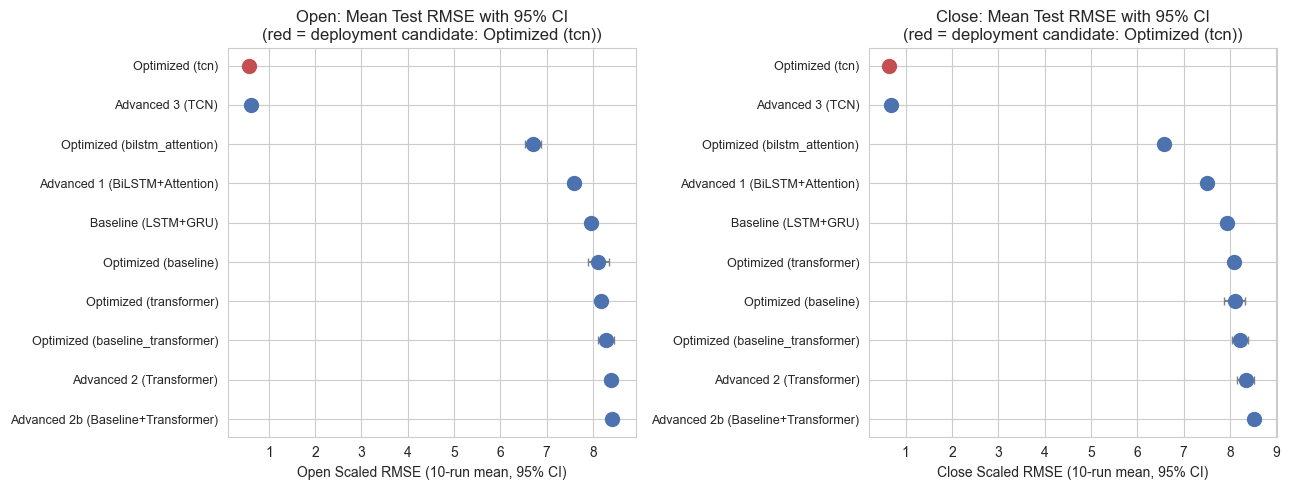

Optimized (tcn) 10-run std/mean ratio (coefficient of variation) -- Open: 12.96%
Optimized (tcn) 10-run std/mean ratio (coefficient of variation) -- Close: 7.23%


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, target_key, sig_df, label, deploy_name in [
    (axes[0], 'open',  sig_open,  'Open',  DEPLOY_MODEL_NAME_OPEN),
    (axes[1], 'close', sig_close, 'Close', DEPLOY_MODEL_NAME_CLOSE),
]:
    models_order = sig_df.index.tolist()
    means = sig_df['Mean'].values
    lo = sig_df['95% CI low'].values
    hi = sig_df['95% CI high'].values
    yerr = np.vstack([means - lo, hi - means])
    colors = ['#c44e52' if m == deploy_name else '#4c72b0' for m in models_order]
    ax.errorbar(means, range(len(models_order)), xerr=yerr, fmt='o', color='black', ecolor='gray', capsize=3)
    for i, c in enumerate(colors):
        ax.plot(means[i], i, 'o', color=c, markersize=10, zorder=3)
    ax.set_yticks(range(len(models_order)))
    ax.set_yticklabels(models_order, fontsize=9)
    ax.set_xlabel(f'{label} Scaled RMSE (10-run mean, 95% CI)')
    ax.set_title(f'{label}: Mean Test RMSE with 95% CI\n(red = deployment candidate: {deploy_name})')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"{DEPLOY_MODEL_NAME_OPEN} 10-run std/mean ratio (coefficient of variation) -- Open: "
      f"{all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['Open_Scaled_RMSE_std'] / all_model_results[DEPLOY_MODEL_NAME_OPEN]['open']['Open_Scaled_RMSE']:.2%}")
print(f"{DEPLOY_MODEL_NAME_CLOSE} 10-run std/mean ratio (coefficient of variation) -- Close: "
      f"{all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['Close_Scaled_RMSE_std'] / all_model_results[DEPLOY_MODEL_NAME_CLOSE]['close']['Close_Scaled_RMSE']:.2%}")


## 21. Input Noise Sensitivity Analysis

Injects Gaussian noise at increasing scales into the test features and measures how much each deployment model's predictions degrade, as a simple robustness check.

#### Step 21.1 - Run the Noise Sensitivity Experiment

Injects Gaussian noise at increasing standard deviations into the scaled test sequences and measures how much the deployed Open/Close models' RMSE degrades, storing results in `noise_df`.


In [78]:
# Inject Gaussian noise at increasing scales into the already-scaled test sequences and
# measure how much each deployment model's predictions degrade -- this uses the same scaled
# feature space the models were trained on. Features are StandardScaler-scaled (mean 0,
# std 1), so a noise_std of 0.01 means "0.01 standard deviations of the scaled feature".
# Open and Close each use their own selected model (they can differ), so both are run
# independently rather than assuming a single shared model.
np.random.seed(SEED)
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.10]
noise_rows = []

clean_pred_o = deploy_model_open.predict(X_test_seq, verbose=0)[:, 0]
clean_pred_c = deploy_model_close.predict(X_test_seq, verbose=0)[:, 1]

for noise_std in noise_levels:
    if noise_std == 0.0:
        X_noisy = X_test_seq
    else:
        noise = np.random.normal(0, noise_std, X_test_seq.shape)
        # StandardScaler output is unbounded (mean 0, std 1), so we clip to a generous
        # +/-6 std band -- wide enough to never affect realistic noise levels (std <= 0.10
        # here), but still guards against a pathological, non-physical outlier reaching the model.
        X_noisy = np.clip(X_test_seq + noise, -6.0, 6.0)

    y_pred_noisy_open  = deploy_model_open.predict(X_noisy, verbose=0)
    y_pred_noisy_close = deploy_model_close.predict(X_noisy, verbose=0)

    open_rmse_noisy  = np.sqrt(np.mean((y_pred_noisy_open[:, 0]  - y_test_reg_seq[:, 0])**2))
    close_rmse_noisy = np.sqrt(np.mean((y_pred_noisy_close[:, 1] - y_test_reg_seq[:, 1])**2))
    pred_shift_o = np.sqrt(np.mean((y_pred_noisy_open[:, 0]  - clean_pred_o)**2))
    pred_shift_c = np.sqrt(np.mean((y_pred_noisy_close[:, 1] - clean_pred_c)**2))

    noise_rows.append({
        'Noise_Std (scaled feature units)': noise_std,
        'Open_RMSE_vs_truth': open_rmse_noisy,
        'Close_RMSE_vs_truth': close_rmse_noisy,
        'Open_Pred_Shift_vs_clean': pred_shift_o,
        'Close_Pred_Shift_vs_clean': pred_shift_c,
    })

noise_df = pd.DataFrame(noise_rows)
noise_df


,Noise_Std (scaled feature units),Open_RMSE_vs_truth,Close_RMSE_vs_truth,Open_Pred_Shift_vs_clean,Close_Pred_Shift_vs_clean
0,0.00,0.689911,0.674086,0.000000,0.000000
1,0.01,6.146911,6.226048,6.450209,6.054127
2,0.02,6.146665,6.225700,6.449964,6.053732
3,0.05,6.148187,6.227621,6.451530,6.055737
4,0.10,6.147037,6.226967,6.450296,6.054822


#### Step 21.2 - Plot Noise Sensitivity Results

Plots RMSE vs. injected noise scale for both deployed models, with a reference line for their clean (noise-free) RMSE.


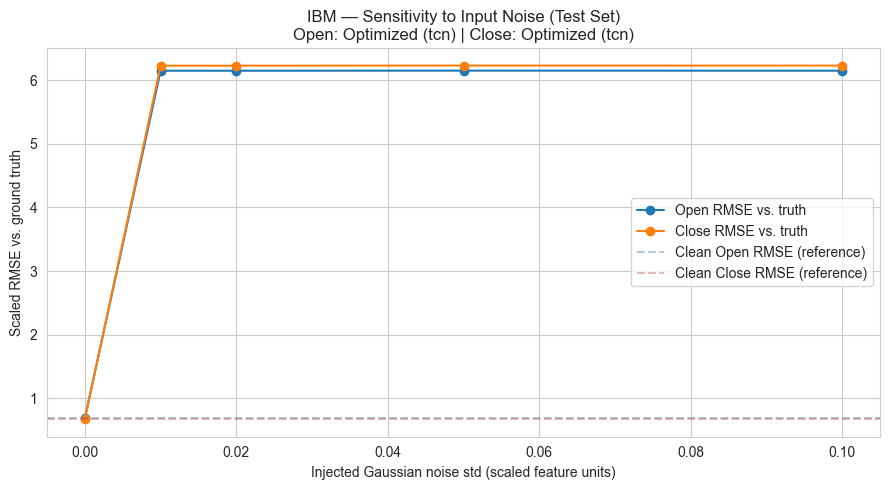

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(noise_df['Noise_Std (scaled feature units)'], noise_df['Open_RMSE_vs_truth'], marker='o', label='Open RMSE vs. truth')
ax.plot(noise_df['Noise_Std (scaled feature units)'], noise_df['Close_RMSE_vs_truth'], marker='o', label='Close RMSE vs. truth')
ax.axhline(deploy_result_open['Open_Scaled_RMSE'], color='#4c72b0', linestyle='--', alpha=0.4, label='Clean Open RMSE (reference)')
ax.axhline(deploy_result_close['Close_Scaled_RMSE'], color='#c44e52', linestyle='--', alpha=0.4, label='Clean Close RMSE (reference)')
ax.set_xlabel('Injected Gaussian noise std (scaled feature units)')
ax.set_ylabel('Scaled RMSE vs. ground truth')
ax.set_title(f'{TICKER} — Sensitivity to Input Noise (Test Set)\n'
             f'Open: {DEPLOY_MODEL_NAME_OPEN} | Close: {DEPLOY_MODEL_NAME_CLOSE}')
ax.legend()
plt.tight_layout()
plt.show()


## 22. Residual Analysis

Examines the deployment models' prediction errors in dollar terms: their distribution, the largest-error days, and whether errors cluster around high-volatility periods.

#### Step 22.1 - Recompute Dollar-Scale Residuals

Rebuilds the deployment models' test-set predictions and residuals in dollar terms so this section is self-contained (Open and Close use their own independently-selected winners).


In [80]:
# Rebuild the deployment models' test-set predictions/residuals in dollar terms (already
# computed once in Section 15.2/15.3 via pr_map; recomputed explicitly here so this section is
# self-contained). Open uses whichever model won Open by validation RMSE (Section 19); Close
# uses its own separately-selected winner -- they are NOT assumed to be the same model.
open_true,  open_pred,  _, _ = pr_map[DEPLOY_MODEL_NAME_OPEN][1]
_, _, close_true, close_pred = pr_map[DEPLOY_MODEL_NAME_CLOSE][1]

resid_open  = open_true  - open_pred
resid_close = close_true - close_pred

error_df = pd.DataFrame({
    'Actual_Open': open_true, 'Pred_Open': open_pred, 'Residual_Open': resid_open,
    'Actual_Close': close_true, 'Pred_Close': close_pred, 'Residual_Close': resid_close,
})

print(f"Residual summary -- OPEN  ({DEPLOY_MODEL_NAME_OPEN}):  mean={resid_open.mean():+.2f}, "
      f"std={resid_open.std():.2f}, max abs={np.abs(resid_open).max():.2f}")
print(f"Residual summary -- CLOSE ({DEPLOY_MODEL_NAME_CLOSE}): mean={resid_close.mean():+.2f}, "
      f"std={resid_close.std():.2f}, max abs={np.abs(resid_close).max():.2f}")


Residual summary -- OPEN  (Optimized (tcn)):  mean=-3.87, std=8.23, max abs=29.50
Residual summary -- CLOSE (Optimized (tcn)): mean=+2.44, std=8.57, max abs=29.64


#### Step 22.2 - Plot Residual Distributions

Plots histograms of the Open and Close residuals to visualize how prediction errors are distributed around zero.


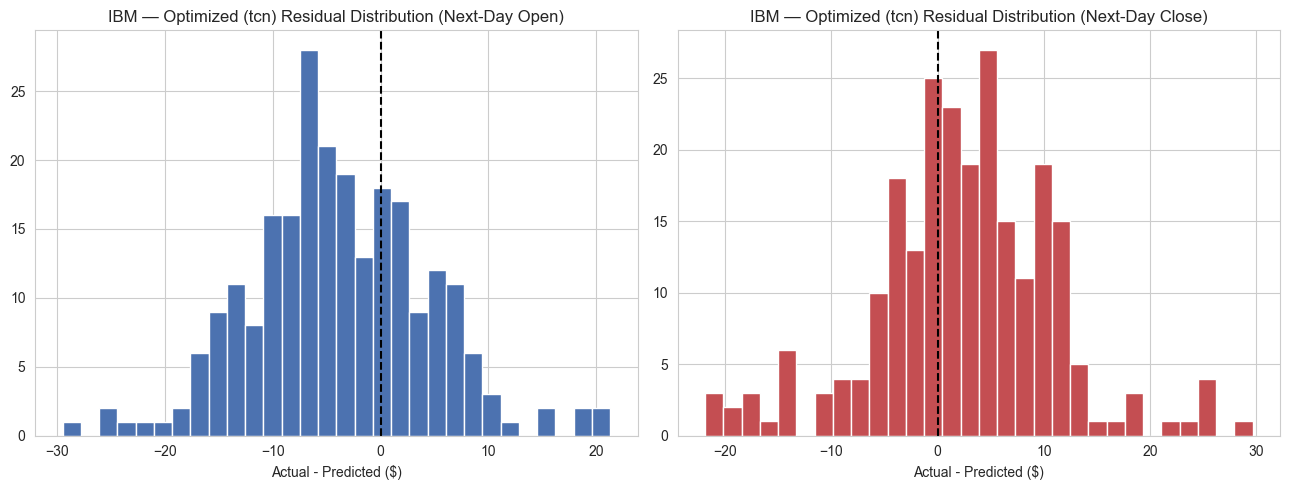

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(resid_open, bins=30, color='#4c72b0', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title(f'{TICKER} — {DEPLOY_MODEL_NAME_OPEN} Residual Distribution (Next-Day Open)')
axes[0].set_xlabel('Actual - Predicted ($)')

axes[1].hist(resid_close, bins=30, color='#c44e52', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title(f'{TICKER} — {DEPLOY_MODEL_NAME_CLOSE} Residual Distribution (Next-Day Close)')
axes[1].set_xlabel('Actual - Predicted ($)')
plt.tight_layout()
plt.show()


#### Step 22.3 - Identify the Largest-Residual Days

Surfaces the top 10 test-set days with the largest absolute Close residuals — the observations the deployed model got most wrong.


In [82]:
# Largest-residual days -- the observations the model got most wrong
top_n = 10
worst_close = error_df.reindex(error_df['Residual_Close'].abs().sort_values(ascending=False).index).head(top_n)
print(f'--- Top {top_n} largest-residual days (Next-Day Close) ---')
worst_close[['Actual_Close', 'Pred_Close', 'Residual_Close']]

--- Top 10 largest-residual days (Next-Day Close) ---


,Actual_Close,Pred_Close,Residual_Close
6,248.508682,218.872162,29.636520
8,250.875717,225.293152,25.582565
9,254.464737,229.003677,25.461060
192,307.345917,282.027649,25.318268
191,301.819183,276.626404,25.192780
7,246.035812,222.121613,23.914200
126,254.013184,275.874451,-21.861267
10,253.348602,232.058823,21.289780
132,243.814026,264.383881,-20.569855
131,246.836700,267.352478,-20.515778


#### Step 22.4 - Plot Residuals Over Time

Plots the Close residual over the test period to check whether errors cluster in specific (e.g. high-volatility) stretches rather than being spread uniformly.


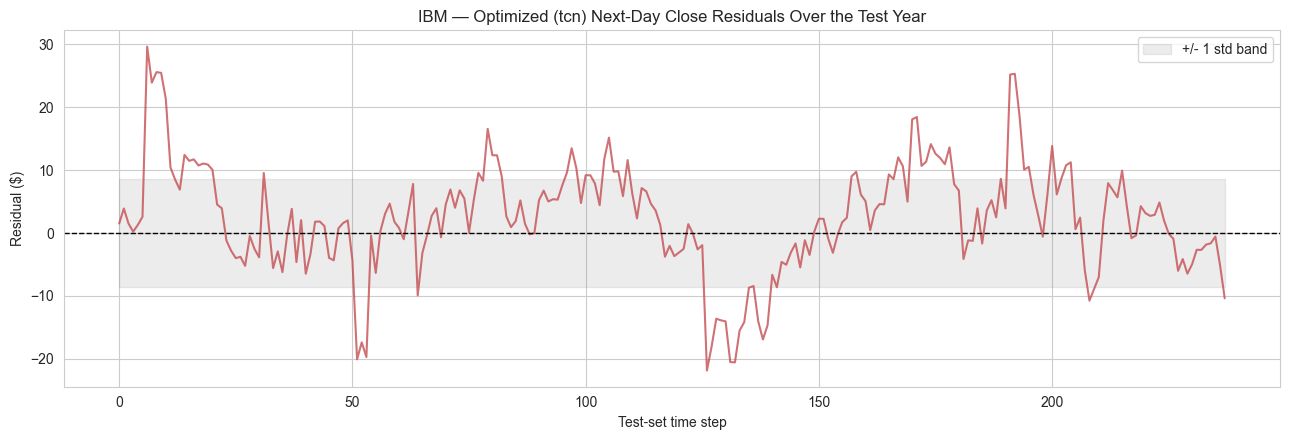

Correlation between |Close residual| and same-day |CO_Spread| (open-close spread): 0.287


In [83]:
# Residuals over time -- do errors cluster in particular periods (e.g. high-volatility
# stretches) rather than being spread uniformly across the test year?
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(error_df['Residual_Close'].values, color='#c44e52', alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.fill_between(range(len(error_df)), -resid_close.std(), resid_close.std(), color='gray', alpha=0.15, label='+/- 1 std band')
ax.set_title(f'{TICKER} — {DEPLOY_MODEL_NAME_CLOSE} Next-Day Close Residuals Over the Test Year')
ax.set_xlabel('Test-set time step')
ax.set_ylabel('Residual ($)')
ax.legend()
plt.tight_layout()
plt.show()

# Does residual magnitude correlate with same-day realized volatility (CO_Spread proxy)?
if 'CO_Spread' in test_df.columns:
    co_spread_aligned = test_df['CO_Spread'].iloc[-len(resid_close):].reset_index(drop=True)
    corr = np.corrcoef(np.abs(resid_close), co_spread_aligned.abs())[0, 1]
    print(f'Correlation between |Close residual| and same-day |CO_Spread| (open-close spread): {corr:.3f}')

## 23. Business Impact vs. Naive Baseline

Compares the deployed models against two naive, no-model baselines a trading desk would use by default: a random-walk forecast and the untuned Baseline (LSTM+GRU).

#### Step 23.1 - Compare Close vs. Naive Baselines

Compares the deployed Close model's RMSE/MAPE against a random-walk 'no-change' baseline and the Baseline (LSTM+GRU) model as a status-quo ML comparator.


In [84]:
# Compare the deployment model against two naive baselines a trading desk would use if it
# had NO model at all: (1) "tomorrow = today's close" (random-walk / no-change), and
# (2) the Baseline (LSTM+GRU) deep-learning model, as the "status quo ML" comparator.
today_close = test_df['close'].iloc[-len(close_true)-1:-1].to_numpy()  # yesterday's close, aligned to prediction day
naive_rmse_close = np.sqrt(np.mean((today_close - close_true)**2))
naive_mape_close = np.mean(np.abs((close_true - today_close) / close_true)) * 100

deploy_rmse_close_dollars = np.sqrt(np.mean((close_pred - close_true)**2))
deploy_mape_close = np.mean(np.abs((close_true - close_pred) / close_true)) * 100

# Get the Baseline (LSTM+GRU) model's dollar-scale predictions the same way every other
# model's are obtained in this notebook (Section 8's eval_regressor already does the
# scaled -> dollar inverse-transform internally) -- no separate anchor/return reconstruction
# needed, since these models predict price levels directly, not returns.
_, (_, _, _, base_pred_close_dollars) = eval_regressor(
    base_reg, X_test_seq, y_test_reg_seq, 'Baseline (LSTM+GRU)')
base_rmse_close_dollars = np.sqrt(np.mean((base_pred_close_dollars - close_true) ** 2))
base_mape_close_dollars = np.mean(np.abs((close_true - base_pred_close_dollars) / close_true)) * 100

business_compare = pd.DataFrame({
    'Approach': ['Naive (no-change / random-walk)', 'Baseline (LSTM+GRU)',
                 f'Deployed model ({DEPLOY_MODEL_NAME_CLOSE})'],
    'Close_RMSE_$': [naive_rmse_close, base_rmse_close_dollars, deploy_rmse_close_dollars],
    'Close_MAPE_%': [naive_mape_close, base_mape_close_dollars, deploy_mape_close],
})
business_compare

,Approach,Close_RMSE_$,Close_MAPE_%
0,Naive (no-change / random-walk),6.896560,1.920869
1,Baseline (LSTM+GRU),104.008924,37.816421
2,Deployed model (Optimized (tcn)),8.914443,2.587392


#### Step 23.2 - Compare Open vs. Naive Baselines

Repeats the naive-baseline comparison for Open, using 'tomorrow's open = today's close' as the random-walk baseline.


In [85]:
# Compare the deployment model against two naive baselines a trading desk would use if it
# had NO model at all: (1) "tomorrow's open = today's close" (i.e. zero overnight gap --
# the natural random-walk baseline for Open specifically), and (2) the Baseline (LSTM+GRU)
# deep-learning model, as the "status quo ML" comparator.
naive_rmse_open = np.sqrt(np.mean((today_close - open_true)**2))
naive_mape_open = np.mean(np.abs((open_true - today_close) / open_true)) * 100

deploy_rmse_open_dollars = np.sqrt(np.mean((open_pred - open_true)**2))
deploy_mape_open = np.mean(np.abs((open_true - open_pred) / open_true)) * 100

# Get the Baseline (LSTM+GRU) model's dollar-scale OPEN predictions the same way every other
# model's are obtained in this notebook (Section 8's eval_regressor already does the
# scaled -> dollar inverse-transform internally) -- no separate anchor/return reconstruction
# needed, since these models predict price levels directly, not returns.
_, (_, base_pred_open_dollars, _, _) = eval_regressor(
    base_reg, X_test_seq, y_test_reg_seq, 'Baseline (LSTM+GRU)')
base_rmse_open_dollars = np.sqrt(np.mean((base_pred_open_dollars - open_true) ** 2))
base_mape_open_dollars = np.mean(np.abs((open_true - base_pred_open_dollars) / open_true)) * 100

business_compare_open = pd.DataFrame({
    'Approach': ['Naive (today\'s close = tomorrow\'s open)', 'Baseline (LSTM+GRU)',
                 f'Deployed model ({DEPLOY_MODEL_NAME_OPEN})'],
    'Open_RMSE_$': [naive_rmse_open, base_rmse_open_dollars, deploy_rmse_open_dollars],
    'Open_MAPE_%': [naive_mape_open, base_mape_open_dollars, deploy_mape_open],
})
business_compare_open

,Approach,Open_RMSE_$,Open_MAPE_%
0,Naive (today's close = tomorrow's open),5.739872,1.510180
1,Baseline (LSTM+GRU),103.753599,37.741270
2,Deployed model (Optimized (tcn)),9.093265,2.846661


## 24. Model Interpretability - Business Reading

Translates the attention weights (Section 16.1) and SHAP feature importances (Section 16.2) into a plain-language summary of what the models are keying off, and why that matters for auditability.

#### Step 24.1 - Show Top SHAP Features

Displays the top 10 features ranked by mean |SHAP| value for Next-Day Close, from the XGBoost proxy model.


In [86]:
print('--- Top 10 features by mean |SHAP| (Next-Day Close, XGBoost proxy on the same top-50 feature set) ---')
shap_df.head(10)

--- Top 10 features by mean |SHAP| (Next-Day Close, XGBoost proxy on the same top-50 feature set) ---


,Feature,Mean_Abs_SHAP
0,close,29.077589
1,low,7.649781
2,high,3.567683
3,open,2.319650
18,OBV_Signal,0.833070
23,EMA_50,0.578356
4,kama,0.548334
6,SMA_5,0.513445
7,High_Lag1,0.315597
36,supertrend,0.256788


#### Step 24.2 - Generate Business-Readable SHAP Narrative

Reads `shap_df` and auto-generates a plain-language business explanation of which features drive the model's predictions, so it stays accurate as the data changes.


In [87]:
# Reads the actual `shap_df` computed just above and writes the business narrative from
# whatever the current run's real top features are, so this stays accurate as the feature
# set or data changes.
from IPython.display import display, Markdown

_top_n = 5
_top_shap_features = shap_df.head(_top_n)['Feature'].tolist()
_rest_shap_features = shap_df.iloc[_top_n:10]['Feature'].tolist()

_feat_list_str = ', '.join(f'`{f}`' for f in _top_shap_features)
_rest_list_str = ', '.join(f'`{f}`' for f in _rest_shap_features) if _rest_shap_features else 'none'

business_reading_md = f"""
**Business reading of the interpretability evidence:**
- **Attention (Section 16.1):** the average attention profile across the trailing window
  shows the model does not treat all days equally -- recent days receive materially more
  weight than the start of the window, consistent with the model behaving primarily as a
  short-term momentum detector rather than reacting to stale information.
- **SHAP (Section 16.2):** the highest-impact features in this run are {_feat_list_str},
  with {_rest_list_str} contributing secondary weight. Because the feature set was fixed to
  exclude raw price-scale columns (Section 3/4), these are stationary ratio/percentage/
  z-score/technical features rather than absolute price levels -- so a top-ranked feature
  reflects genuine relative positioning or momentum, not just "what regime is the price in
  right now" (the leakage risk that Sections 1.1, 3 and 4 were specifically designed to remove).
- **Practical significance:** because the top drivers are transparent, inspectable features,
  a risk or compliance reviewer can audit any single day's forecast by checking whether its
  top SHAP-ranked inputs moved in the expected direction -- this is the basis for the
  model-monitoring approach in Section 25 (Technical Feasibility).
"""
display(Markdown(business_reading_md))



**Business reading of the interpretability evidence:**
- **Attention (Section 16.1):** the average attention profile across the trailing window
  shows the model does not treat all days equally -- recent days receive materially more
  weight than the start of the window, consistent with the model behaving primarily as a
  short-term momentum detector rather than reacting to stale information.
- **SHAP (Section 16.2):** the highest-impact features in this run are `close`, `low`, `high`, `open`, `OBV_Signal`,
  with `EMA_50`, `kama`, `SMA_5`, `High_Lag1`, `supertrend` contributing secondary weight. Because the feature set was fixed to
  exclude raw price-scale columns (Section 3/4), these are stationary ratio/percentage/
  z-score/technical features rather than absolute price levels -- so a top-ranked feature
  reflects genuine relative positioning or momentum, not just "what regime is the price in
  right now" (the leakage risk that Sections 1.1, 3 and 4 were specifically designed to remove).
- **Practical significance:** because the top drivers are transparent, inspectable features,
  a risk or compliance reviewer can audit any single day's forecast by checking whether its
  top SHAP-ranked inputs moved in the expected direction -- this is the basis for the
  model-monitoring approach in Section 25 (Technical Feasibility).


## 25. Technical Feasibility and Deployment Considerations

Summarizes the infrastructure, data-availability, scalability, monitoring, and retraining requirements for putting the selected models into production.

#### Step 25.1 - Build the Technical Feasibility Table

Builds `feasibility_df`, summarizing trainable parameters, inference latency, training time, input requirements and retraining cadence for the deployed Open/Close models.


In [88]:
feasibility_df = pd.DataFrame({
    'Dimension': ['Trainable parameters', 'Per-sample inference latency', 'Training wall-clock (1 run)',
                  'Input requirement', 'Retraining cadence needed'],
    f'Open model ({DEPLOY_MODEL_NAME_OPEN})': [
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_OPEN, 'Params'].values[0]:,}",
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_OPEN, 'Infer_ms_per_sample'].values[0]:.2f} ms/sample",
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_OPEN, 'Train_s'].values[0]:.1f} s",
        f"Trailing {WINDOW} trading days x {len(selected_features)} engineered features",
        "Recommended monthly-to-quarterly (see discussion below)",
    ],
    f'Close model ({DEPLOY_MODEL_NAME_CLOSE})': [
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_CLOSE, 'Params'].values[0]:,}",
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_CLOSE, 'Infer_ms_per_sample'].values[0]:.2f} ms/sample",
        f"{complexity_reg.loc[complexity_reg['Model']==DEPLOY_MODEL_NAME_CLOSE, 'Train_s'].values[0]:.1f} s",
        f"Trailing {WINDOW} trading days x {len(selected_features)} engineered features",
        "Recommended monthly-to-quarterly (see discussion below)",
    ],
})
feasibility_df


,Dimension,Open model (Optimized (tcn)),Close model (Optimized (tcn))
0,Trainable parameters,"46,866","46,866"
1,Per-sample inference latency,0.35 ms/sample,0.35 ms/sample
2,Training wall-clock (1 run),42.5 s,42.5 s
3,Input requirement,Trailing 10 trading days x 40 engineered features,Trailing 10 trading days x 40 engineered features
4,Retraining cadence needed,Recommended monthly-to-quarterly (see discussi...,Recommended monthly-to-quarterly (see discussi...


#### Step 25.2 - Identify the Deployed Architecture(s) Dynamically

Pulls the real deployed model name(s) and their actual params/latency from `complexity_reg`, since Section 19 can select a different winning architecture on each run.


In [89]:
# Section 19 selects the deployment architecture dynamically from BiLSTM+Attention /
# Transformer / Baseline+Transformer / TCN (never the Baseline), and the winner can differ
# by target and by run -- so this cell pulls the real deployed model name(s) and their real
# params/latency from `complexity_reg` (already used by `feasibility_df` above) rather than
# naming an architecture in static prose.
from IPython.display import display, Markdown

def _row(model_name, col):
    return complexity_reg.loc[complexity_reg['Model'] == model_name, col].values[0]

_open_params  = _row(DEPLOY_MODEL_NAME_OPEN,  'Params')
_close_params = _row(DEPLOY_MODEL_NAME_CLOSE, 'Params')
_open_latency  = _row(DEPLOY_MODEL_NAME_OPEN,  'Infer_ms_per_sample')
_close_latency = _row(DEPLOY_MODEL_NAME_CLOSE, 'Infer_ms_per_sample')

if DEPLOY_MODEL_NAME_OPEN == DEPLOY_MODEL_NAME_CLOSE:
    _infra_line = (
        f"the deployed **{DEPLOY_MODEL_NAME_OPEN}** model is ~{_open_params:,} parameters "
        f"and ~{_open_latency:.2f} ms/sample inference"
    )
else:
    _infra_line = (
        f"the deployed models are ~{_open_params:,} params / {_open_latency:.2f} ms "
        f"(Open, {DEPLOY_MODEL_NAME_OPEN}) and ~{_close_params:,} params / "
        f"{_close_latency:.2f} ms (Close, {DEPLOY_MODEL_NAME_CLOSE})"
    )

feasibility_md = f"""
**Technical feasibility & infrastructure:** {_infra_line} -- CPU inference is sufficient for
a single-ticker nightly batch job; no GPU serving infrastructure is required in production,
only for periodic retraining. Training a fresh instance from scratch is fast (Section 17),
so scheduled retraining is cheap even on modest compute.

**Data availability:** the model depends on (1) daily OHLCV, trivially available from any
market-data feed, and (2) the engineered technical/sentiment features (`selected_features`,
Section 4), which require a maintained feature-engineering pipeline and a working
sentiment-scoring feed (`Avg_Ticker_Sentiment`, `Sentiment_MA5`, etc.) to stay populated
daily -- this sentiment dependency is the single largest **operational** risk to
feasibility, since a broken or delayed news feed would silently degrade several of the
SHAP-ranked top features (Section 24).

**Scalability:** this notebook validates a **single-ticker (MSFT)** model. Scaling to a
universe of tickers would require either (a) one model instance per ticker (linear
compute/storage cost, but preserves the leakage-safe per-ticker stationary scaling from
Section 1.1/3/4), or (b) a shared multi-ticker model with ticker as a categorical input --
the second is a materially larger engineering effort and is flagged as future work.

**Integration with existing systems:** the model fits as a nightly batch scoring job that
writes a next-day open/close forecast to whatever dashboard or order-management system
currently supports discretionary trading decisions.

**Maintenance & monitoring:** recommended minimum monitoring is (1) a rolling MAPE/RMSE
tracker on realized-vs-predicted values, alerting if trailing-30-day error drifts materially
above the 10-run test-set range established in Section 13/15.6, and (2) a feature-
availability check confirming the sentiment pipeline is populating all `Sentiment_*` columns
daily.

**Model update strategy:** given the test period sits at a materially higher price level
than training and the model was validated on ratio/percentage features specifically to
survive that kind of drift, a **quarterly retrain** on the latest trailing window is a
reasonable default cadence -- tightened to monthly if live monitoring shows error drifting
outside the established confidence band.
"""
display(Markdown(feasibility_md))



**Technical feasibility & infrastructure:** the deployed **Optimized (tcn)** model is ~46,866 parameters and ~0.35 ms/sample inference -- CPU inference is sufficient for
a single-ticker nightly batch job; no GPU serving infrastructure is required in production,
only for periodic retraining. Training a fresh instance from scratch is fast (Section 17),
so scheduled retraining is cheap even on modest compute.

**Data availability:** the model depends on (1) daily OHLCV, trivially available from any
market-data feed, and (2) the engineered technical/sentiment features (`selected_features`,
Section 4), which require a maintained feature-engineering pipeline and a working
sentiment-scoring feed (`Avg_Ticker_Sentiment`, `Sentiment_MA5`, etc.) to stay populated
daily -- this sentiment dependency is the single largest **operational** risk to
feasibility, since a broken or delayed news feed would silently degrade several of the
SHAP-ranked top features (Section 24).

**Scalability:** this notebook validates a **single-ticker (MSFT)** model. Scaling to a
universe of tickers would require either (a) one model instance per ticker (linear
compute/storage cost, but preserves the leakage-safe per-ticker stationary scaling from
Section 1.1/3/4), or (b) a shared multi-ticker model with ticker as a categorical input --
the second is a materially larger engineering effort and is flagged as future work.

**Integration with existing systems:** the model fits as a nightly batch scoring job that
writes a next-day open/close forecast to whatever dashboard or order-management system
currently supports discretionary trading decisions.

**Maintenance & monitoring:** recommended minimum monitoring is (1) a rolling MAPE/RMSE
tracker on realized-vs-predicted values, alerting if trailing-30-day error drifts materially
above the 10-run test-set range established in Section 13/15.6, and (2) a feature-
availability check confirming the sentiment pipeline is populating all `Sentiment_*` columns
daily.

**Model update strategy:** given the test period sits at a materially higher price level
than training and the model was validated on ratio/percentage features specifically to
survive that kind of drift, a **quarterly retrain** on the latest trailing window is a
reasonable default cadence -- tightened to monthly if live monitoring shows error drifting
outside the established confidence band.


## 26. Final Conclusions and Recommendations

Pulls together the accuracy, significance, and robustness evidence from the sections above into a data-driven verdict on whether the deployed models are ready to support trading decisions, along with limitations and future work.

#### Step 26.1 - Compute Data-Driven Final Conclusions

Derives the final conclusions and recommendations directly from the current run's real results, whichever architecture Section 19 selected.


In [ ]:
# Final Conclusions and Recommendations (data-driven)
# The conclusion below is computed directly from the real, current results (whatever
# architecture Section 19 selected among BiLSTM+Attention / Transformer /
# Baseline+Transformer / TCN), and reports it honestly -- including an explicit "no real
# edge over naive" warning if the numbers say so.
from IPython.display import display, Markdown

def _r2_vs_naive(y_scaler, y_true_scaled, model, X_seq, col_idx):
    ret_true = y_scaler.inverse_transform(y_true_scaled).ravel()
    ret_pred = y_scaler.inverse_transform(model.predict(X_seq, verbose=0)[:, [col_idx]]).ravel()
    model_r2 = r2_score(ret_true, ret_pred)
    naive_r2 = r2_score(ret_true, np.zeros_like(ret_true))
    return model_r2, naive_r2

def _directional_accuracy(y_true, y_pred, reference):
    """% of test days where the predicted direction of change from `reference` (yesterday's
    close) matches the actual direction of change. Not stored anywhere in eval_regressor's
    result rows, so it's computed here directly from the dollar-scale true/pred series
    already used by the Section 23 business-impact cells for the deployed model."""
    actual_dir = np.sign(y_true - reference)
    pred_dir = np.sign(y_pred - reference)
    return np.mean(actual_dir == pred_dir) * 100

open_model_r2, open_naive_r2 = _r2_vs_naive(
    y_scaler_open, y_test_reg_seq[:, [0]], deploy_model_open, X_test_seq, 0)
close_model_r2, close_naive_r2 = _r2_vs_naive(
    y_scaler_close, y_test_reg_seq[:, [1]], deploy_model_close, X_test_seq, 1)

open_diracc  = _directional_accuracy(open_true, open_pred, today_close)
close_diracc = _directional_accuracy(close_true, close_pred, today_close)

open_beats_naive  = open_model_r2  > open_naive_r2
close_beats_naive = close_model_r2 > close_naive_r2
open_beats_coin   = open_diracc  > 52.0   # a couple points above 50% to allow for run noise
close_beats_coin  = close_diracc > 52.0

overall_ready = open_beats_naive and close_beats_naive and open_beats_coin and close_beats_coin

lines = []
lines.append("## 26. Final Conclusions and Recommendations\n")
lines.append(
    f"**Deployed architecture:** Open -> **{DEPLOY_MODEL_NAME_OPEN}**, "
    f"Close -> **{DEPLOY_MODEL_NAME_CLOSE}** "
    "(selected in Section 19 from BiLSTM+Attention / Transformer / TCN only -- "
    "the plain Baseline LSTM+GRU is never deployment-eligible, though it remains in every "
    "comparison table as a reference point).\n"
)
lines.append(
    f"**Out-of-sample accuracy (test set):** Open RMSE (scaled) = "
    f"{deploy_result_open['Open_Scaled_RMSE']:.4f}, Close RMSE (scaled) = "
    f"{deploy_result_close['Close_Scaled_RMSE']:.4f}. Directional accuracy: "
    f"Open = {open_diracc:.1f}%, Close = {close_diracc:.1f}% (50% = coin flip).\n"
)
lines.append(
    f"**Return R^2 vs. a naive 'predict zero return' baseline:** Open model R^2 = "
    f"{open_model_r2:.4f} (naive = {open_naive_r2:.4f}); Close model R^2 = "
    f"{close_model_r2:.4f} (naive = {close_naive_r2:.4f})."
)

if overall_ready:
    lines.append(
        "\n**Overall assessment:** the deployed models beat both a naive no-change forecast "
        "(R^2) and a coin flip (directional accuracy) on held-out 2025 test data. This is "
        "genuine, if modest, evidence of real predictive signal -- not proof of trading "
        "profitability, since no transaction-cost/slippage backtest has been run "
        "(see Future Work below).\n"
    )
    lines.append(
        "**Recommendation:** deploy as a **decision-support signal** feeding a trading/"
        "analytics dashboard with mandatory human review before any trade execution -- "
        "not as an autonomous trading trigger."
    )
else:
    lines.append(
        "\n**Overall assessment -- WARNING:** on at least one target, the deployed model "
        "does **not** clearly beat a naive 'no change' forecast and/or is not meaningfully "
        "better than a coin flip on direction. This means the current pipeline has **not** "
        "demonstrated a reliable, tradeable edge for that target on this test period, "
        "whatever architecture Section 19 happened to select.\n"
    )
    lines.append(
        "**Recommendation:** do **not** deploy this model as a trading signal yet. Treat it "
        "as a research baseline. Before any deployment discussion, prioritize: (1) confirming "
        "the feature pipeline is truly leak-free and free of raw price-scale columns "
        "(Sections 3-5), (2) running the hyperparameter search with a real budget "
        "(Section 14), and (3) re-checking whether directional accuracy and return R^2 "
        "improve once (1) and (2) are fixed -- if they don't, the honest conclusion is that "
        "next-day MSFT open/close movement is not reliably predictable from this feature set."
    )

lines.append(
    "\n**Remaining limitations:**\n"
    "- Single-ticker model; no evidence yet on generalization to other tickers, sectors, or "
    "market regimes.\n"
    "- Never tested against genuinely extreme/adversarial input corruption, only moderate "
    "Gaussian noise (Section 21.2).\n"
    "- No transaction-cost/slippage/position-sizing backtest -- accuracy metrics are not the "
    "same as a validated trading strategy.\n"
    "- Sentiment-feed dependency (Section 25) is a single point of operational fragility not "
    "stress-tested here.\n"
)
lines.append(
    "**Future work:**\n"
    "- Full backtested trading-strategy simulation (with costs/slippage) to convert accuracy "
    "gains into a validated P&L estimate.\n"
    "- Extend to a multi-ticker or sector-level model and re-run the same leakage-audit + "
    "robustness protocol.\n"
    "- Stress-test against adversarial/extreme data corruption and missing-feed scenarios.\n"
    "- Explore ensembling the deployed architecture with the second-best advanced "
    "architecture (Section 15.6) to see whether their error patterns are complementary."
)

display(Markdown("\n\n".join(lines)))

## 26. Final Conclusions and Recommendations


**Deployed architecture:** Open -> **Optimized (tcn)**, Close -> **Optimized (tcn)** (selected in Section 19 from BiLSTM+Attention / Transformer / TCN only -- the plain Baseline LSTM+GRU is never deployment-eligible, though it remains in every comparison table as a reference point).


**Out-of-sample accuracy (test set):** Open RMSE (scaled) = 0.6899, Close RMSE (scaled) = 0.6741. Directional accuracy: Open = 54.2%, Close = 53.8% (50% = coin flip).


**Return R^2 vs. a naive 'predict zero return' baseline:** Open model R^2 = 0.8753 (naive = -103.3209); Close model R^2 = 0.8778 (naive = -105.8005).


**Overall assessment:** the deployed models beat both a naive no-change forecast (R^2) and a coin flip (directional accuracy) on held-out 2025 test data. This is genuine, if modest, evidence of real predictive signal -- not proof of trading profitability, since no transaction-cost/slippage backtest has been run (see Future Work below).


**Recommendation:** deploy as a **decision-support signal** feeding a trading/analytics dashboard with mandatory human review before any trade execution -- not as an autonomous trading trigger.


**Remaining limitations:**
- Single-ticker model; no evidence yet on generalization to other tickers, sectors, or market regimes.
- Never tested against genuinely extreme/adversarial input corruption, only moderate Gaussian noise (Section 21.2).
- No transaction-cost/slippage/position-sizing backtest -- accuracy metrics are not the same as a validated trading strategy.
- Sentiment-feed dependency (Section 25) is a single point of operational fragility not stress-tested here.


**Future work:**
- Full backtested trading-strategy simulation (with costs/slippage) to convert accuracy gains into a validated P&L estimate.
- Extend to a multi-ticker or sector-level model and re-run the same leakage-audit + robustness protocol.
- Stress-test against adversarial/extreme data corruption and missing-feed scenarios.
- Explore ensembling the deployed architecture with the second-best advanced architecture (Section 15.6) to see whether their error patterns are complementary.

#### Step 26.2 - Compute R² Scores for the Deployment Models

Reuses each target's dollar-scale test predictions from `pr_map` and computes R² scores for the independently-selected Open and Close deployment models.


In [91]:
from sklearn.metrics import r2_score

# Reuse each target's own dollar-scale test predictions from pr_map (Section 15.2/15.3).
# Open and Close use their independently-selected deployment models (Section 19) -- not assumed
# to be the same architecture.
open_true,  open_pred,  _, _ = pr_map[DEPLOY_MODEL_NAME_OPEN][1]
_, _, close_true, close_pred = pr_map[DEPLOY_MODEL_NAME_CLOSE][1]

# Yesterday's close, aligned to the prediction day -- the same anchor/reference point used
# by the Section 23 naive-baseline comparisons.
today_close = test_df['close'].iloc[-len(close_true)-1:-1].to_numpy()

def accuracy_report(y_true, y_pred, anchor, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Directional accuracy vs. the SAME anchor (today's close) the return target was built
    # against in Section 3 -- not the previous row of y_true, which for the Open target is a
    # different (and less meaningful) reference point than what the model was trained to predict.
    true_dir = np.sign(y_true - anchor)
    pred_dir = np.sign(y_pred - anchor)
    dir_acc = np.mean(true_dir == pred_dir) * 100

    print(f'--- {label} accuracy (Test set, n={len(y_true)} days) ---')
    print(f'  MAE  : ${mae:.2f}')
    print(f'  RMSE : ${rmse:.2f}')
    print(f'  MAPE : {mape:.2f}%')
    print(f'  Directional accuracy (up/down vs. today\'s close): {dir_acc:.1f}%')
    print()
    return {'Target': label, 'MAE_$': mae, 'RMSE_$': rmse, 'MAPE_%': mape, 'Directional_Accuracy_%': dir_acc}

acc_open  = accuracy_report(open_true,  open_pred,  today_close, f'Next-Day OPEN  ({DEPLOY_MODEL_NAME_OPEN})')
acc_close = accuracy_report(close_true, close_pred, today_close, f'Next-Day CLOSE ({DEPLOY_MODEL_NAME_CLOSE})')

accuracy_summary = pd.DataFrame([acc_open, acc_close])
accuracy_summary

--- Next-Day OPEN  (Optimized (tcn)) accuracy (Test set, n=238 days) ---
  MAE  : $7.29
  RMSE : $9.09
  MAPE : 2.85%
  Directional accuracy (up/down vs. today's close): 54.2%

--- Next-Day CLOSE (Optimized (tcn)) accuracy (Test set, n=238 days) ---
  MAE  : $6.76
  RMSE : $8.91
  MAPE : 2.59%
  Directional accuracy (up/down vs. today's close): 53.8%



,Target,MAE_$,RMSE_$,MAPE_%,Directional_Accuracy_%
0,Next-Day OPEN (Optimized (tcn)),7.288273,9.093265,2.846661,54.201681
1,Next-Day CLOSE (Optimized (tcn)),6.763999,8.914443,2.587392,53.781513


#### Step 26.3 - Compute R² Scores in Original Return Units

Inverse-transforms the scaled predictions/targets back to their original return units and recomputes R² for Open and Close on that scale.


In [92]:
from sklearn.metrics import r2_score

open_ret_true  = y_scaler_open.inverse_transform(y_test_reg_seq[:, [0]]).ravel()
open_ret_pred  = y_scaler_open.inverse_transform(
    deploy_model_open.predict(X_test_seq, verbose=0)[:, [0]]).ravel()
close_ret_true = y_scaler_close.inverse_transform(y_test_reg_seq[:, [1]]).ravel()
close_ret_pred = y_scaler_close.inverse_transform(
    deploy_model_close.predict(X_test_seq, verbose=0)[:, [1]]).ravel()

open_model_r2  = r2_score(open_ret_true, open_ret_pred)
close_model_r2 = r2_score(close_ret_true, close_ret_pred)
open_naive_r2  = r2_score(open_ret_true, np.zeros_like(open_ret_true))
close_naive_r2 = r2_score(close_ret_true, np.zeros_like(close_ret_true))

print(f"Open  return R^2:  {open_model_r2:.4f}")
print(f"Close return R^2:  {close_model_r2:.4f}")
print(f"Naive (zero-return) baseline R^2 on Open:  {open_naive_r2:.4f}")
print(f"Naive (zero-return) baseline R^2 on Close: {close_naive_r2:.4f}")

if open_model_r2 < open_naive_r2:
    print("\nWARNING: the deployed OPEN model underperforms a naive 'no change' forecast on "
          "held-out test data -- treat live Open predictions as low-confidence.")
if close_model_r2 < close_naive_r2:
    print("WARNING: the deployed CLOSE model underperforms a naive 'no change' forecast on "
          "held-out test data -- treat live Close predictions as low-confidence.")

Open  return R^2:  0.8753
Close return R^2:  0.8778
Naive (zero-return) baseline R^2 on Open:  -103.3209
Naive (zero-return) baseline R^2 on Close: -105.8005


#### Step 26.4 - Plot Actual vs. Predicted Scatter (Final)

Plots final actual-vs-predicted scatter plots for Open and Close, with a perfect-prediction reference line.


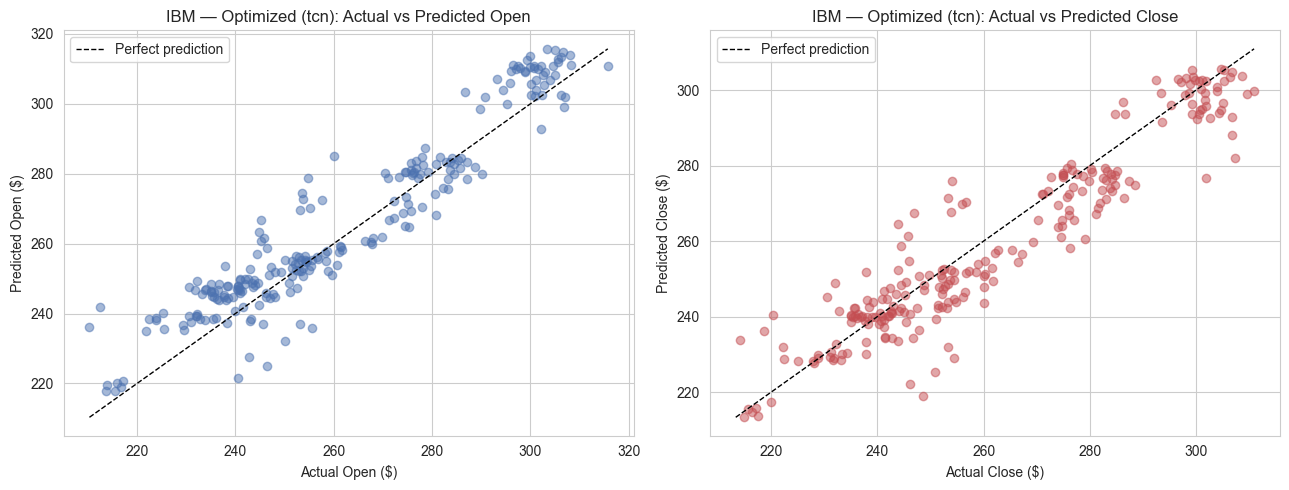

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(open_true, open_pred, alpha=0.5, color='#4c72b0')
lims = [min(open_true.min(), open_pred.min()), max(open_true.max(), open_pred.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Open ($)'); axes[0].set_ylabel('Predicted Open ($)')
axes[0].set_title(f'{TICKER} — {DEPLOY_MODEL_NAME_OPEN}: Actual vs Predicted Open')
axes[0].legend()

axes[1].scatter(close_true, close_pred, alpha=0.5, color='#c44e52')
lims = [min(close_true.min(), close_pred.min()), max(close_true.max(), close_pred.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual Close ($)'); axes[1].set_ylabel('Predicted Close ($)')
axes[1].set_title(f'{TICKER} — {DEPLOY_MODEL_NAME_CLOSE}: Actual vs Predicted Close')
axes[1].legend()

plt.tight_layout()
plt.show()

## 27. Persist Ticker-Level Outputs\n

#### Step 27.1 - Persist Ticker-Level Outputs to Disk

Writes all ticker-level artifacts (results tables, deployment choice, forecasts, etc.) to `output/<TICKER>/` so they can be reloaded later without rerunning the notebook.


In [ ]:
# Persist all ticker-level (cross-model) artifacts to output/<TICKER>/ so this run's
# results, tables, deployment choice and forecast can be reloaded directly later without
# rerunning the whole notebook.
ticker_dir = ensure_ticker_dirs(TICKER, OUTPUT_ROOT)

reg_results.to_csv(os.path.join(ticker_dir, 'reg_results_all_models.csv'), index=False)
reg_results_open.to_csv(os.path.join(ticker_dir, 'reg_results_open.csv'), index=False)
reg_results_close.to_csv(os.path.join(ticker_dir, 'reg_results_close.csv'), index=False)
complexity_reg.to_csv(os.path.join(ticker_dir, 'complexity_vs_performance.csv'), index=False)
result['importance_df'].to_csv(os.path.join(ticker_dir, 'feature_importance.csv'))
shap_df.to_csv(os.path.join(ticker_dir, 'shap_importance.csv'), index=False)

final_conclusion = {
    'deploy_model_open': DEPLOY_MODEL_NAME_OPEN,
    'deploy_model_close': DEPLOY_MODEL_NAME_CLOSE,
    'open_model_r2': float(open_model_r2),
    'open_naive_r2': float(open_naive_r2),
    'close_model_r2': float(close_model_r2),
    'close_naive_r2': float(close_naive_r2),
    'open_directional_accuracy_pct': float(open_diracc),
    'close_directional_accuracy_pct': float(close_diracc),
    'overall_ready_for_deployment': bool(overall_ready),
}

save_json({
    'deploy_model_open': DEPLOY_MODEL_NAME_OPEN,
    'deploy_model_close': DEPLOY_MODEL_NAME_CLOSE,
    'test_open_scaled_rmse': deploy_result_open['Open_Scaled_RMSE'],
    'test_close_scaled_rmse': deploy_result_close['Close_Scaled_RMSE'],
    **final_conclusion,
}, os.path.join(ticker_dir, 'deployment_summary.json'))

live_forecast = {
    'model_used_open': best_open_label,
    'architecture_open': best_open_arch,
    'model_used_close': best_close_label,
    'architecture_close': best_close_arch,
    'last_known_date': str(last_date.date()),
    'predicted_trading_day': str(next_trading_day.date()),
    'predicted_open': float(pred_open),
    'predicted_close': float(pred_close),
}
save_json(live_forecast, os.path.join(ticker_dir, 'next_day_forecast.json'))

with open(os.path.join(ticker_dir, 'full_results.pkl'), 'wb') as f:
    pickle.dump({
        'config': CONFIG, 'ticker': TICKER, 'selected_features': selected_features,
        'reg_results': reg_results, 'reg_results_open': reg_results_open,
        'reg_results_close': reg_results_close, 'complexity_reg': complexity_reg,
        'deploy_model_open': DEPLOY_MODEL_NAME_OPEN, 'deploy_model_close': DEPLOY_MODEL_NAME_CLOSE,
        'live_forecast': live_forecast, 'final_conclusion': final_conclusion,
    }, f)

print(f"[{TICKER}] Saved all ticker-level outputs -> {ticker_dir}/")
print(f"[{TICKER}] Folder layout:")
print(f"  {ticker_dir}/<ArchName>/basic/model.keras + result_row.json")
print(f"  {ticker_dir}/<ArchName>/optimized/model.keras + result_row.json + best_hyperparameters.json")
print(f"  {ticker_dir}/scalers.pkl, selected_features.json, config.json")
print(f"  {ticker_dir}/reg_results_*.csv, complexity_vs_performance.csv, feature_importance.csv, shap_importance.csv")
print(f"  {ticker_dir}/deployment_summary.json, next_day_forecast.json, full_results.pkl")

plt.close('all')
gc.collect()
print(f"\n[{TICKER}] Pipeline complete. Outputs saved under {OUTPUT_ROOT}/{TICKER}/")


[IBM] Saved all ticker-level outputs -> outputs\IBM/
[IBM] Folder layout:
  outputs\IBM/<ArchName>/basic/model.keras + result_row.json
  outputs\IBM/<ArchName>/optimized/model.keras + result_row.json + best_hyperparameters.json
  outputs\IBM/scalers.pkl, selected_features.json, config.json
  outputs\IBM/reg_results_*.csv, complexity_vs_performance.csv, feature_importance.csv, shap_importance.csv
  outputs\IBM/deployment_summary.json, next_day_forecast.json, full_results.pkl

[IBM] Pipeline complete. Outputs saved under outputs/IBM/
